# Proyecto Integrador - Cash Optimization
## Avance 1: Análisis Exploratorio de Datos (EDA)
### Maestría en Inteligencia Artificial Aplicada - Tecnológico de Monterrey

**Equipo 9**

- Oscar Benjamín Zacarías Villegas (A01797160)
- Mariana Paola De los Cobos Kingston (A01796922)
- Gerardo Tenorio Castillo (A01139576)

El presente notebook desarrolla el análisis exploratorio de datos del proyecto Cash Optimization. El análisis se centra en la construcción y caracterización de `operaciones_t1`, correspondiente al número de operaciones exactamente un mes después, y en la evaluación de la calidad, continuidad y estructura de la información disponible para un problema supervisado de regresión.

## 0. Alcance, objetivo y reglas metodológicas

La base contiene información anonimizada de Cash Management / GTB por lo que no es posible identificar de manera directa a las entidades a las que corresponden los registros. La institución responsable (BBVA México) de la información estuvo de acuerdo en proporcionar y utilizar los datos bajo este esquema de anonimización. En consecuencia, para efectos del presente proyecto, no fue necesario establecer un convenio adicional para el acceso y manejo de la base de datos, manteniendo en todo momento la confidencialidad de la información.

El objetivo obligatorio del componente predictivo queda fijado para este proyecto como:

$$
y_{t+1} = \mathrm{numero\_operaciones}_{t+1}
$$

Es un problema de **aprendizaje supervisado de regresión** con horizonte de **exactamente un mes**. Para una observación del mes \(t\), solo puede utilizarse información disponible hasta \(t\); cualquier información posterior queda fuera de los predictores para evitar fuga de información.

Se distingue entre dos niveles:

1. **Granularidad observacional/contractual:** fecha de corte × grupo × cliente × línea de contrato × convenio × producto × subproducto × moneda.
2. **Nivel de uso de negocio:** grupo corporativo. Las predicciones futuras podrán agregarse desde las unidades contractuales al grupo sin promediar prematuramente tarifas o convenios heterogéneos.

En E1 no se entrenan modelos, no se construye el optimizador Multipricing y no se materializan features definitivas de E2 (lags, rolling statistics, peers, clustering o encodings finales). La única variable derivada indispensable para el problema supervisado es `operaciones_t1`; otras variables auxiliares se crean únicamente para diagnóstico EDA.

## 1. Diccionario de datos

1. `id_grupo`: identificador del grupo corporativo.
2. `id_cliente`: identificador del cliente dentro del grupo.
3. `negocio`: área de negocio.
4. `línea_contrato`: identificador de la línea contractual.
5. `producto`: producto o servicio de Cash Management.
6. `subproducto`: servicio o concepto tarifario específico.
7. `convenio`: configuración tarifaria asociada a una relación contractual.
8. `moneda`: moneda de la observación contractual.
9. `numero_operaciones`: operaciones realizadas durante el mes observado \(t\).
10. `tarifa_vigente`: precio aplicado durante el periodo.
11. `tarifa_anaquel`: tarifa de referencia del subproducto.
12. `ingreso_bruto`: comisiones efectivamente observadas durante el periodo.
13. `seniority`: fecha más antigua disponible asociada a la relación conocida del cliente con el producto.
14. `fecha_corte`: último día del mes observado.
15. `industria`: industria asociada al grupo corporativo.

## 2. Librerías y configuración reproducible

In [1]:
from pathlib import Path
from itertools import combinations
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

warnings.filterwarnings("ignore", category=FutureWarning)

## 3. Carga de datos

El notebook busca `Base_multipricing.csv` en rutas relativas y en las ubicaciones usuales de Google Colab. También puede definirse la variable de entorno `BASE_MULTIPRICING_PATH` con la ruta exacta. `df_raw` se conserva sin modificaciones posteriores; toda limpieza o derivación se realiza sobre copias.

In [2]:
COLUMNAS = [
    "id_grupo", "id_cliente", "negocio", "línea_contrato", "producto",
    "subproducto", "convenio", "moneda", "numero_operaciones",
    "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto", "seniority",
    "fecha_corte", "industria"
]

RUTAS_CANDIDATAS = []
ruta_env = os.getenv("BASE_MULTIPRICING_PATH")
if ruta_env:
    RUTAS_CANDIDATAS.append(Path(ruta_env).expanduser())

RUTAS_CANDIDATAS.extend([
    Path.cwd() / "Base_multipricing.csv",
    Path.cwd() / "data" / "Base_multipricing.csv",
    Path("/content/Base_multipricing.csv"),
    Path("/content/drive/MyDrive/Colab Notebooks/Proyecto Integrador/Base_multipricing.csv"),
])


def localizar_base():
    for ruta in RUTAS_CANDIDATAS:
        if ruta.exists():
            return ruta

    # Si se ejecuta en Colab y Drive aún no está montado, intentar montarlo una vez.
    try:
        from google.colab import drive  # type: ignore
        if not Path("/content/drive/MyDrive").exists():
            drive.mount("/content/drive")
        ruta_colab = Path("/content/drive/MyDrive/Colab Notebooks/Proyecto Integrador/Base_multipricing.csv")
        if ruta_colab.exists():
            return ruta_colab
    except Exception:
        pass

    candidatas = "\n".join(f"- {p}" for p in RUTAS_CANDIDATAS)
    raise FileNotFoundError(
        "No se encontró Base_multipricing.csv. Coloque el archivo en una de estas rutas "
        "o defina BASE_MULTIPRICING_PATH:\n" + candidatas
    )


RUTA_DATOS = localizar_base()
print(f"Archivo utilizado: {RUTA_DATOS}")

# Referencia original. No se modifica en el resto del notebook.
df_raw = pd.read_csv(
    RUTA_DATOS,
    index_col=False,
    names=COLUMNAS,
    header=None,
    low_memory=False,
)

# Copia de trabajo. Las coerciones se auditan antes de continuar.
df_eda = df_raw.copy(deep=True)

NUMERICAS_ORIGINALES = ["numero_operaciones", "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto"]
FECHAS_ORIGINALES = ["seniority", "fecha_corte"]

validacion_parseo = []
for col in NUMERICAS_ORIGINALES:
    original = df_raw[col]
    convertida = pd.to_numeric(original, errors="coerce")
    parse_fail = original.notna() & convertida.isna()
    validacion_parseo.append({
        "variable": col,
        "tipo_original": str(original.dtype),
        "n_null_original": int(original.isna().sum()),
        "n_parse_fail": int(parse_fail.sum()),
        "n_null_final": int(convertida.isna().sum()),
    })
    df_eda[col] = convertida

for col in FECHAS_ORIGINALES:
    original = df_raw[col]
    convertida = pd.to_datetime(original, errors="coerce").dt.normalize()
    parse_fail = original.notna() & convertida.isna()
    validacion_parseo.append({
        "variable": col,
        "tipo_original": str(original.dtype),
        "n_null_original": int(original.isna().sum()),
        "n_parse_fail": int(parse_fail.sum()),
        "n_null_final": int(convertida.isna().sum()),
    })
    df_eda[col] = convertida

tabla_validacion_parseo = pd.DataFrame(validacion_parseo)
print("Forma de df_raw:", df_raw.shape)
print("Forma de df_eda:", df_eda.shape)
display(tabla_validacion_parseo)
display(df_eda.head())

if tabla_validacion_parseo["n_parse_fail"].sum() > 0:
    print(
        "Advertencia: existen valores no nulos en la fuente que no pudieron convertirse al tipo esperado. "
        "Se contabilizan como problemas de parseo y no se confunden con nulos originales."
    )
else:
    print("No se detectaron fallos de parseo en las variables numéricas o temporales auditadas.")

Mounted at /content/drive
Archivo utilizado: /content/drive/MyDrive/Colab Notebooks/Proyecto Integrador/Base_multipricing.csv
Forma de df_raw: (870591, 15)
Forma de df_eda: (870591, 15)


,variable,tipo_original,n_null_original,n_parse_fail,n_null_final
0,numero_operaciones,int64,0,0,0
1,tarifa_vigente,float64,0,0,0
2,tarifa_anaquel,float64,0,0,0
3,ingreso_bruto,float64,0,0,0
4,seniority,object,0,18028,18028
5,fecha_corte,object,0,0,0


,id_grupo,id_cliente,negocio,línea_contrato,producto,subproducto,convenio,moneda,numero_operaciones,tarifa_vigente,tarifa_anaquel,ingreso_bruto,seniority,fecha_corte,industria
0,Grupo_634,37867548,GTB,Linea_1,CONCENTRACION INMEDIATA EMPRESARIAL CIE,COMISION CIE,000000610690,MXP,1,10.4452,0.0,10.4452,2002-12-17,2025-04-30,INSTITUTIONS
1,Grupo_634,37867548,GTB,Linea_1,CONCENTRACION INMEDIATA EMPRESARIAL CIE,COMISION CIE,000000610690,MXP,0,0.0000,0.0,10.4452,2002-12-17,2024-08-31,INSTITUTIONS
2,Grupo_634,37867548,GTB,Linea_1,CONCENTRACION INMEDIATA EMPRESARIAL CIE,COMISION CIE,000000610690,MXP,1,10.4452,0.0,10.4452,2002-12-17,2023-10-31,INSTITUTIONS
3,Grupo_634,37867548,GTB,Linea_1,CONCENTRACION INMEDIATA EMPRESARIAL CIE,COMISION CIE,000000610690,MXP,0,0.0000,0.0,10.4452,2002-12-17,2025-05-31,INSTITUTIONS
4,Grupo_634,37867548,GTB,Linea_1,CONCENTRACION INMEDIATA EMPRESARIAL CIE,COMISION CIE,000000610690,MXP,1,10.4452,0.0,10.4452,2002-12-17,2024-09-30,INSTITUTIONS


Advertencia: existen valores no nulos en la fuente que no pudieron convertirse al tipo esperado. Se contabilizan como problemas de parseo y no se confunden con nulos originales.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Validación inicial de estructura y tipos

In [4]:
print("Forma del conjunto:", df_eda.shape)
df_eda.info()

display(df_eda.dtypes.astype(str).rename("tipo").to_frame())
display(df_eda.dtypes.astype(str).value_counts().rename("columnas_por_tipo").to_frame())

resumen_fechas = pd.DataFrame({
    "minimo": [df_eda["fecha_corte"].min(), df_eda["seniority"].min()],
    "maximo": [df_eda["fecha_corte"].max(), df_eda["seniority"].max()],
    "valores_distintos": [df_eda["fecha_corte"].nunique(), df_eda["seniority"].nunique()],
    "faltantes": [df_eda["fecha_corte"].isna().sum(), df_eda["seniority"].isna().sum()],
}, index=["fecha_corte", "seniority"])
display(resumen_fechas)

Forma del conjunto: (870591, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 870591 entries, 0 to 870590
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_grupo            870591 non-null  object        
 1   id_cliente          870591 non-null  object        
 2   negocio             870591 non-null  object        
 3   línea_contrato      870591 non-null  object        
 4   producto            870591 non-null  object        
 5   subproducto         870591 non-null  object        
 6   convenio            870591 non-null  object        
 7   moneda              770239 non-null  object        
 8   numero_operaciones  870591 non-null  int64         
 9   tarifa_vigente      870591 non-null  float64       
 10  tarifa_anaquel      870591 non-null  float64       
 11  ingreso_bruto       870591 non-null  float64       
 12  seniority           852563 non-null  datetime64[ns]
 

,tipo
id_grupo,object
id_cliente,object
negocio,object
línea_contrato,object
producto,object
subproducto,object
convenio,object
moneda,object
numero_operaciones,int64
tarifa_vigente,float64


,columnas_por_tipo
object,9
float64,3
datetime64[ns],2
int64,1


,minimo,maximo,valores_distintos,faltantes
fecha_corte,2023-09-30,2026-08-31,36,0
seniority,1938-08-01,2025-02-06,2454,18028


## 5. Validación de granularidad observacional

La llave esperada de una observación mensual es:

`fecha_corte + id_grupo + id_cliente + línea_contrato + convenio + producto + subproducto + moneda`.

Se cuantifican duplicados exactos y multiplicidad de esta llave antes de construir el panel supervisado. No se promedian tarifas ni convenios para resolver conflictos, ya que hacerlo podría eliminar heterogeneidad contractual relevante. `df_raw` permanece intacto durante todo el análisis.

In [5]:
LLAVE_UNIDAD = [
    "id_grupo", "id_cliente", "línea_contrato", "convenio",
    "producto", "subproducto", "moneda"
]
LLAVE_OBSERVACION = ["fecha_corte"] + LLAVE_UNIDAD

n_duplicados_exactos = int(df_eda.duplicated(keep=False).sum())

# transform("size") evita un merge adicional y permite identificar directamente las filas afectadas.
multiplicidad_por_fila = (
    df_eda.groupby(LLAVE_OBSERVACION, dropna=False, observed=True)["numero_operaciones"]
    .transform("size")
)

multiplicidad_llave = (
    df_eda.groupby(LLAVE_OBSERVACION, dropna=False, observed=True)
    .size()
    .rename("n_filas")
    .reset_index()
)
llaves_no_univocas = multiplicidad_llave[multiplicidad_llave["n_filas"] > 1].copy()
mask_no_univoca = multiplicidad_por_fila.gt(1)
df_no_univocas = df_eda.loc[mask_no_univoca].copy()
filas_en_llaves_no_univocas = int(mask_no_univoca.sum())

ops_total = df_eda["numero_operaciones"].sum(min_count=1)
ops_no_univocas = df_no_univocas["numero_operaciones"].sum(min_count=1)
ops_abs_total = df_eda["numero_operaciones"].abs().sum(min_count=1)
ops_abs_no_univocas = df_no_univocas["numero_operaciones"].abs().sum(min_count=1)

resumen_granularidad = pd.DataFrame({
    "metrica": [
        "Filas totales",
        "Filas involucradas en duplicados exactos",
        "Llaves observacionales distintas",
        "Llaves observacionales no unívocas",
        "Filas dentro de llaves no unívocas",
        "% de filas dentro de llaves no unívocas",
        "% de operaciones netas en llaves no unívocas",
        "% de volumen absoluto de operaciones en llaves no unívocas",
    ],
    "valor": [
        len(df_eda),
        n_duplicados_exactos,
        len(multiplicidad_llave),
        len(llaves_no_univocas),
        filas_en_llaves_no_univocas,
        100 * filas_en_llaves_no_univocas / len(df_eda) if len(df_eda) else np.nan,
        100 * ops_no_univocas / ops_total if pd.notna(ops_total) and ops_total != 0 else np.nan,
        100 * ops_abs_no_univocas / ops_abs_total if pd.notna(ops_abs_total) and ops_abs_total != 0 else np.nan,
    ]
})
display(resumen_granularidad)

# Caracterización de las llaves no unívocas antes de excluirlas del panel supervisado.
if len(df_no_univocas):
    columnas_no_llave = [c for c in df_eda.columns if c not in LLAVE_OBSERVACION]
    agg_spec = {c: (c, lambda s: s.nunique(dropna=False)) for c in columnas_no_llave}
    detalle_llaves_no_univocas = (
        df_no_univocas.groupby(LLAVE_OBSERVACION, dropna=False, observed=True)
        .agg(n_filas=("numero_operaciones", "size"), **agg_spec)
        .reset_index()
    )

    # Nombres más explícitos para las variables centrales del conflicto.
    detalle_llaves_no_univocas = detalle_llaves_no_univocas.rename(columns={
        "tarifa_vigente": "nunique_tarifa_vigente",
        "numero_operaciones": "nunique_numero_operaciones",
        "ingreso_bruto": "nunique_ingreso_bruto",
        "tarifa_anaquel": "nunique_tarifa_anaquel",
        "seniority": "nunique_seniority",
        "industria": "nunique_industria",
        "negocio": "nunique_negocio",
    })

    # Para detectar duplicado exacto, todas las columnas no llave deben ser constantes dentro de la llave.
    cols_nunique = [c for c in detalle_llaves_no_univocas.columns if c.startswith("nunique_")]
    exacta = detalle_llaves_no_univocas[cols_nunique].le(1).all(axis=1)
    diff_tarifa = detalle_llaves_no_univocas["nunique_tarifa_vigente"].gt(1)
    diff_ops = detalle_llaves_no_univocas["nunique_numero_operaciones"].gt(1)
    diff_ingreso = detalle_llaves_no_univocas["nunique_ingreso_bruto"].gt(1)
    diff_anaquel = detalle_llaves_no_univocas["nunique_tarifa_anaquel"].gt(1)
    n_conflictos_centrales = pd.concat([diff_tarifa, diff_ops, diff_ingreso, diff_anaquel], axis=1).sum(axis=1)

    detalle_llaves_no_univocas["tipo_conflicto"] = np.select(
        [
            exacta,
            n_conflictos_centrales.ge(2),
            diff_tarifa,
            (~diff_tarifa) & diff_ops,
            (~diff_tarifa) & (~diff_ops) & diff_ingreso,
        ],
        [
            "duplicado exacto",
            "conflicto mixto",
            "diferentes tarifas",
            "misma tarifa / diferentes operaciones",
            "diferentes ingresos",
        ],
        default="otra diferencia de atributos",
    )

    print("Tipología de llaves no unívocas:")
    display(
        detalle_llaves_no_univocas["tipo_conflicto"]
        .value_counts(dropna=False)
        .rename("llaves")
        .to_frame()
    )
    display(detalle_llaves_no_univocas.sort_values("n_filas", ascending=False).head(20))

    impacto_producto_no_univocas = (
        df_no_univocas.groupby("producto", dropna=False, observed=True)
        .agg(filas_afectadas=("numero_operaciones", "size"), operaciones=("numero_operaciones", "sum"))
        .sort_values("filas_afectadas", ascending=False)
    )
    impacto_temporal_no_univocas = (
        df_no_univocas.assign(mes=df_no_univocas["fecha_corte"].dt.to_period("M"))
        .groupby("mes", observed=True)
        .agg(filas_afectadas=("numero_operaciones", "size"), operaciones=("numero_operaciones", "sum"))
    )
    print("Llaves no unívocas por producto:")
    display(impacto_producto_no_univocas)
    print("Llaves no unívocas por mes:")
    display(impacto_temporal_no_univocas)
else:
    detalle_llaves_no_univocas = pd.DataFrame()
    impacto_producto_no_univocas = pd.DataFrame()
    impacto_temporal_no_univocas = pd.DataFrame()
    print("La llave observacional es unívoca en todos los registros.")

# Diagnóstico de integridad referencial: se reporta, no se interpreta de forma directa como error.
def contar_hijos_multiples(df, padre, hijo):
    n = df.groupby(padre, dropna=False, observed=True)[hijo].nunique(dropna=False)
    return int((n > 1).sum()), int(len(n))

checks_integridad = []
for padre, hijo, descripcion in [
    ("id_cliente", "id_grupo", "Clientes asociados a más de un grupo"),
    ("línea_contrato", "id_cliente", "Líneas asociadas a más de un cliente"),
    ("convenio", "línea_contrato", "Convenios asociados a más de una línea"),
    ("subproducto", "producto", "Subproductos asociados a más de un producto"),
]:
    n_conf, n_total = contar_hijos_multiples(df_eda, padre, hijo)
    checks_integridad.append({
        "chequeo": descripcion,
        "casos_con_multiplicidad": n_conf,
        "entidades_evaluadas": n_total,
        "porcentaje": 100 * n_conf / n_total if n_total else np.nan,
    })

display(pd.DataFrame(checks_integridad))

,metrica,valor
0,Filas totales,870591.000000
1,Filas involucradas en duplicados exactos,1131.000000
2,Llaves observacionales distintas,853133.000000
3,Llaves observacionales no unívocas,10219.000000
4,Filas dentro de llaves no unívocas,27677.000000
5,% de filas dentro de llaves no unívocas,3.179105
6,% de operaciones netas en llaves no unívocas,2.925463
7,% de volumen absoluto de operaciones en llaves...,2.925463


Tipología de llaves no unívocas:


,llaves
tipo_conflicto,
conflicto mixto,9767
duplicado exacto,228
misma tarifa / diferentes operaciones,212
otra diferencia de atributos,9
diferentes ingresos,3


,fecha_corte,id_grupo,id_cliente,línea_contrato,convenio,producto,subproducto,moneda,n_filas,nunique_negocio,nunique_numero_operaciones,nunique_tarifa_vigente,nunique_tarifa_anaquel,nunique_ingreso_bruto,nunique_seniority,nunique_industria,tipo_conflicto
3013,2026-01-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
9841,2026-08-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
2019,2025-12-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
8857,2026-07-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
5932,2026-04-30,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
7860,2026-06-30,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
4950,2026-03-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,6,2,2,7,1,1,conflicto mixto
6886,2026-05-31,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
3963,2026-02-28,Grupo_40,17938677,Linea_93,000000624101,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,7,1,7,2,2,7,1,1,conflicto mixto
2136,2025-12-31,Grupo_465,17907500,Linea_4530,000000793310,CONCENTRACION INMEDIATA EMPRESARIAL CIE,DEP REF BPI,MXP,6,1,6,4,1,6,1,1,conflicto mixto


Llaves no unívocas por producto:


,filas_afectadas,operaciones
producto,,
CONCENTRACION INMEDIATA EMPRESARIAL CIE,23287,35434302
SERVICIO INTEGRAL DE TESORERIA (SIT),3190,503227
DEPOSITO EMPRESARIAL DOLARES,542,42932
SWIFT,290,326654
BBVA NET CASH,190,1519393
DEPOSITO EMPRESARIAL,178,156392


Llaves no unívocas por mes:


,filas_afectadas,operaciones
mes,,
2023-09,12,71915
2023-10,34,83851
2023-11,32,81984
2023-12,14,87150
2024-01,32,95073
2024-02,32,87908
2024-03,14,93018
2024-04,36,100171
2024-05,34,98829


,chequeo,casos_con_multiplicidad,entidades_evaluadas,porcentaje
0,Clientes asociados a más de un grupo,0,3466,0.000000
1,Líneas asociadas a más de un cliente,11,7547,0.145753
2,Convenios asociados a más de una línea,1955,29819,6.556223
3,Subproductos asociados a más de un producto,21,340,6.176471


### Decisión para el panel EDA supervisado

Se identificaron **10,219 llaves observacionales no unívocas**, que involucran **27,677 filas (3.18% de la base)** y representan **2.93% del volumen de operaciones**. La mayoría corresponde a conflictos simultáneos en varios atributos (**9,767 llaves**), por lo que no existe sustento para consolidarlas mediante promedios de tarifa u operaciones.

Para el panel supervisado se conservan únicamente observaciones unívocas. Esta decisión evita construir una representación contractual artificial y mantiene intacta la fuente original. La causa de las multiplicidades deberá contrastarse con el linaje de la fuente antes de una eventual incorporación posterior.

In [6]:
# El panel supervisado se construye conservadoramente con llaves observacionales unívocas.
# La exclusión no implica que las llaves no unívocas sean errores: su tipología e impacto quedaron cuantificados arriba.
df_panel = df_eda.loc[multiplicidad_por_fila.eq(1)].copy()

print(f"Filas disponibles para panel unívoco: {len(df_panel):,} ({100*len(df_panel)/len(df_eda):.2f}% del total)")
print(
    "Decisión E1: no se promedian tarifas ni operaciones en llaves no unívocas. "
    "El panel supervisado conserva únicamente llaves unívocas; la causa de las multiplicidades debe contrastarse con el linaje de la fuente."
)

Filas disponibles para panel unívoco: 842,914 (96.82% del total)
Decisión E1: no se promedian tarifas ni operaciones en llaves no unívocas. El panel supervisado conserva únicamente llaves unívocas; la causa de las multiplicidades debe contrastarse con el linaje de la fuente.


## 6. Construcción rigurosa del target `operaciones_t1`

El target solo es válido cuando la siguiente observación de la **misma unidad contractual** corresponde exactamente al mes calendario siguiente. Un `shift(-1)` aislado no es suficiente porque podría saltar meses.

In [7]:
def indice_mes(serie_fechas):
    return serie_fechas.dt.year * 12 + serie_fechas.dt.month


df_target = df_panel.sort_values(LLAVE_UNIDAD + ["fecha_corte"]).copy()
g = df_target.groupby(LLAVE_UNIDAD, dropna=False, observed=True, sort=False)

df_target["fecha_siguiente_observada"] = g["fecha_corte"].shift(-1)
df_target["operaciones_siguiente_observadas"] = g["numero_operaciones"].shift(-1)

df_target["mes_idx"] = indice_mes(df_target["fecha_corte"])
df_target["mes_idx_siguiente"] = indice_mes(df_target["fecha_siguiente_observada"])
df_target["gap_meses_hacia_siguiente"] = df_target["mes_idx_siguiente"] - df_target["mes_idx"]

es_t1_valido = df_target["gap_meses_hacia_siguiente"].eq(1)
df_target["operaciones_t1"] = df_target["operaciones_siguiente_observadas"].where(es_t1_valido)
# La fecha del target es la fecha real observada del siguiente mes, no la fecha de origen t.
df_target["fecha_target"] = df_target["fecha_siguiente_observada"].where(es_t1_valido)

# Razón de no disponibilidad del target para auditoría.
df_target["estado_target"] = np.select(
    [
        df_target["operaciones_t1"].notna(),
        df_target["fecha_siguiente_observada"].isna(),
        df_target["gap_meses_hacia_siguiente"].gt(1),
    ],
    [
        "target_t1_valido",
        "sin_observacion_posterior",
        "salto_mayor_a_un_mes",
    ],
    default="otro",
)

# Validación obligatoria: todo target no nulo debe provenir exactamente del mes siguiente.
assert df_target.loc[df_target["operaciones_t1"].notna(), "gap_meses_hacia_siguiente"].eq(1).all()
assert df_target.loc[df_target["operaciones_t1"].notna(), "fecha_target"].eq(
    df_target.loc[df_target["operaciones_t1"].notna(), "fecha_siguiente_observada"]
).all()

df_target_valid = df_target[df_target["operaciones_t1"].notna()].copy()

resumen_target_cobertura = pd.DataFrame({
    "metrica": [
        "Filas originales",
        "Filas en panel unívoco",
        "Targets t+1 válidos",
        "Targets t+1 no disponibles",
        "% cobertura sobre panel unívoco",
        "% cobertura sobre filas originales",
    ],
    "valor": [
        len(df_eda),
        len(df_target),
        len(df_target_valid),
        int(df_target["operaciones_t1"].isna().sum()),
        100 * len(df_target_valid) / len(df_target) if len(df_target) else np.nan,
        100 * len(df_target_valid) / len(df_eda) if len(df_eda) else np.nan,
    ]
})
display(resumen_target_cobertura)
display(df_target["estado_target"].value_counts(dropna=False).rename("filas").to_frame())

,metrica,valor
0,Filas originales,870591.000000
1,Filas en panel unívoco,842914.000000
2,Targets t+1 válidos,694384.000000
3,Targets t+1 no disponibles,148530.000000
4,% cobertura sobre panel unívoco,82.378985
5,% cobertura sobre filas originales,79.760071


,filas
estado_target,
target_t1_valido,694384
sin_observacion_posterior,101548
salto_mayor_a_un_mes,46982


## 7. Cobertura y viabilidad del target

In [8]:
# Cobertura del target por producto.
cobertura_producto = (
    df_target.assign(target_valido=df_target["operaciones_t1"].notna())
    .groupby("producto", observed=True, dropna=False)
    .agg(registros=("target_valido", "size"), targets_validos=("target_valido", "sum"))
)
cobertura_producto["cobertura_pct"] = 100 * cobertura_producto["targets_validos"] / cobertura_producto["registros"]
display(cobertura_producto.sort_values("cobertura_pct"))

# Cobertura por mes de origen t.
cobertura_mes = (
    df_target.assign(mes=df_target["fecha_corte"].dt.to_period("M"),
                     target_valido=df_target["operaciones_t1"].notna())
    .groupby("mes", observed=True)
    .agg(registros=("target_valido", "size"), targets_validos=("target_valido", "sum"))
)
cobertura_mes["cobertura_pct"] = 100 * cobertura_mes["targets_validos"] / cobertura_mes["registros"]
display(cobertura_mes)

,registros,targets_validos,cobertura_pct
producto,,,
DOMICILIACION,41166,5285,12.838265
SERVICIOS T.I.B.,27,4,14.814815
BBVA NET CASH,291126,227036,77.985477
SERVICIO INTEGRAL DE TESORERIA (SIT),60681,50676,83.512137
DEPOSITO EMPRESARIAL DOLARES,3071,2627,85.542169
CONCENTRACION INMEDIATA EMPRESARIAL CIE,106604,94215,88.378485
APIS EMPRESARIALES,1544,1365,88.406736
DEPOSITO EMPRESARIAL,46572,41401,88.896762
CREDIPROVEEDORES,35,32,91.428571


,registros,targets_validos,cobertura_pct
mes,,,
2023-09,23120,20673,89.416090
2023-10,23374,20701,88.564217
2023-11,23176,20711,89.363997
2023-12,23233,20693,89.067275
2024-01,23831,21104,88.556922
2024-02,23696,21027,88.736496
2024-03,23376,21047,90.036790
2024-04,23845,21326,89.435940
2024-05,24167,21488,88.914636


# Q1. Valores faltantes y patrones de ausencia

El análisis de ausencia combina magnitud, co-ocurrencia, asociación con variables observadas, diferencias distribucionales y estabilidad temporal. El objetivo es evaluar si **MCAR resulta plausible** y si la evidencia es **compatible con MAR**, manteniendo explícita la limitación de que MAR y MNAR no pueden distinguirse de forma concluyente únicamente con información observada.

## Q1.1 Cuantificación de faltantes e indicadores de ausencia

Los indicadores `missing_*` son auxiliares de diagnóstico EDA. No se presentan como features definitivas del modelo.


In [9]:
missing_summary = pd.DataFrame({
    "n_faltantes": df_eda.isna().sum(),
    "faltantes_pct": 100 * df_eda.isna().mean(),
    "n_observados": df_eda.notna().sum(),
    "observados_pct": 100 * df_eda.notna().mean(),
}).sort_values("faltantes_pct", ascending=False)
display(missing_summary)

cols_faltantes = missing_summary.index[missing_summary["n_faltantes"] > 0].tolist()
print("Variables originales con faltantes:", cols_faltantes)

missing_flags = pd.DataFrame(index=df_eda.index)
for col in cols_faltantes:
    missing_flags[f"missing_{col}"] = df_eda[col].isna().astype("int8")

display(missing_flags.head())


,n_faltantes,faltantes_pct,n_observados,observados_pct
moneda,100352,11.526882,770239,88.473118
industria,80569,9.254518,790022,90.745482
seniority,18028,2.070777,852563,97.929223
línea_contrato,0,0.000000,870591,100.000000
id_grupo,0,0.000000,870591,100.000000
id_cliente,0,0.000000,870591,100.000000
negocio,0,0.000000,870591,100.000000
convenio,0,0.000000,870591,100.000000
subproducto,0,0.000000,870591,100.000000
producto,0,0.000000,870591,100.000000


Variables originales con faltantes: ['moneda', 'industria', 'seniority']


,missing_moneda,missing_industria,missing_seniority
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


## Q1.2 Visualización y patrones conjuntos de ausencia


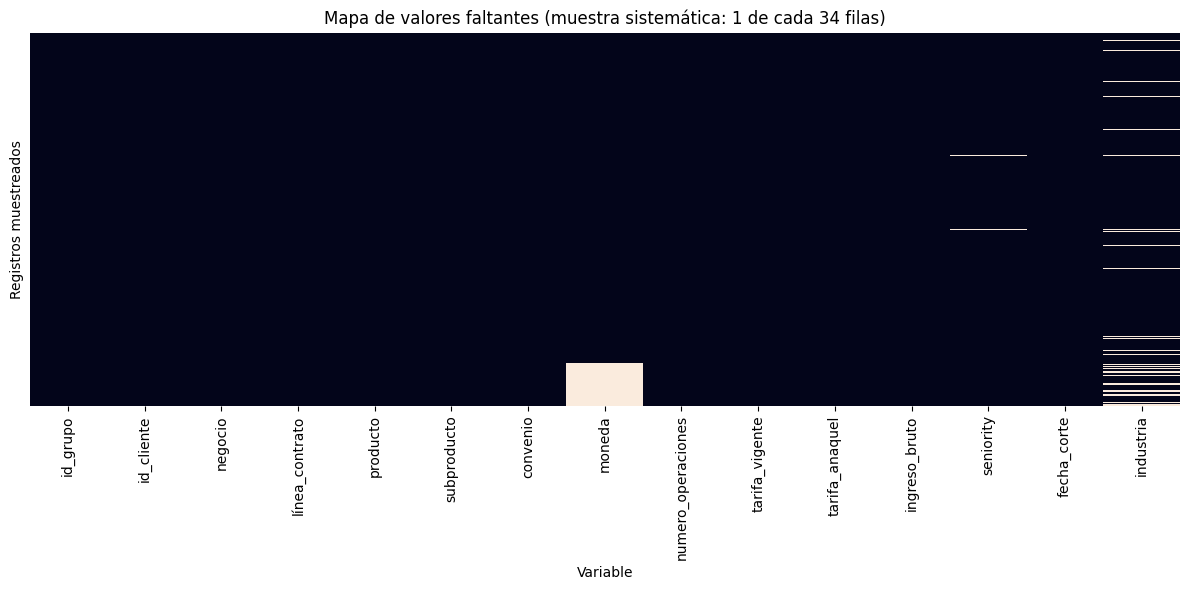

,missing_moneda,missing_industria,missing_seniority,porcentaje
0,0,0,0,83.081952
1,1,0,0,7.592543
2,0,1,0,3.864961
3,1,1,0,3.389766
4,0,1,1,1.465097
5,1,1,1,0.534694
6,0,0,1,0.061108
7,1,0,1,0.009878


In [10]:
# Mapa de nulos: muestra sistemática solo para visualización; los porcentajes usan toda la base.
paso = max(len(df_eda) // 25000, 1)
muestra_nulos = df_eda.iloc[::paso]
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(muestra_nulos.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title(f"Mapa de valores faltantes (muestra sistemática: 1 de cada {paso} filas)")
ax.set_xlabel("Variable")
ax.set_ylabel("Registros muestreados")
plt.tight_layout()
plt.show()

if not missing_flags.empty:
    patrones_missing = (
        missing_flags.value_counts(normalize=True)
        .mul(100)
        .rename("porcentaje")
        .reset_index()
    )
    display(patrones_missing.head(20))
else:
    patrones_missing = pd.DataFrame()
    print("No existen valores faltantes en las variables originales.")


## Q1.3 Asociación entre los propios indicadores de ausencia

La correlación Phi/Cramér's V entre indicadores permite detectar patrones estructurados de co-ausencia. Por sí sola, una asociación entre indicadores de missing **no prueba MAR ni descarta MCAR respecto de los datos observados**; se utiliza como contexto del mecanismo de ausencia.


In [11]:
def cramers_v_corregido(tabla):
    """Cramér's V con corrección por sesgo; devuelve chi2, p, V y calidad aproximada de esperados."""
    chi2, p, _, expected = chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    if n <= 1:
        return np.nan, np.nan, np.nan, np.nan
    r, k = tabla.shape
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    v = np.sqrt(phi2_corr / denom) if denom > 0 else 0.0
    pct_expected_ge5 = 100 * np.mean(expected >= 5) if expected.size else np.nan
    return float(chi2), float(p), float(v), float(pct_expected_ge5)


def interpretar_cramers_v(v):
    if pd.isna(v):
        return "no evaluable"
    if v < 0.05:
        return "despreciable"
    if v < 0.10:
        return "muy débil"
    if v < 0.20:
        return "débil"
    if v < 0.30:
        return "moderada"
    return "fuerte"

asoc_missing_rows = []
if missing_flags.shape[1] >= 2:
    phi_missing = missing_flags.corr()
    display(phi_missing.round(3).style.background_gradient(cmap="vlag", vmin=-1, vmax=1))

    for a, b in combinations(missing_flags.columns, 2):
        tabla = pd.crosstab(missing_flags[a], missing_flags[b])
        chi2, p, v, pct_exp = cramers_v_corregido(tabla)
        phi = float(missing_flags[a].corr(missing_flags[b]))
        ambos = int(((missing_flags[a] == 1) & (missing_flags[b] == 1)).sum())
        asoc_missing_rows.append({
            "missing_a": a,
            "missing_b": b,
            "n_ambos_missing": ambos,
            "pct_ambos_missing": 100 * ambos / len(missing_flags),
            "phi": phi,
            "cramers_v": v,
            "p_value": p,
            "pct_celdas_esperadas_ge5": pct_exp,
            "interpretacion_v": interpretar_cramers_v(v),
        })
else:
    print("Hay menos de dos variables con faltantes; no se requiere asociación entre indicadores.")

tabla_asoc_missing = pd.DataFrame(asoc_missing_rows)
if len(tabla_asoc_missing):
    display(tabla_asoc_missing.sort_values("cramers_v", ascending=False))


,missing_moneda,missing_industria,missing_seniority
missing_moneda,1.000000,0.309000,0.067000
missing_industria,0.309000,1.000000,0.438000
missing_seniority,0.067000,0.438000,1.000000


,missing_a,missing_b,n_ambos_missing,pct_ambos_missing,phi,cramers_v,p_value,pct_celdas_esperadas_ge5,interpretacion_v
2,missing_industria,missing_seniority,17410,1.999791,0.438150,0.438135,0.0,100.0,fuerte
0,missing_moneda,missing_industria,34166,3.924461,0.308792,0.308784,0.0,100.0,fuerte
1,missing_moneda,missing_seniority,4741,0.544573,0.067261,0.067240,0.0,100.0,muy débil


## Q1.4 Missingness vs variables categóricas observadas

Se evalúa si la probabilidad de ausencia cambia con variables que sí están observadas. Con una muestra grande, un p-value pequeño puede corresponder a una asociación trivial; por ello la lectura principal se apoya en **Cramér's V** y en la calidad de las frecuencias esperadas. IDs de altísima cardinalidad no se someten a una prueba global.


In [12]:
# Series categóricas razonables para diagnóstico; mes/año se derivan únicamente para estudiar missingness.
cat_series_q1 = {
    "producto": df_eda["producto"],
    "moneda": df_eda["moneda"],
    "industria": df_eda["industria"],
    "negocio": df_eda["negocio"],
    "mes_calendario": df_eda["fecha_corte"].dt.month,
    "anio": df_eda["fecha_corte"].dt.year,
}

# Subproducto solo se incluye en la prueba global si la cardinalidad no es excesiva.
MAX_CARDINALIDAD_Q1_CHI2 = 100
if df_eda["subproducto"].nunique(dropna=False) <= MAX_CARDINALIDAD_Q1_CHI2:
    cat_series_q1["subproducto"] = df_eda["subproducto"]
else:
    print(
        f"subproducto se omite del chi-cuadrado global de Q1 por cardinalidad "
        f"({df_eda['subproducto'].nunique(dropna=False)} categorías > {MAX_CARDINALIDAD_Q1_CHI2})."
    )

assoc_cat_rows = []
for col_missing in cols_faltantes:
    indicador = df_eda[col_missing].isna().astype("int8")
    for nombre_obs, serie_obs in cat_series_q1.items():
        # No tiene sentido contrastar missing(variable) contra la propia variable, pues la relación es determinista.
        if nombre_obs == col_missing:
            continue
        observada = serie_obs.astype("string").fillna("<MISSING_OBS>")
        tabla = pd.crosstab(indicador, observada)
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
        chi2, p, v, pct_exp = cramers_v_corregido(tabla)
        assoc_cat_rows.append({
            "variable_missing": col_missing,
            "variable_explicativa": nombre_obs,
            "chi2": chi2,
            "p_value": p,
            "cramers_v": v,
            "n_categorias": int(tabla.shape[1]),
            "n": int(tabla.to_numpy().sum()),
            "pct_celdas_esperadas_ge5": pct_exp,
            "interpretacion_efecto": interpretar_cramers_v(v),
        })

missing_assoc_cat = pd.DataFrame(assoc_cat_rows)
if len(missing_assoc_cat):
    display(missing_assoc_cat.sort_values(["cramers_v", "n"], ascending=[False, False]))
else:
    print("No hubo asociaciones categóricas evaluables.")

print(
    "Guía de lectura: V <0.05 despreciable; 0.05–0.10 muy débil; 0.10–0.20 débil; "
    "0.20–0.30 moderada; >0.30 fuerte. Son referencias descriptivas, no leyes universales."
)


subproducto se omite del chi-cuadrado global de Q1 por cardinalidad (340 categorías > 100).


,variable_missing,variable_explicativa,chi2,p_value,cramers_v,n_categorias,n,pct_celdas_esperadas_ge5,interpretacion_efecto
0,moneda,producto,225546.009941,0.000000e+00,0.508976,15,870591,93.333333,fuerte
10,seniority,industria,167167.144308,0.000000e+00,0.438174,18,870591,100.000000,fuerte
1,moneda,industria,95719.564235,0.000000e+00,0.331555,18,870591,100.000000,fuerte
5,industria,moneda,83171.923243,0.000000e+00,0.309082,4,870591,100.000000,fuerte
2,moneda,mes_calendario,31293.405073,0.000000e+00,0.189558,12,870591,100.000000,débil
4,industria,producto,27528.281723,0.000000e+00,0.177776,15,870591,93.333333,débil
9,seniority,moneda,4171.787097,0.000000e+00,0.069199,4,870591,100.000000,muy débil
8,seniority,producto,2883.067018,0.000000e+00,0.057407,15,870591,93.333333,muy débil
3,moneda,anio,1176.385289,9.744594e-255,0.036712,4,870591,100.000000,despreciable
7,industria,anio,754.783843,2.768194e-163,0.029386,4,870591,100.000000,despreciable


Guía de lectura: V <0.05 despreciable; 0.05–0.10 muy débil; 0.10–0.20 débil; 0.20–0.30 moderada; >0.30 fuerte. Son referencias descriptivas, no leyes universales.


## Q1.5 Missingness vs variables numéricas observadas

Dadas las colas y asimetrías de las variables numéricas, se utiliza Mann–Whitney U y un tamaño de efecto rank-biserial. La significancia estadística no se usa sola para decidir si la asociación es material.


In [13]:
def interpretar_rank_biserial(r):
    if pd.isna(r):
        return "no evaluable"
    a = abs(r)
    if a < 0.10:
        return "despreciable"
    if a < 0.30:
        return "pequeño"
    if a < 0.50:
        return "moderado"
    return "grande"

numeric_q1 = ["numero_operaciones", "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto"]
assoc_num_rows = []
for col_missing in cols_faltantes:
    flag = df_eda[col_missing].isna()
    for num in numeric_q1:
        x0 = df_eda.loc[~flag, num].dropna().to_numpy()
        x1 = df_eda.loc[flag, num].dropna().to_numpy()
        if len(x0) == 0 or len(x1) == 0:
            continue
        U, p = mannwhitneyu(x0, x1, alternative="two-sided", method="asymptotic")
        r_rb = 2 * U / (len(x0) * len(x1)) - 1
        med0 = float(np.median(x0))
        med1 = float(np.median(x1))
        delta = med1 - med0
        delta_pct = 100 * delta / abs(med0) if med0 != 0 else np.nan
        assoc_num_rows.append({
            "variable_missing": col_missing,
            "variable_numerica": num,
            "n_observado": len(x0),
            "n_missing": len(x1),
            "mediana_observado": med0,
            "mediana_missing": med1,
            "delta_mediana_missing_menos_observado": delta,
            "delta_mediana_pct": delta_pct,
            "U": U,
            "p_value": p,
            "rank_biserial": r_rb,
            "interpretacion_efecto": interpretar_rank_biserial(r_rb),
        })

missing_assoc_num = pd.DataFrame(assoc_num_rows)
if len(missing_assoc_num):
    display(
        missing_assoc_num.assign(abs_effect=missing_assoc_num["rank_biserial"].abs())
        .sort_values("abs_effect", ascending=False)
        .drop(columns="abs_effect")
    )
else:
    print("No hubo asociaciones numéricas evaluables.")


,variable_missing,variable_numerica,n_observado,n_missing,mediana_observado,mediana_missing,delta_mediana_missing_menos_observado,delta_mediana_pct,U,p_value,rank_biserial,interpretacion_efecto
2,moneda,tarifa_anaquel,770239,100352,6.9736,0.000,-6.9736,-100.000000,6.583764e+10,0.000000e+00,0.703541,grande
3,moneda,ingreso_bruto,770239,100352,113.7000,0.000,-113.7000,-100.000000,6.497556e+10,0.000000e+00,0.681235,grande
6,industria,tarifa_anaquel,790022,80569,6.8220,0.000,-6.8220,-100.000000,4.217438e+10,0.000000e+00,0.325170,moderado
10,seniority,tarifa_anaquel,852563,18028,6.8220,0.000,-6.8220,-100.000000,9.079524e+09,0.000000e+00,0.181460,pequeño
7,industria,ingreso_bruto,790022,80569,49.5580,0.000,-49.5580,-100.000000,3.708313e+10,0.000000e+00,0.165197,pequeño
1,moneda,tarifa_vigente,770239,100352,0.0000,0.000,0.0000,NaN,4.294194e+10,0.000000e+00,0.111118,pequeño
0,moneda,numero_operaciones,770239,100352,22.0000,11.000,-11.0000,-50.000000,4.276330e+10,0.000000e+00,0.106496,pequeño
9,seniority,tarifa_vigente,852563,18028,0.0000,0.000,0.0000,NaN,8.478151e+09,2.796081e-145,0.103207,pequeño
5,industria,tarifa_vigente,790022,80569,0.0000,0.000,0.0000,NaN,3.498711e+10,0.000000e+00,0.099337,despreciable
11,seniority,ingreso_bruto,852563,18028,41.7810,9.096,-32.6850,-78.229339,8.226378e+09,5.991460e-63,0.070446,despreciable


## Q1.6 Evolución temporal de la ausencia

Una variación sistemática de missingness por periodo constituye evidencia contra una interpretación ingenua de ausencia completamente aleatoria. Se reporta tanto magnitud temporal como asociación estadística.


,moneda,industria,seniority
mes,,,
2023-09,12.428670,10.435760,1.789729
2023-10,12.072796,9.847061,1.772898
2023-11,11.987246,10.095657,1.745088
2023-12,12.070375,10.087323,1.823891
2024-01,11.779743,10.141223,1.835478
2024-02,11.952124,10.456001,1.909137
2024-03,11.526293,10.205216,1.966652
2024-04,11.402370,10.443449,1.984842
2024-05,11.416884,10.685509,2.020578


,variable,missing_pct_min,missing_pct_max,rango_pp,missing_pct_media,missing_pct_std,mes_min,mes_max,cramers_v_mes_calendario,p_value_mes_calendario
0,moneda,0.000000,47.556207,47.556207,10.659943,7.102799,2025-01,2025-09,0.189558,0.000000e+00
1,industria,5.785415,10.930668,5.145253,9.201804,1.384497,2024-12,2024-11,0.023010,3.073334e-94
2,seniority,1.745088,2.981427,1.236339,2.046852,0.273318,2023-11,2025-09,0.008244,1.133787e-10


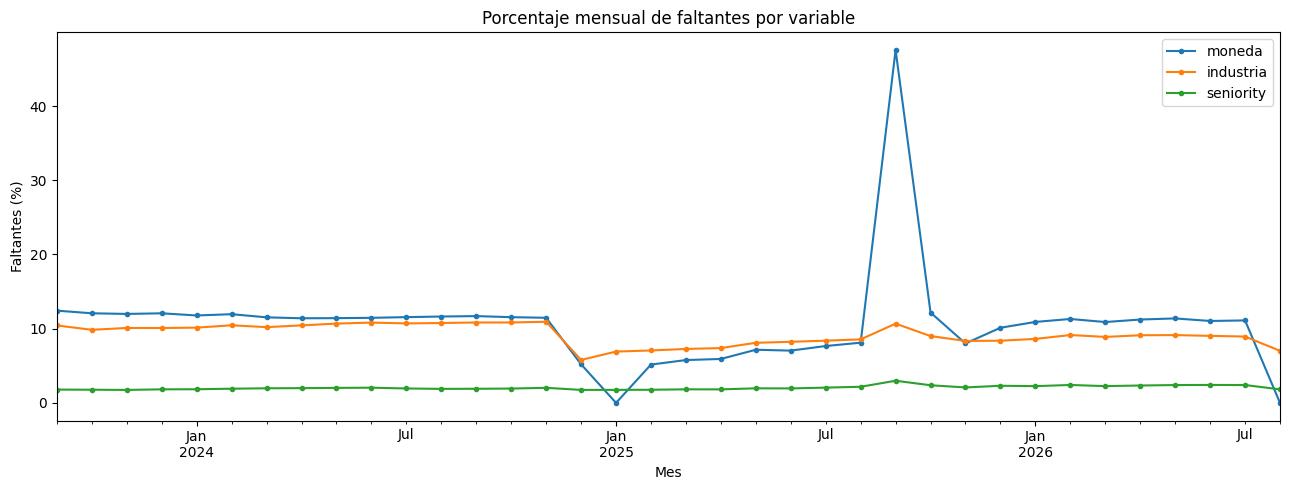

In [14]:
if cols_faltantes:
    faltantes_mes = (
        df_eda.assign(mes=df_eda["fecha_corte"].dt.to_period("M"))
        .groupby("mes", observed=True)[cols_faltantes]
        .agg(lambda s: 100 * s.isna().mean())
    )
    display(faltantes_mes)

    resumen_missing_temporal_rows = []
    for col in cols_faltantes:
        s = faltantes_mes[col].dropna()
        temporal_test = missing_assoc_cat[
            (missing_assoc_cat["variable_missing"] == col)
            & (missing_assoc_cat["variable_explicativa"] == "mes_calendario")
        ] if len(missing_assoc_cat) else pd.DataFrame()
        temporal_v = temporal_test["cramers_v"].iloc[0] if len(temporal_test) else np.nan
        temporal_p = temporal_test["p_value"].iloc[0] if len(temporal_test) else np.nan
        resumen_missing_temporal_rows.append({
            "variable": col,
            "missing_pct_min": s.min(),
            "missing_pct_max": s.max(),
            "rango_pp": s.max() - s.min(),
            "missing_pct_media": s.mean(),
            "missing_pct_std": s.std(),
            "mes_min": str(s.idxmin()) if len(s) else None,
            "mes_max": str(s.idxmax()) if len(s) else None,
            "cramers_v_mes_calendario": temporal_v,
            "p_value_mes_calendario": temporal_p,
        })

    resumen_missing_temporal = pd.DataFrame(resumen_missing_temporal_rows)
    display(resumen_missing_temporal)

    ax = faltantes_mes.to_timestamp().plot(figsize=(13, 5), marker=".")
    ax.set_title("Porcentaje mensual de faltantes por variable")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Faltantes (%)")
    plt.tight_layout()
    plt.show()
else:
    faltantes_mes = pd.DataFrame()
    resumen_missing_temporal = pd.DataFrame()
    print("No hay variables con faltantes para analizar temporalmente.")


## Q1.7 Variación de missingness por producto


,variable,missing_pct_min_producto,missing_pct_max_producto,rango_pp_producto,producto_max,producto_min
0,moneda,0.0,34.447816,34.447816,BBVA NET CASH,APIS EMPRESARIALES
1,industria,0.0,17.630778,17.630778,DEPOSITO EMPRESARIAL DOLARES,CREDIPROVEEDORES
2,seniority,0.0,3.703704,3.703704,SERVICIOS T.I.B.,CREDIPROVEEDORES


,variable,producto,missing_pct
0,moneda,BBVA NET CASH,34.447816
1,moneda,APIS EMPRESARIALES,0.000000
2,moneda,CENTRALIZACION DE CUENTAS,0.000000
3,moneda,CONCENTRACION INMEDIATA EMPRESARIAL CIE,0.000000
4,moneda,CREDIPROVEEDORES,0.000000
5,moneda,DEPOSITO EMPRESARIAL,0.000000
6,moneda,DEPOSITO EMPRESARIAL DOLARES,0.000000
7,moneda,DOMICILIACION,0.000000
8,moneda,HOST TO HOST SERVICIOS,0.000000
9,moneda,OPERACION T.I.B.,0.000000


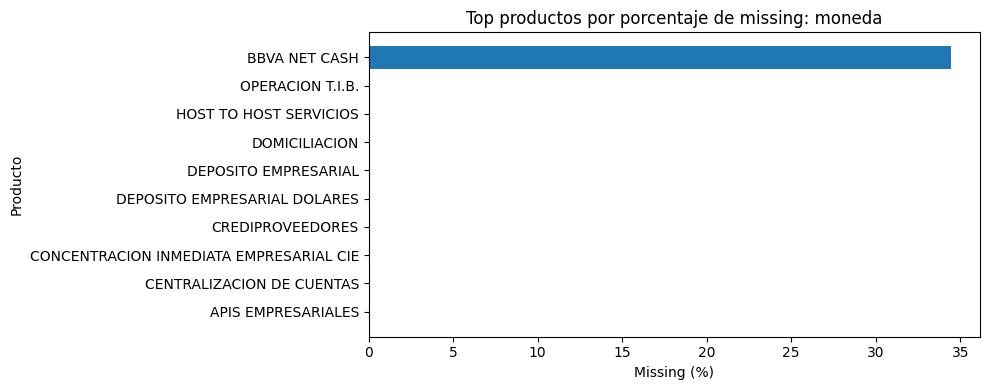

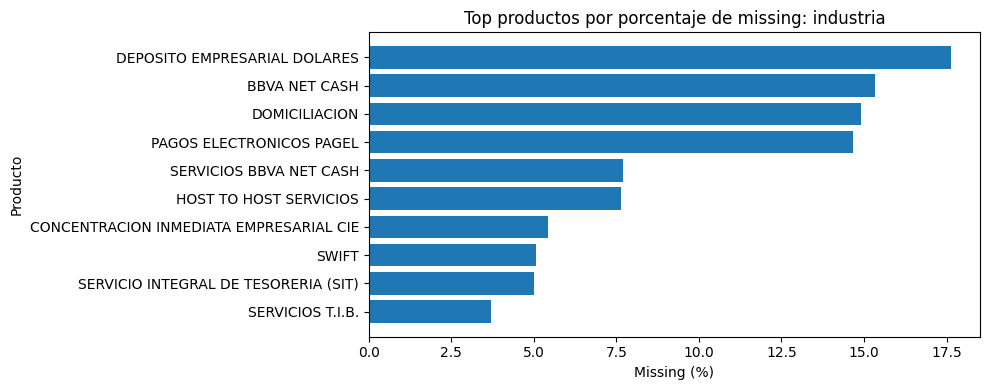

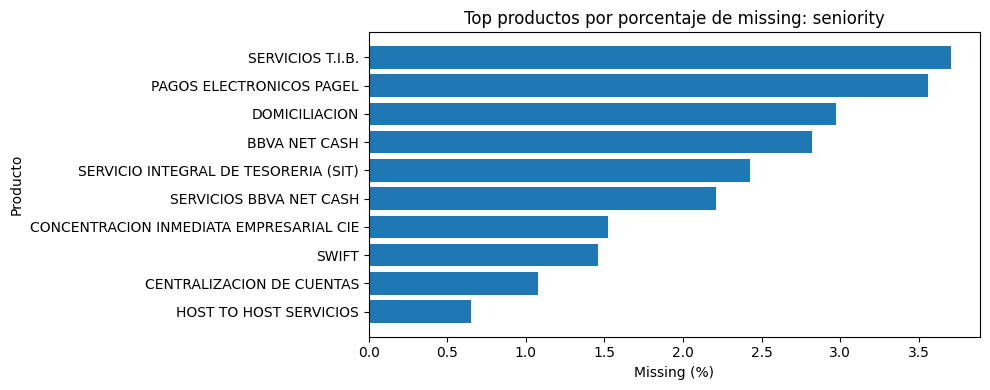

In [15]:
if cols_faltantes:
    faltantes_producto = (
        df_eda.groupby("producto", observed=True, dropna=False)[cols_faltantes]
        .agg(lambda s: 100 * s.isna().mean())
    )
    resumen_producto_rows = []
    top_producto_rows = []
    for col in cols_faltantes:
        s = faltantes_producto[col].dropna().sort_values(ascending=False)
        resumen_producto_rows.append({
            "variable": col,
            "missing_pct_min_producto": s.min() if len(s) else np.nan,
            "missing_pct_max_producto": s.max() if len(s) else np.nan,
            "rango_pp_producto": (s.max() - s.min()) if len(s) else np.nan,
            "producto_max": s.idxmax() if len(s) else None,
            "producto_min": s.idxmin() if len(s) else None,
        })
        for producto, pct in s.head(10).items():
            top_producto_rows.append({"variable": col, "producto": producto, "missing_pct": pct})

    resumen_missing_producto = pd.DataFrame(resumen_producto_rows)
    top_missing_producto = pd.DataFrame(top_producto_rows)
    display(resumen_missing_producto)
    display(top_missing_producto)

    for col in cols_faltantes:
        temp = top_missing_producto[top_missing_producto["variable"] == col].sort_values("missing_pct")
        if len(temp):
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.barh(temp["producto"].astype(str), temp["missing_pct"])
            ax.set_title(f"Top productos por porcentaje de missing: {col}")
            ax.set_xlabel("Missing (%)")
            ax.set_ylabel("Producto")
            plt.tight_layout()
            plt.show()
else:
    faltantes_producto = pd.DataFrame()
    resumen_missing_producto = pd.DataFrame()
    top_missing_producto = pd.DataFrame()


## Q1.8 Síntesis MCAR / MAR / MNAR

La interpretación prioriza tamaños de efecto y patrones sistemáticos sobre la significancia estadística aislada. Para `moneda` e `industria`, la existencia de asociaciones materiales con variables observadas y con otros mecanismos de ausencia permite evaluar si MCAR es una hipótesis razonable. `seniority` se trata por separado porque sus valores no disponibles provienen de fallos de conversión de fecha y no de nulos originales.

In [16]:
# Umbrales descriptivos para separar significancia estadística de relevancia práctica.
UMBRAL_V_MATERIAL = 0.05
UMBRAL_RB_MATERIAL = 0.10
UMBRAL_RANGO_TEMPORAL_PP = 5.0
UMBRAL_PHI_MISSING = 0.10

parse_lookup = tabla_validacion_parseo.set_index("variable").to_dict("index")

mcar_rows = []
for col in cols_faltantes:
    if len(tabla_asoc_missing):
        dep_missing = tabla_asoc_missing[
            tabla_asoc_missing["missing_a"].eq(f"missing_{col}")
            | tabla_asoc_missing["missing_b"].eq(f"missing_{col}")
        ]
        evidencia_otros_missing = bool((dep_missing["phi"].abs() >= UMBRAL_PHI_MISSING).any()) if len(dep_missing) else False
    else:
        evidencia_otros_missing = False

    cat_rows = missing_assoc_cat[
        (missing_assoc_cat["variable_missing"] == col)
        & (~missing_assoc_cat["variable_explicativa"].isin(["mes_calendario", "anio"]))
    ] if len(missing_assoc_cat) else pd.DataFrame()
    evidencia_cat = bool((cat_rows["cramers_v"] >= UMBRAL_V_MATERIAL).any()) if len(cat_rows) else False

    num_rows = missing_assoc_num[missing_assoc_num["variable_missing"] == col] if len(missing_assoc_num) else pd.DataFrame()
    evidencia_num = bool((num_rows["rank_biserial"].abs() >= UMBRAL_RB_MATERIAL).any()) if len(num_rows) else False

    temporal_row = resumen_missing_temporal[resumen_missing_temporal["variable"] == col] if len(resumen_missing_temporal) else pd.DataFrame()
    if len(temporal_row):
        evidencia_temp = bool(
            (temporal_row["cramers_v_mes_calendario"].fillna(0).iloc[0] >= UMBRAL_V_MATERIAL)
            or (temporal_row["rango_pp"].fillna(0).iloc[0] >= UMBRAL_RANGO_TEMPORAL_PP)
        )
    else:
        evidencia_temp = False

    parse_info = parse_lookup.get(col, {})
    n_null_original = int(parse_info.get("n_null_original", 0))
    n_parse_fail = int(parse_info.get("n_parse_fail", 0))

    # seniority: los valores no disponibles fueron generados por fallos de parseo, no por nulos de origen.
    if col == "seniority" and n_parse_fail > 0 and n_null_original == 0:
        mcar_plausible = "no evaluable como missingness convencional"
        compatible_mar = "no se clasifica: ausencia generada por fallo de parseo"
        mnar_identificable = "no aplica al mecanismo inmediato de conversión"
        diagnostico = (
            f"{n_parse_fail:,} valores no nulos de origen no pudieron convertirse a fecha válida; "
            "se interpreta principalmente como un problema de calidad/formato."
        )
    else:
        evidencia_observada = evidencia_cat or evidencia_num or evidencia_temp
        if evidencia_observada:
            mcar_plausible = "poco plausible globalmente"
            compatible_mar = "sí, compatible (no demostrado)"
            diagnostico = (
                "Existe evidencia material de dependencia con variables observadas; "
                "MCAR global es poco plausible y el patrón es compatible con MAR."
            )
        else:
            mcar_plausible = "sin evidencia material fuerte en estos diagnósticos"
            compatible_mar = "no sustentado de forma material"
            diagnostico = "No se encontró evidencia material fuerte contra MCAR; MCAR tampoco queda demostrado."
        mnar_identificable = "no con datos observados; requiere información del valor faltante/proceso de captura"

    mcar_rows.append({
        "variable": col,
        "evidencia_dependencia_otros_missing": evidencia_otros_missing,
        "evidencia_categoricas_observadas": evidencia_cat,
        "evidencia_numericas_observadas": evidencia_num,
        "evidencia_temporal": evidencia_temp,
        "MCAR_plausible": mcar_plausible,
        "Compatible_con_MAR": compatible_mar,
        "MNAR_identificable": mnar_identificable,
        "Diagnostico": diagnostico,
    })

mcar_resumen = pd.DataFrame(mcar_rows)
display(mcar_resumen)

print(
    "Definiciones operativas: MCAR = la probabilidad de ausencia no depende de datos observados ni no observados; "
    "MAR = puede depender de variables observadas; MNAR = depende del propio valor no observado o de información "
    "no disponible. MAR y MNAR no son plenamente distinguibles solo con los datos observados."
)

,variable,evidencia_dependencia_otros_missing,evidencia_categoricas_observadas,evidencia_numericas_observadas,evidencia_temporal,MCAR_plausible,Compatible_con_MAR,MNAR_identificable,Diagnostico
0,moneda,True,True,True,True,poco plausible globalmente,"sí, compatible (no demostrado)",no con datos observados; requiere información ...,Existe evidencia material de dependencia con v...
1,industria,True,True,True,True,poco plausible globalmente,"sí, compatible (no demostrado)",no con datos observados; requiere información ...,Existe evidencia material de dependencia con v...
2,seniority,True,True,True,False,no evaluable como missingness convencional,no se clasifica: ausencia generada por fallo d...,no aplica al mecanismo inmediato de conversión,"18,028 valores no nulos de origen no pudieron ..."


Definiciones operativas: MCAR = la probabilidad de ausencia no depende de datos observados ni no observados; MAR = puede depender de variables observadas; MNAR = depende del propio valor no observado o de información no disponible. MAR y MNAR no son plenamente distinguibles solo con los datos observados.


## Q1.9 Decisiones de tratamiento condicionadas al diagnóstico

El tratamiento se vincula con el mecanismo observado. Las categóricas con ausencia conservan la señal de missingness y podrán incorporar una categoría explícita durante la preparación del modelo. En `seniority` no se imputa una fecha arbitraria, ya que los **18,028 registros no disponibles** se originan en valores que no pudieron convertirse a fecha válida y una imputación podría crear antigüedad ficticia.

In [17]:
tratamiento_missing_rows = []
diag_lookup = mcar_resumen.set_index("variable")["Diagnostico"].to_dict() if len(mcar_resumen) else {}

for col in cols_faltantes:
    if col in ["moneda", "industria", "producto", "subproducto", "negocio"]:
        tratamiento = "Mantener NaN en E1; evaluar categoría 'Desconocido' + indicador de ausencia"
        justificacion = "No inventa una categoría real y preserva señal potencial del mecanismo de ausencia."
        e1 = "Diagnóstico solamente"
        e2 = "Sí; fit/transform solo con train"
    elif col in ["seniority", "fecha_corte"]:
        tratamiento = "Mantener NaT + indicador; no imputar una fecha arbitraria"
        justificacion = "Una fecha inventada puede crear antigüedad ficticia y sesgo temporal."
        e1 = "Diagnóstico solamente"
        e2 = "Sí; definir tratamiento dentro del pipeline"
    else:
        tratamiento = "Conservar NaN + indicador de ausencia; evaluar estrategia específica en E2"
        justificacion = "El tratamiento depende de mecanismo, distribución y algoritmo."
        e1 = "Diagnóstico solamente"
        e2 = "Sí"

    tratamiento_missing_rows.append({
        "variable": col,
        "diagnostico": diag_lookup.get(col, "No evaluable"),
        "tratamiento_actual_propuesto": tratamiento,
        "justificacion": justificacion,
        "se_ejecuta_en_E1": e1,
        "se_reserva_para_E2": e2,
    })

tratamiento_missing = pd.DataFrame(tratamiento_missing_rows)
display(tratamiento_missing)


,variable,diagnostico,tratamiento_actual_propuesto,justificacion,se_ejecuta_en_E1,se_reserva_para_E2
0,moneda,Existe evidencia material de dependencia con v...,Mantener NaN en E1; evaluar categoría 'Descono...,No inventa una categoría real y preserva señal...,Diagnóstico solamente,Sí; fit/transform solo con train
1,industria,Existe evidencia material de dependencia con v...,Mantener NaN en E1; evaluar categoría 'Descono...,No inventa una categoría real y preserva señal...,Diagnóstico solamente,Sí; fit/transform solo con train
2,seniority,"18,028 valores no nulos de origen no pudieron ...",Mantener NaT + indicador; no imputar una fecha...,Una fecha inventada puede crear antigüedad fic...,Diagnóstico solamente,Sí; definir tratamiento dentro del pipeline


**Conclusión Q1.** `moneda` presenta **11.53%** de ausencia e `industria` **9.25%**. Los patrones no son compatibles con una hipótesis global de MCAR: la ausencia de `moneda` muestra una asociación fuerte con `producto` (Cramér's V ≈ **0.509**), mientras que la co-ausencia `industria`–`seniority` alcanza Phi/Cramér's V ≈ **0.438** y `moneda`–`industria` ≈ **0.309**. Además, el missing de `moneda` varía entre **0% y 47.56%** según el mes y hasta **34.45%** entre productos. En consecuencia, los patrones de `moneda` e `industria` son compatibles con MAR, sin que ello permita descartar MNAR. En `seniority`, los **18,028 valores no disponibles (2.07%)** corresponden a fallos de parseo sobre registros originalmente no nulos, por lo que se interpretan prioritariamente como un problema de calidad/formato de la fuente.

# Q2. Estadísticas resumidas del conjunto de datos

In [18]:
NUMERICAS_ORIGINALES = ["numero_operaciones", "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto"]
CATEGORICAS_ORIGINALES = [
    "id_grupo", "id_cliente", "negocio", "línea_contrato", "producto",
    "subproducto", "convenio", "moneda", "industria"
]

print("Forma:", df_eda.shape)
display(df_eda[NUMERICAS_ORIGINALES].describe().T)
display(df_eda[CATEGORICAS_ORIGINALES].describe(include="all").T)

ceros = pd.DataFrame({
    "cantidad_ceros": (df_eda[NUMERICAS_ORIGINALES] == 0).sum(),
    "porcentaje_ceros": 100 * (df_eda[NUMERICAS_ORIGINALES] == 0).mean(),
}).sort_values("porcentaje_ceros", ascending=False)
display(ceros)

resumen_target_desc = df_target_valid["operaciones_t1"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame().T
display(resumen_target_desc)

Forma: (870591, 15)


,count,mean,std,min,25%,50%,75%,max
numero_operaciones,870591.0,1491.348985,26066.277057,0.0,3.0,21.000,117.0000,4.982071e+06
tarifa_vigente,870591.0,152.528234,3093.850377,0.0,0.0,0.000,6.9736,4.548000e+05
tarifa_anaquel,870591.0,214.634500,2011.639300,0.0,0.0,6.822,21.2240,2.274000e+05
ingreso_bruto,870591.0,7525.615459,84940.227167,0.0,0.0,40.932,1241.5434,2.038663e+07


,count,unique,top,freq
id_grupo,870591,706,Grupo_126,23318
id_cliente,870591,3466,B7060661,21561
negocio,870591,1,GTB,870591
línea_contrato,870591,7547,Linea_1962,13510
producto,870591,15,BBVA NET CASH,291316
subproducto,870591,340,BBVA NET CASH,69486
convenio,870591,29819,BBVAESMMREL,47924
moneda,770239,3,MXP,719178
industria,790022,17,CONSUMER,144855


,cantidad_ceros,porcentaje_ceros
tarifa_vigente,455627,52.335368
ingreso_bruto,345877,39.728989
tarifa_anaquel,328696,37.755502
numero_operaciones,40536,4.656147


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
operaciones_t1,694384.0,1627.324851,28046.491383,0.0,3.0,22.0,133.0,797.0,2633.0,28904.0,4982071.0


In [19]:
# Frecuencias de clases categóricas. Para baja/media cardinalidad se muestran todas;
# para alta cardinalidad se muestra Top 10, total de categorías y cobertura acumulada.
frecuencias_resumen = []
frecuencias_detalle = {}

for col in CATEGORICAS_ORIGINALES:
    serie = df_eda[col].astype("string").fillna("<MISSING>")
    vc = serie.value_counts(dropna=False)
    tabla = vc.rename("N").to_frame()
    tabla["porcentaje"] = 100 * tabla["N"] / len(df_eda)
    tabla["porcentaje_acumulado"] = tabla["porcentaje"].cumsum()
    frecuencias_detalle[col] = tabla

    frecuencias_resumen.append({
        "variable": col,
        "categorias_unicas": int(serie.nunique(dropna=False)),
        "categoria_mas_frecuente": vc.index[0] if len(vc) else None,
        "frecuencia_top": int(vc.iloc[0]) if len(vc) else 0,
        "porcentaje_top": 100 * vc.iloc[0] / len(df_eda) if len(vc) else np.nan,
        "cobertura_top10_pct": 100 * vc.head(10).sum() / len(df_eda) if len(vc) else np.nan,
    })

frecuencias_categoricas = pd.DataFrame(frecuencias_resumen).sort_values("categorias_unicas", ascending=False)
display(frecuencias_categoricas)

for col in CATEGORICAS_ORIGINALES:
    n_cat = frecuencias_detalle[col].shape[0]
    print(f"\nFrecuencias de {col} ({n_cat} categorías):")
    if n_cat <= 30:
        display(frecuencias_detalle[col])
    else:
        display(frecuencias_detalle[col].head(10))
        print(f"Se muestran las 10 categorías más frecuentes; cobertura Top 10 = {frecuencias_categoricas.loc[frecuencias_categoricas['variable'].eq(col), 'cobertura_top10_pct'].iloc[0]:.2f}%")

,variable,categorias_unicas,categoria_mas_frecuente,frecuencia_top,porcentaje_top,cobertura_top10_pct
6,convenio,29819,BBVAESMMREL,47924,5.504766,12.422825
3,línea_contrato,7547,Linea_1962,13510,1.551819,6.671790
1,id_cliente,3466,B7060661,21561,2.476593,11.550315
0,id_grupo,706,Grupo_126,23318,2.678410,20.964035
5,subproducto,340,BBVA NET CASH,69486,7.981475,33.489664
8,industria,18,CONSUMER,144855,16.638697,85.407384
4,producto,15,BBVA NET CASH,291316,33.461867,98.406025
7,moneda,4,MXP,719178,82.608021,100.000000
2,negocio,1,GTB,870591,100.000000,100.000000



Frecuencias de id_grupo (706 categorías):


,N,porcentaje,porcentaje_acumulado
id_grupo,,,
Grupo_126,23318,2.67841,2.67841
Grupo_399,21948,2.521046,5.199456
Grupo_209,19306,2.217574,7.41703
Grupo_40,19294,2.216196,9.633226
Grupo_241,19239,2.209878,11.843104
Grupo_423,18908,2.171858,14.014962
Grupo_381,17346,1.99244,16.007402
Grupo_330,15277,1.754785,17.762187
Grupo_374,14083,1.617637,19.379824


Se muestran las 10 categorías más frecuentes; cobertura Top 10 = 20.96%

Frecuencias de id_cliente (3466 categorías):


,N,porcentaje,porcentaje_acumulado
id_cliente,,,
B7060661,21561,2.476593,2.476593
17211139,13608,1.563076,4.03967
C7914835,13522,1.553198,5.592867
61082580,12094,1.389171,6.982039
14405341,11525,1.323813,8.305852
17765095,9849,1.1313,9.437152
11408177,5338,0.613147,10.050299
17938677,4380,0.503107,10.553406
15798026,4375,0.502532,11.055938


...

,N,porcentaje,porcentaje_acumulado
convenio,,,
BBVAESMMREL,47924,5.504766,5.504766
BCMRMXMMCSM,20951,2.406526,7.911292
000000000001,13480,1.548373,9.459666
000000000209,6122,0.7032,10.162866
CITIGB2LIFP,5041,0.579032,10.741898
CRESCHZFARS,4476,0.514134,11.256032
000000011807,4086,0.469336,11.725368
000000011811,2604,0.299107,12.024475
000000001016,1754,0.201472,12.225948


Se muestran las 10 categorías más frecuentes; cobertura Top 10 = 12.42%

Frecuencias de moneda (4 categorías):


,N,porcentaje,porcentaje_acumulado
moneda,,,
MXP,719178,82.608021,82.608021
<MISSING>,100352,11.526882,94.134904
USD,50236,5.770333,99.905237
EUR,825,0.094763,100.0



Frecuencias de industria (18 categorías):


,N,porcentaje,porcentaje_acumulado
industria,,,
CONSUMER,144855,16.638697,16.638697
FINANCIAL INSTITUTIONS,95239,10.93958,27.578277
FINANCIAL SERVICES,90251,10.366636,37.944913
UTILITIES,85024,9.766239,47.711153
<MISSING>,80569,9.254518,56.96567
"TELECOMS, TECHNOLOGY & MEDIA",66357,7.622064,64.587734
CONSTRUCTION & CONSTRUCTION MATERIALS,56034,6.436317,71.024051
RETAIL,49026,5.631347,76.655398
"AUTOS, COMPONENTS & DURABLE GOODS",39804,4.572067,81.227465


**Conclusión Q2.** La base contiene **870,591 registros y 15 variables**. `numero_operaciones` tiene mediana de **21** operaciones mensuales y una cola muy larga, mientras que `operaciones_t1` tiene mediana de **22**. La estructura contiene una proporción elevada de ceros en `tarifa_vigente` (**52.34%**), `ingreso_bruto` (**39.73%**) y `tarifa_anaquel` (**37.76%**), frente a **4.66%** en `numero_operaciones`. Estas distribuciones confirman que medias simples no describen adecuadamente el comportamiento típico y justifican complementar los análisis con medianas, percentiles y escalas transformadas.

# Q3. Valores atípicos

In [20]:
series_outliers = {
    "numero_operaciones": df_eda["numero_operaciones"],
    "tarifa_vigente": df_eda["tarifa_vigente"],
    "tarifa_anaquel": df_eda["tarifa_anaquel"],
    "ingreso_bruto": df_eda["ingreso_bruto"],
    "operaciones_t1": df_target_valid["operaciones_t1"],
}

filas_outliers = []
for nombre, serie in series_outliers.items():
    s = pd.to_numeric(serie, errors="coerce").dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    mask_iqr = (s < li) | (s > ls)
    std = s.std(ddof=0)
    if std > 0:
        z = (s - s.mean()) / std
        mask_z = z.abs() > 3
    else:
        mask_z = pd.Series(False, index=s.index)
    filas_outliers.append({
        "variable": nombre,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": li,
        "limite_superior": ls,
        "outliers_IQR": int(mask_iqr.sum()),
        "outliers_IQR_pct": 100 * mask_iqr.mean(),
        "abs_z_mayor_3": int(mask_z.sum()),
        "abs_z_mayor_3_pct": 100 * mask_z.mean(),
    })

tabla_outliers = pd.DataFrame(filas_outliers).set_index("variable")
display(tabla_outliers)

,Q1,Q3,IQR,limite_inferior,limite_superior,outliers_IQR,outliers_IQR_pct,abs_z_mayor_3,abs_z_mayor_3_pct
variable,,,,,,,,,
numero_operaciones,3.0,117.0000,114.0000,-168.0000,288.0000,144458,16.593096,2699,0.310019
tarifa_vigente,0.0,6.9736,6.9736,-10.4604,17.4340,112355,12.905601,3171,0.364235
tarifa_anaquel,0.0,21.2240,21.2240,-31.8360,53.0600,150094,17.240472,7449,0.855626
ingreso_bruto,0.0,1241.5434,1241.5434,-1862.3151,3103.8585,115545,13.272019,4240,0.487025
operaciones_t1,3.0,133.0000,130.0000,-192.0000,328.0000,113594,16.358960,2198,0.316540


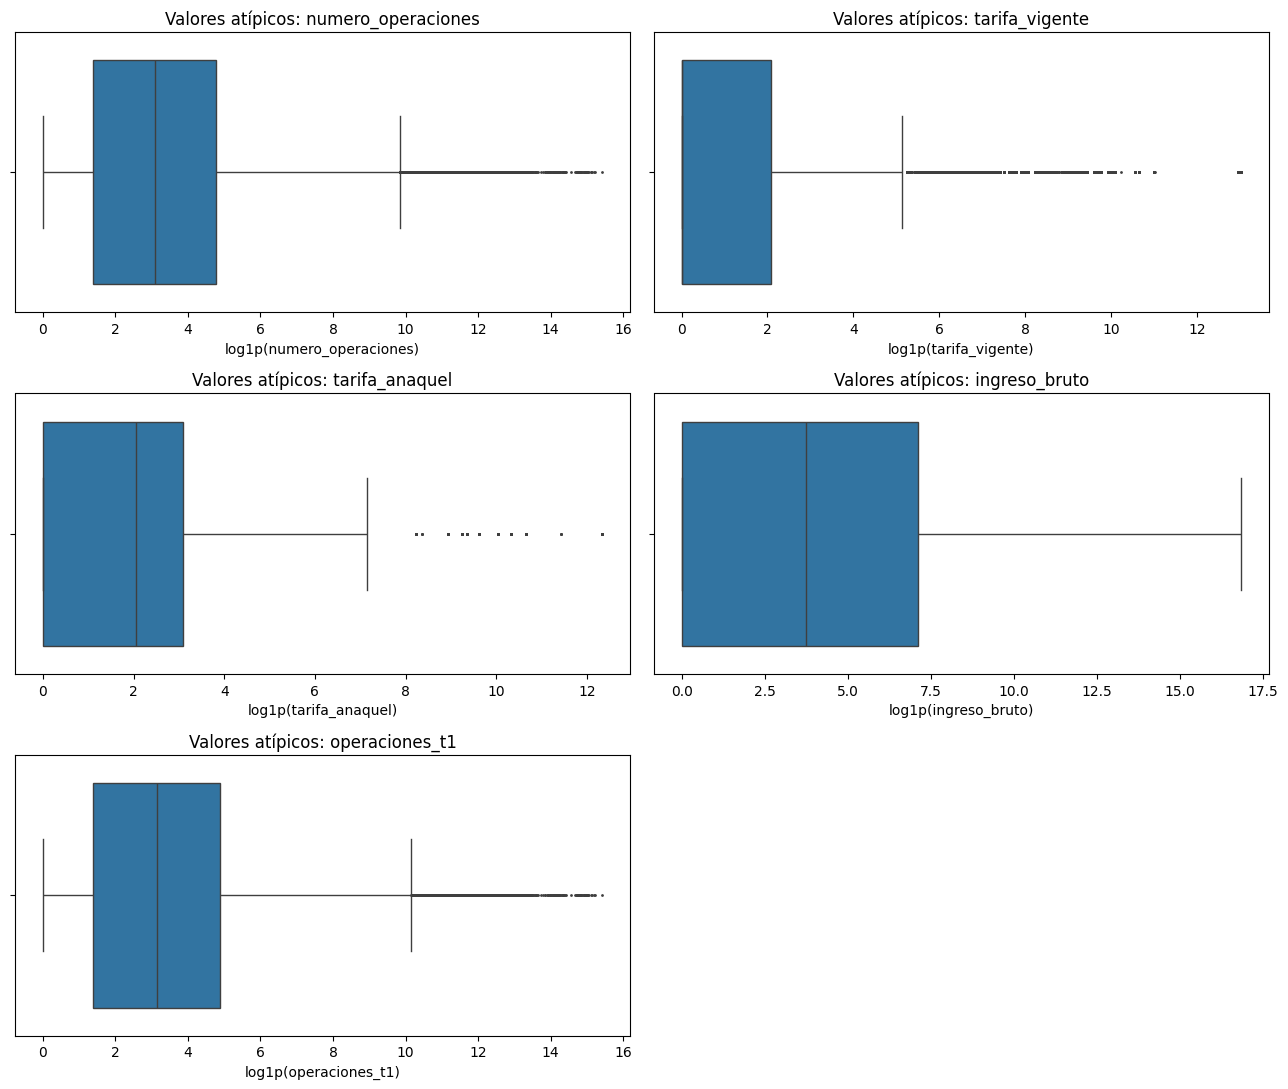

In [21]:
# Boxplots en escala log1p para hacer visibles distribuciones con colas muy largas.
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for ax, (nombre, serie) in zip(axes.flat, series_outliers.items()):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    if (s < 0).any():
        sns.boxplot(x=s, ax=ax, fliersize=1)
        ax.set_xscale("symlog", linthresh=1)
        etiqueta = nombre
    else:
        sns.boxplot(x=np.log1p(s), ax=ax, fliersize=1)
        etiqueta = f"log1p({nombre})"
    ax.set_title(f"Valores atípicos: {nombre}")
    ax.set_xlabel(etiqueta)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Q3.1 Diagnóstico de valores negativos

Además de los extremos estadísticos, se verifica si existen valores negativos que pudieran representar correcciones operativas o problemas de calidad. En la base analizada no se observaron valores negativos en operaciones, target, tarifas ni ingreso bruto.

In [22]:
series_negativos = {
    "numero_operaciones": df_eda["numero_operaciones"],
    "operaciones_t1": df_target_valid["operaciones_t1"],
    "tarifa_vigente": df_eda["tarifa_vigente"],
    "tarifa_anaquel": df_eda["tarifa_anaquel"],
    "ingreso_bruto": df_eda["ingreso_bruto"],
}

neg_rows = []
for nombre, s in series_negativos.items():
    valid = s.dropna()
    neg_rows.append({
        "variable": nombre,
        "n_negativos": int((valid < 0).sum()),
        "pct_negativos": 100 * (valid < 0).mean() if len(valid) else np.nan,
        "minimo": valid.min() if len(valid) else np.nan,
    })

tabla_negativos = pd.DataFrame(neg_rows)
display(tabla_negativos)

if tabla_negativos["n_negativos"].sum() > 0:
    print("Se detectaron valores negativos. Se muestran ejemplos y su tratamiento queda sujeto a interpretación de negocio:")
    for nombre, s in series_negativos.items():
        if (s.dropna() < 0).any():
            if nombre == "operaciones_t1":
                cols_ejemplo = ["fecha_corte", "fecha_target"] + LLAVE_UNIDAD + ["operaciones_t1"]
                display(df_target_valid.loc[df_target_valid["operaciones_t1"] < 0, cols_ejemplo].head(10))
            else:
                cols_ejemplo = ["fecha_corte"] + LLAVE_UNIDAD + [nombre]
                display(df_eda.loc[df_eda[nombre] < 0, cols_ejemplo].head(10))
else:
    print("No se detectaron valores negativos en las variables auditadas.")


,variable,n_negativos,pct_negativos,minimo
0,numero_operaciones,0,0.0,0.0
1,operaciones_t1,0,0.0,0.0
2,tarifa_vigente,0,0.0,0.0
3,tarifa_anaquel,0,0.0,0.0
4,ingreso_bruto,0,0.0,0.0


No se detectaron valores negativos en las variables auditadas.


### Q3.2 Winsorización ejecutada como comparación

Para complementar la decisión de conservar los atípicos, se ejecuta una winsorización de referencia utilizando los mismos límites de `tabla_outliers` (Q1 - 1.5·IQR y Q3 + 1.5·IQR).

Esta versión no sustituye a `df_eda` ni a `df_target_valid`; se usa únicamente para cuantificar el efecto del tratamiento sobre la asimetría antes de descartarlo para E1.

In [23]:
resumen_winsor = []
for nombre, serie in series_outliers.items():
    s = pd.to_numeric(serie, errors="coerce").dropna()
    li = tabla_outliers.loc[nombre, "limite_inferior"]
    ls = tabla_outliers.loc[nombre, "limite_superior"]
    recortada = s.clip(li, ls)
    resumen_winsor.append({
        "variable": nombre,
        "asimetria_original": s.skew(),
        "asimetria_winsorizada": recortada.skew(),
        "pct_recortado": 100 * ((s < li) | (s > ls)).mean(),
    })

tabla_winsor = pd.DataFrame(resumen_winsor).set_index("variable")
display(tabla_winsor)


,asimetria_original,asimetria_winsorizada,pct_recortado
variable,,,
numero_operaciones,89.350268,1.189972,16.593096
tarifa_vigente,120.437938,1.243149,12.905601
tarifa_anaquel,64.492308,1.233679,17.240472
ingreso_bruto,49.827709,1.356049,13.272019
operaciones_t1,83.707917,1.195479,16.358960


**Conclusión Q3.** El criterio IQR identifica una proporción relevante de valores extremos: **17.24%** en `tarifa_anaquel`, **16.59%** en `numero_operaciones`, **16.36%** en `operaciones_t1`, **13.27%** en `ingreso_bruto` y **12.91%** en `tarifa_vigente`. No se detectaron valores negativos en las variables auditadas. Estos extremos se conservan en E1 porque pueden representar actividad corporativa legítima; no se eliminan ni winsorizan sin evidencia de error de datos.

# Q4. Cardinalidad de variables categóricas

,categorias_unicas,porcentaje_unico_sobre_filas
convenio,29819,3.425145
línea_contrato,7547,0.866882
id_cliente,3466,0.398120
id_grupo,706,0.081094
subproducto,340,0.039054
industria,18,0.002068
producto,15,0.001723
moneda,4,0.000459
negocio,1,0.000115


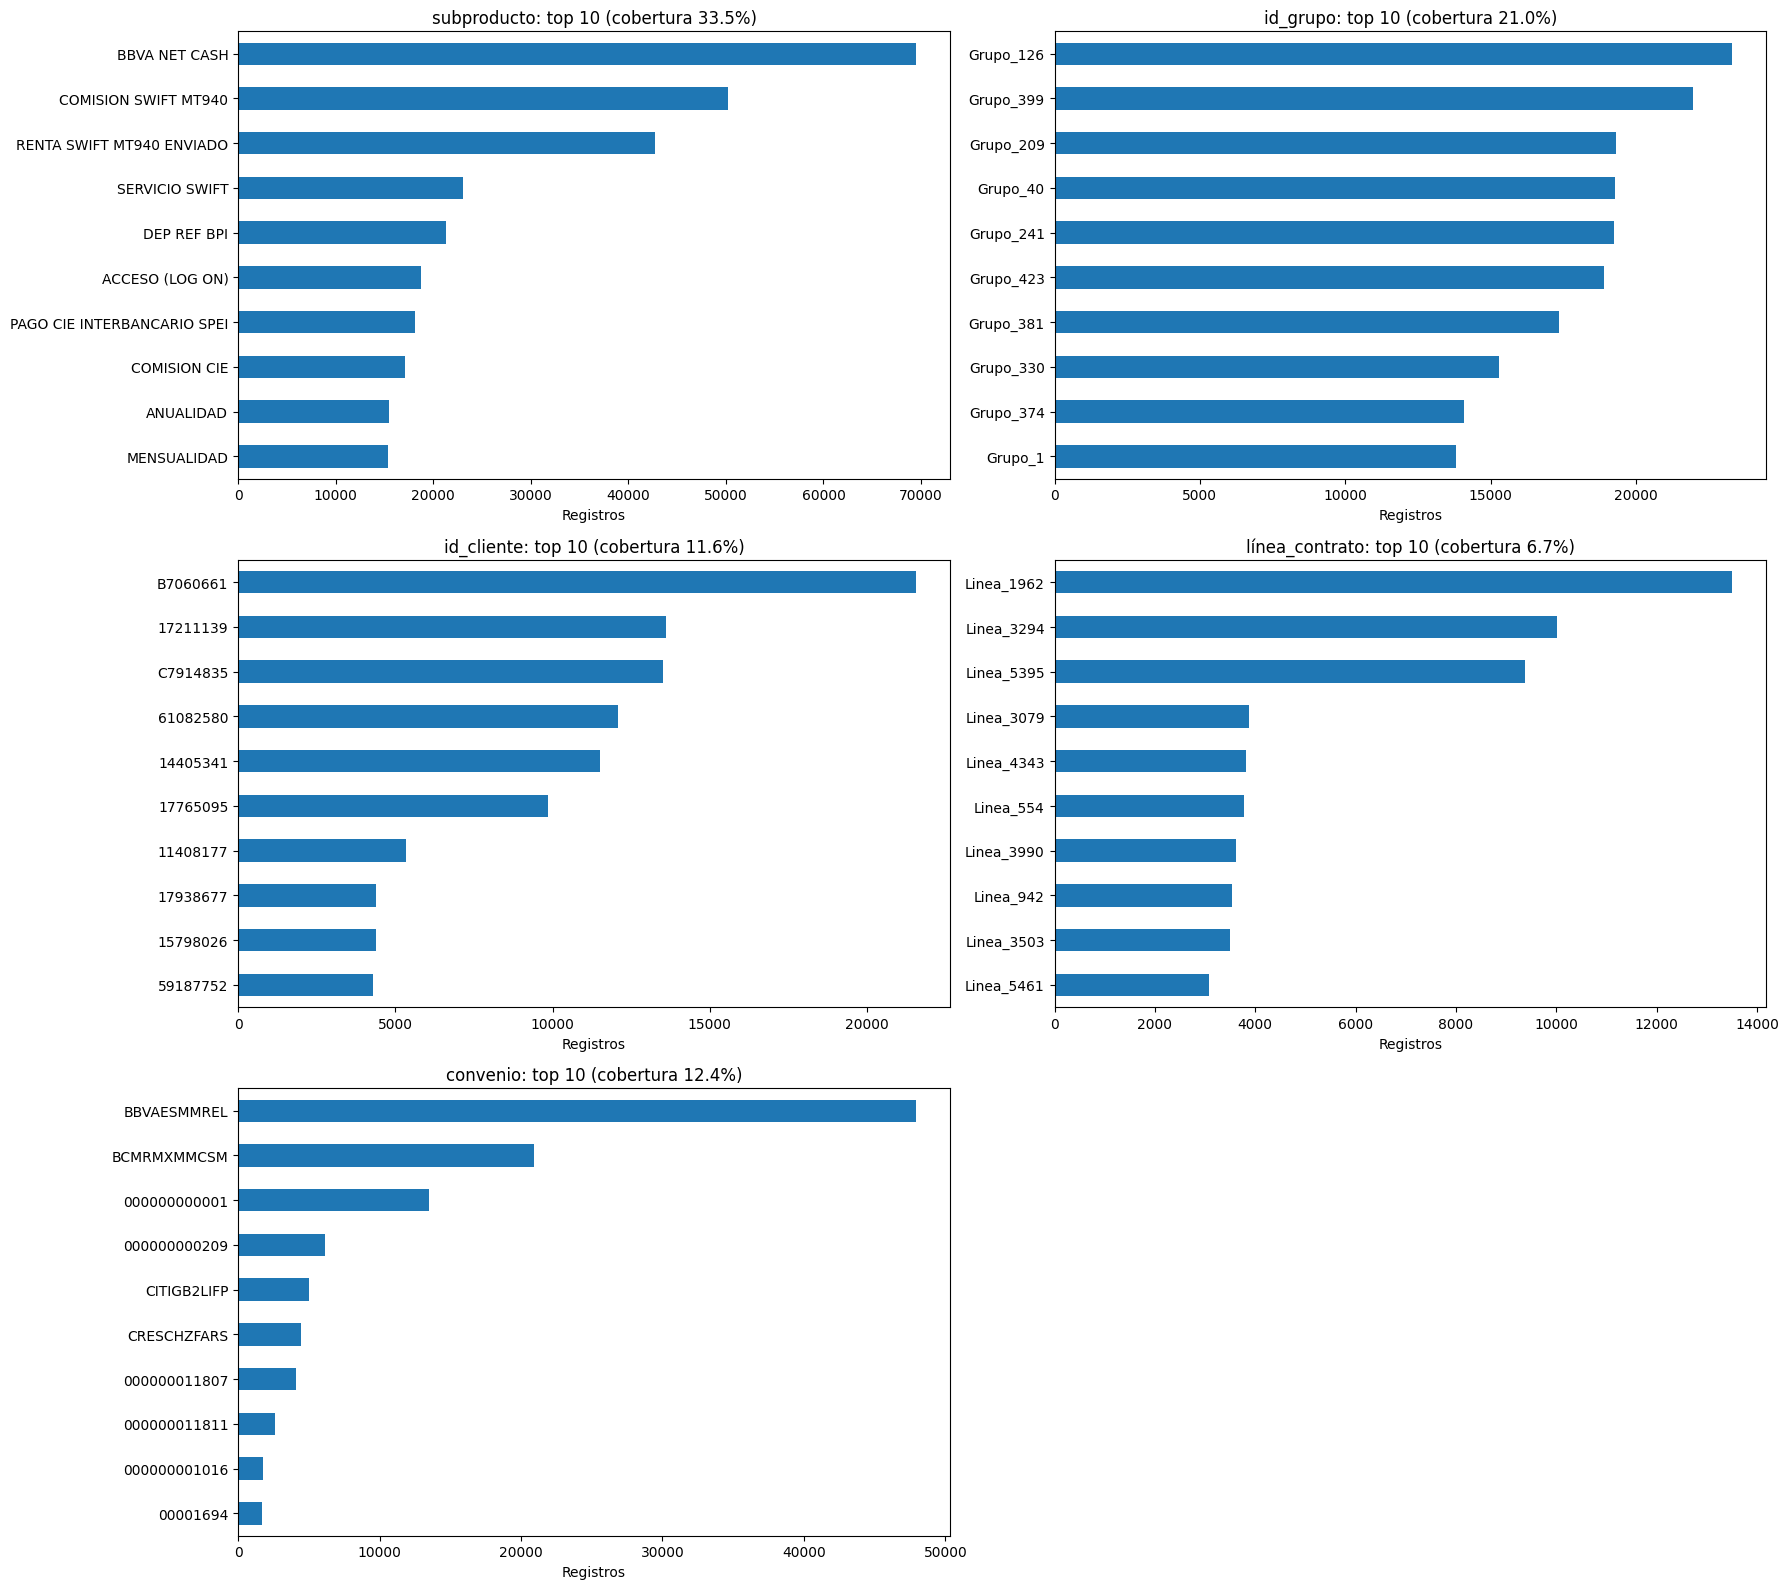

Variables degeneradas (una sola categoría): ['negocio']


In [24]:
cardinalidad = pd.DataFrame({
    "categorias_unicas": df_eda[CATEGORICAS_ORIGINALES].nunique(dropna=False),
    "porcentaje_unico_sobre_filas": 100 * df_eda[CATEGORICAS_ORIGINALES].nunique(dropna=False) / len(df_eda),
}).sort_values("categorias_unicas", ascending=False)
display(cardinalidad)

# Top categorías sin alterar el dataset.
alta_cardinalidad = ["subproducto", "id_grupo", "id_cliente", "línea_contrato", "convenio"]
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
for ax, col in zip(axes.flat, alta_cardinalidad):
    vc = df_eda[col].fillna("Desconocido").value_counts()
    top = vc.head(10).sort_values()
    top.plot.barh(ax=ax)
    cobertura = 100 * vc.head(10).sum() / len(df_eda)
    ax.set_title(f"{col}: top 10 (cobertura {cobertura:.1f}%)")
    ax.set_xlabel("Registros")
    ax.set_ylabel("")
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

print("Variables degeneradas (una sola categoría):", cardinalidad.index[cardinalidad["categorias_unicas"] == 1].tolist())

**Conclusión Q4.** La cardinalidad es alta en `convenio` (**29,819 categorías**), `línea_contrato` (**7,547**), `id_cliente` (**3,466**), `id_grupo` (**706**) y `subproducto` (**340**). Esto desaconseja un one-hot encoding ingenuo para estas variables. `negocio` contiene una sola categoría (`GTB`) y, por tanto, no aporta capacidad discriminante dentro de esta muestra. La estrategia de codificación se reserva para E2 y deberá ajustarse exclusivamente sobre los datos de entrenamiento.

# Q5. Distribuciones sesgadas y transformaciones

In [25]:
series_distribucion = series_outliers.copy()
filas_transformacion = []
for nombre, serie in series_distribucion.items():
    s = pd.to_numeric(serie, errors="coerce").dropna()
    if (s < 0).any():
        filas_transformacion.append({
            "variable": nombre,
            "skew_original": s.skew(),
            "kurtosis_original": s.kurt(),
            "skew_log1p": np.nan,
            "kurtosis_log1p": np.nan,
            "log1p_aplicable": False,
        })
    else:
        slog = np.log1p(s)
        filas_transformacion.append({
            "variable": nombre,
            "skew_original": s.skew(),
            "kurtosis_original": s.kurt(),
            "skew_log1p": slog.skew(),
            "kurtosis_log1p": slog.kurt(),
            "log1p_aplicable": True,
        })

tabla_transformaciones = pd.DataFrame(filas_transformacion).set_index("variable")
display(tabla_transformaciones)

,skew_original,kurtosis_original,skew_log1p,kurtosis_log1p,log1p_aplicable
variable,,,,,
numero_operaciones,89.350268,10699.721990,0.792677,0.370503,True
tarifa_vigente,120.437938,17033.234235,1.948914,3.974940,True
tarifa_anaquel,64.492308,6799.651542,1.058174,0.546230,True
ingreso_bruto,49.827709,5633.688080,0.319283,-1.220543,True
operaciones_t1,83.707917,9321.971049,0.721595,0.338709,True


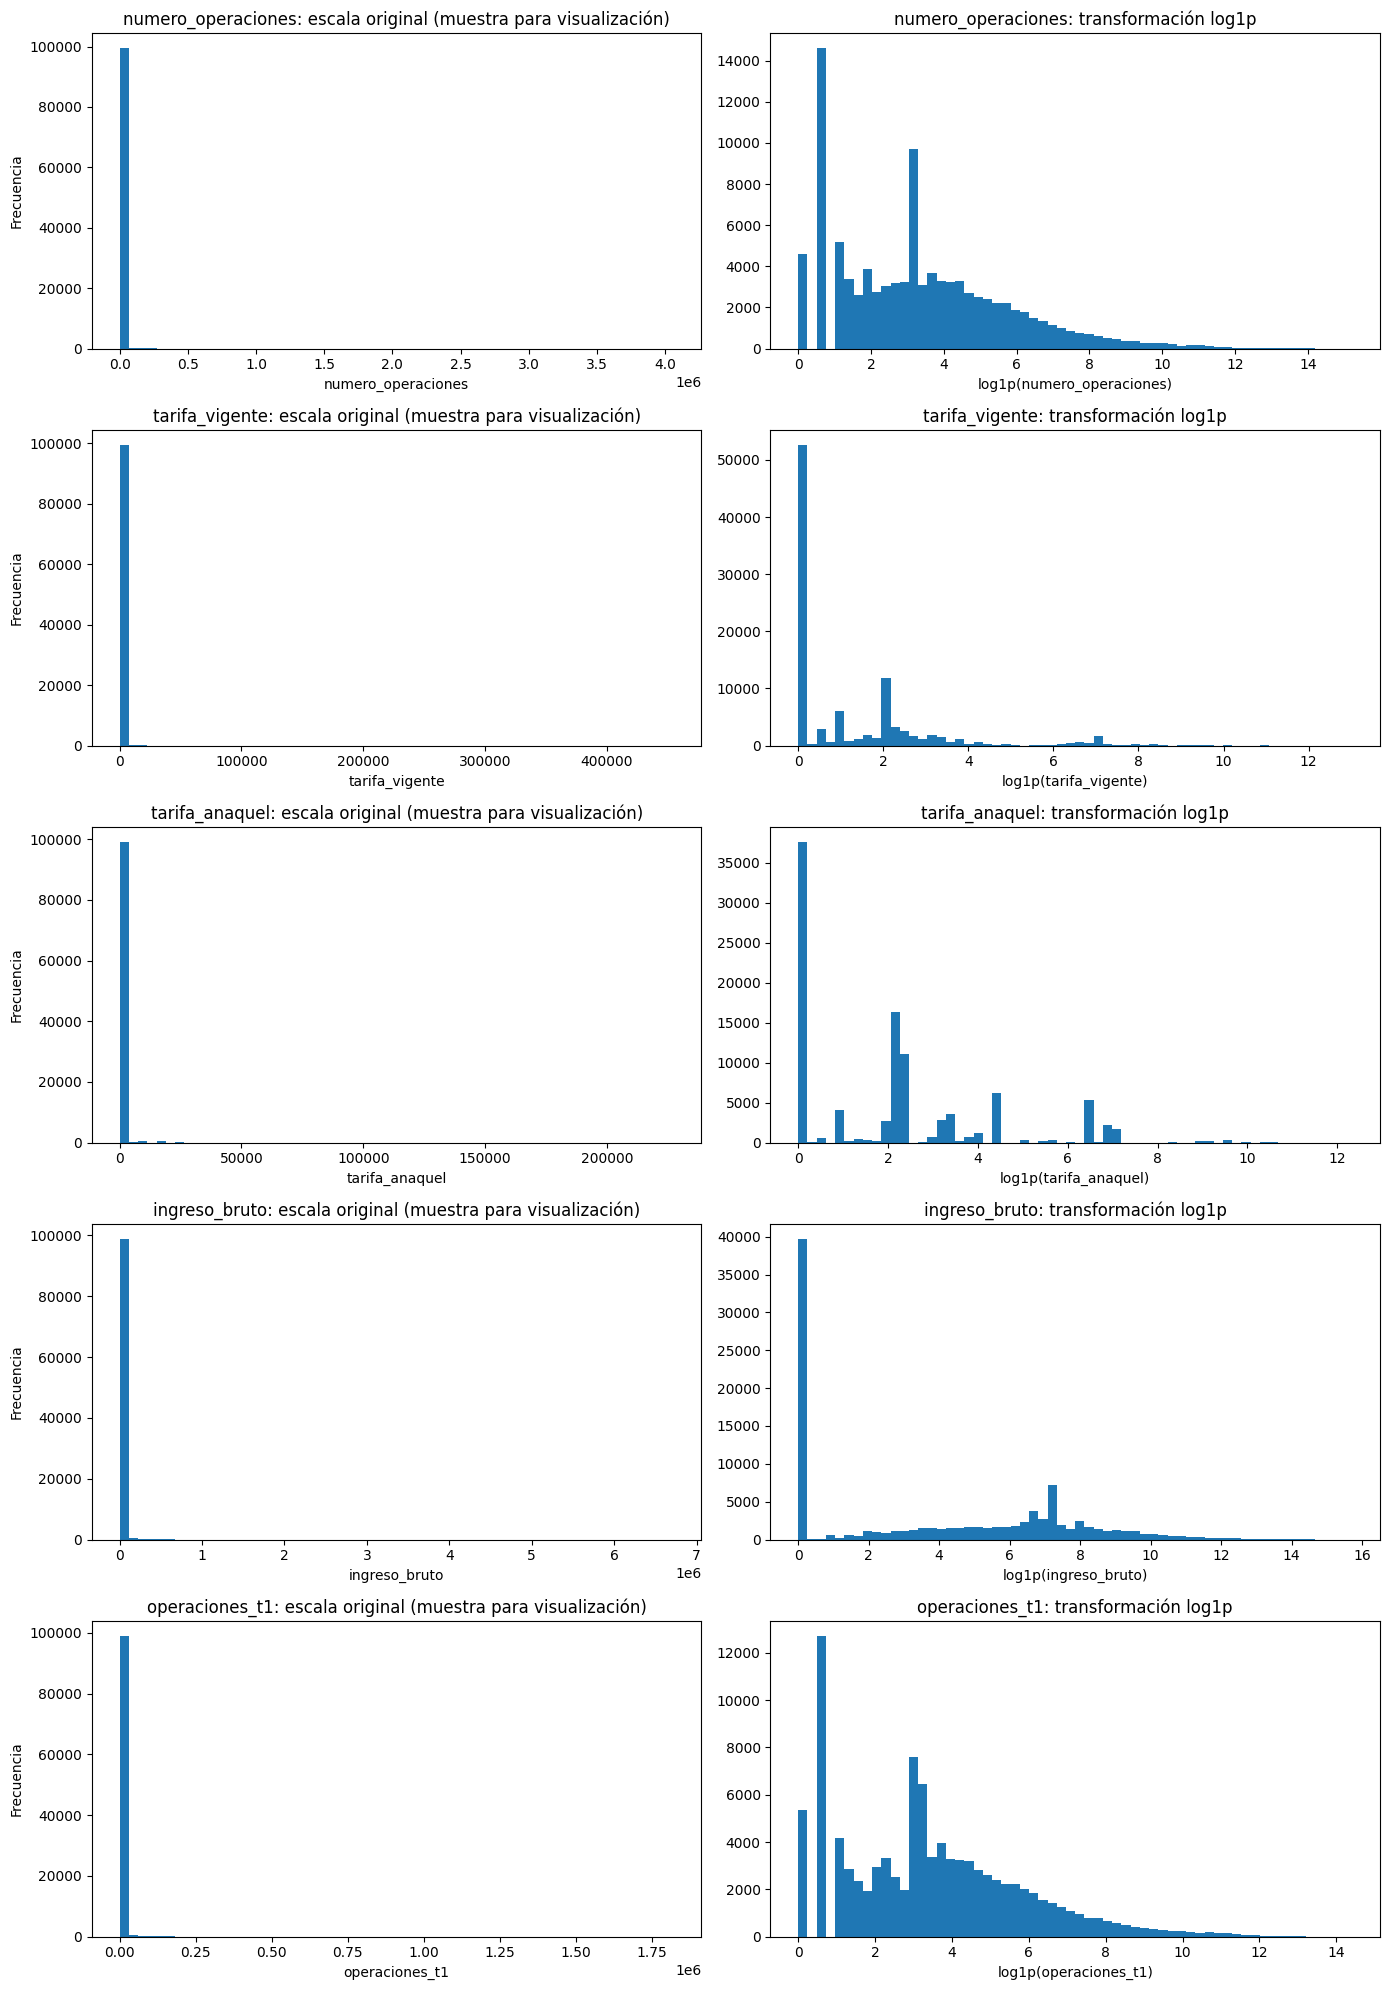

In [26]:
# Estadísticos sobre toda la base; muestra reproducible solo para histogramas.
fig, axes = plt.subplots(len(series_distribucion), 2, figsize=(14, 4 * len(series_distribucion)))
for fila, (nombre, serie) in enumerate(series_distribucion.items()):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    s_plot = s.sample(n=min(100000, len(s)), random_state=RANDOM_STATE) if len(s) else s
    axes[fila, 0].hist(s_plot.to_numpy(), bins=60)
    axes[fila, 0].set_title(f"{nombre}: escala original (muestra para visualización)")
    axes[fila, 0].set_xlabel(nombre)
    axes[fila, 0].set_ylabel("Frecuencia")

    if not (s_plot < 0).any():
        axes[fila, 1].hist(np.log1p(s_plot).to_numpy(), bins=60)
        axes[fila, 1].set_title(f"{nombre}: transformación log1p")
        axes[fila, 1].set_xlabel(f"log1p({nombre})")
    else:
        axes[fila, 1].text(0.5, 0.5, "log1p no aplicable por valores negativos", ha="center", va="center")
        axes[fila, 1].set_axis_off()
plt.tight_layout()
plt.show()

**Conclusión Q5.** Las variables numéricas presentan colas derechas muy pronunciadas. En `operaciones_t1`, la skewness disminuye de **83.71** a **0.72** con `log1p`; en `numero_operaciones`, de **89.35** a **0.79**. También se observa una reducción material en tarifas e ingreso. `log1p` queda justificada como transformación candidata para etapas posteriores, sin asumir normalidad ni sustituir las variables originales en E1.

# Q6. Tendencias temporales, continuidad y estacionalidad

In [27]:
periodos_observados = pd.Index(df_eda["fecha_corte"].dropna().dt.to_period("M").unique()).sort_values()
periodo_completo = pd.period_range(periodos_observados.min(), periodos_observados.max(), freq="M")
periodos_faltantes = periodo_completo.difference(periodos_observados)

print("Inicio:", df_eda["fecha_corte"].min())
print("Fin:", df_eda["fecha_corte"].max())
print("Meses observados:", len(periodos_observados))
print("Meses faltantes entre extremos:", len(periodos_faltantes), list(periodos_faltantes))

mensual = (
    df_eda.assign(mes=df_eda["fecha_corte"].dt.to_period("M"))
    .groupby("mes", observed=True)
    .agg(registros=("numero_operaciones", "size"), operaciones=("numero_operaciones", "sum"))
    .reindex(periodo_completo)
)

# El target se asigna al mes de destino t+1, no al mes de origen t.
target_mensual = (
    df_target_valid.assign(mes_target=df_target_valid["fecha_target"].dt.to_period("M"))
    .groupby("mes_target", observed=True)["operaciones_t1"]
    .agg(target_count="size", target_media="mean", target_mediana="median", target_total="sum")
)
mensual = mensual.join(target_mensual, how="left")
display(mensual)

# Identificación simple de meses anómalos por IQR del número de registros.
q1_m, q3_m = mensual["registros"].quantile([.25, .75])
iqr_m = q3_m - q1_m
li_m, ls_m = q1_m - 1.5 * iqr_m, q3_m + 1.5 * iqr_m
meses_cobertura_atipica = mensual[(mensual["registros"] < li_m) | (mensual["registros"] > ls_m)]
print("Meses con conteo de registros fuera de 1.5*IQR:")
display(meses_cobertura_atipica)

Inicio: 2023-09-30 00:00:00
Fin: 2026-08-31 00:00:00
Meses observados: 36
Meses faltantes entre extremos: 0 []


,registros,operaciones,target_count,target_media,target_mediana,target_total
2023-09,23132,32636043,NaN,NaN,NaN,NaN
2023-10,23408,34580163,20673.0,1605.337977,22.0,33187152.0
2023-11,23208,32707301,20701.0,1522.548524,21.0,31518277.0
2023-12,23247,33042395,20711.0,1538.028053,19.0,31854099.0
2024-01,23863,35717413,20693.0,1651.922486,22.0,34183232.0
2024-02,23728,32667818,21104.0,1481.395186,21.0,31263364.0
2024-03,23390,31703805,21027.0,1442.710372,19.0,30335871.0
2024-04,23881,36809379,21047.0,1666.404903,23.0,35072824.0
2024-05,24201,36950613,21326.0,1659.136688,23.0,35382749.0
2024-06,23991,31953460,21488.0,1421.274106,20.0,30540338.0


Meses con conteo de registros fuera de 1.5*IQR:


,registros,operaciones,target_count,target_media,target_mediana,target_total
2025-09,42966,48045839,21377.0,1627.501474,23.0,34791099.0
2025-10,16971,25442438,14792.0,1584.427461,23.0,23436851.0


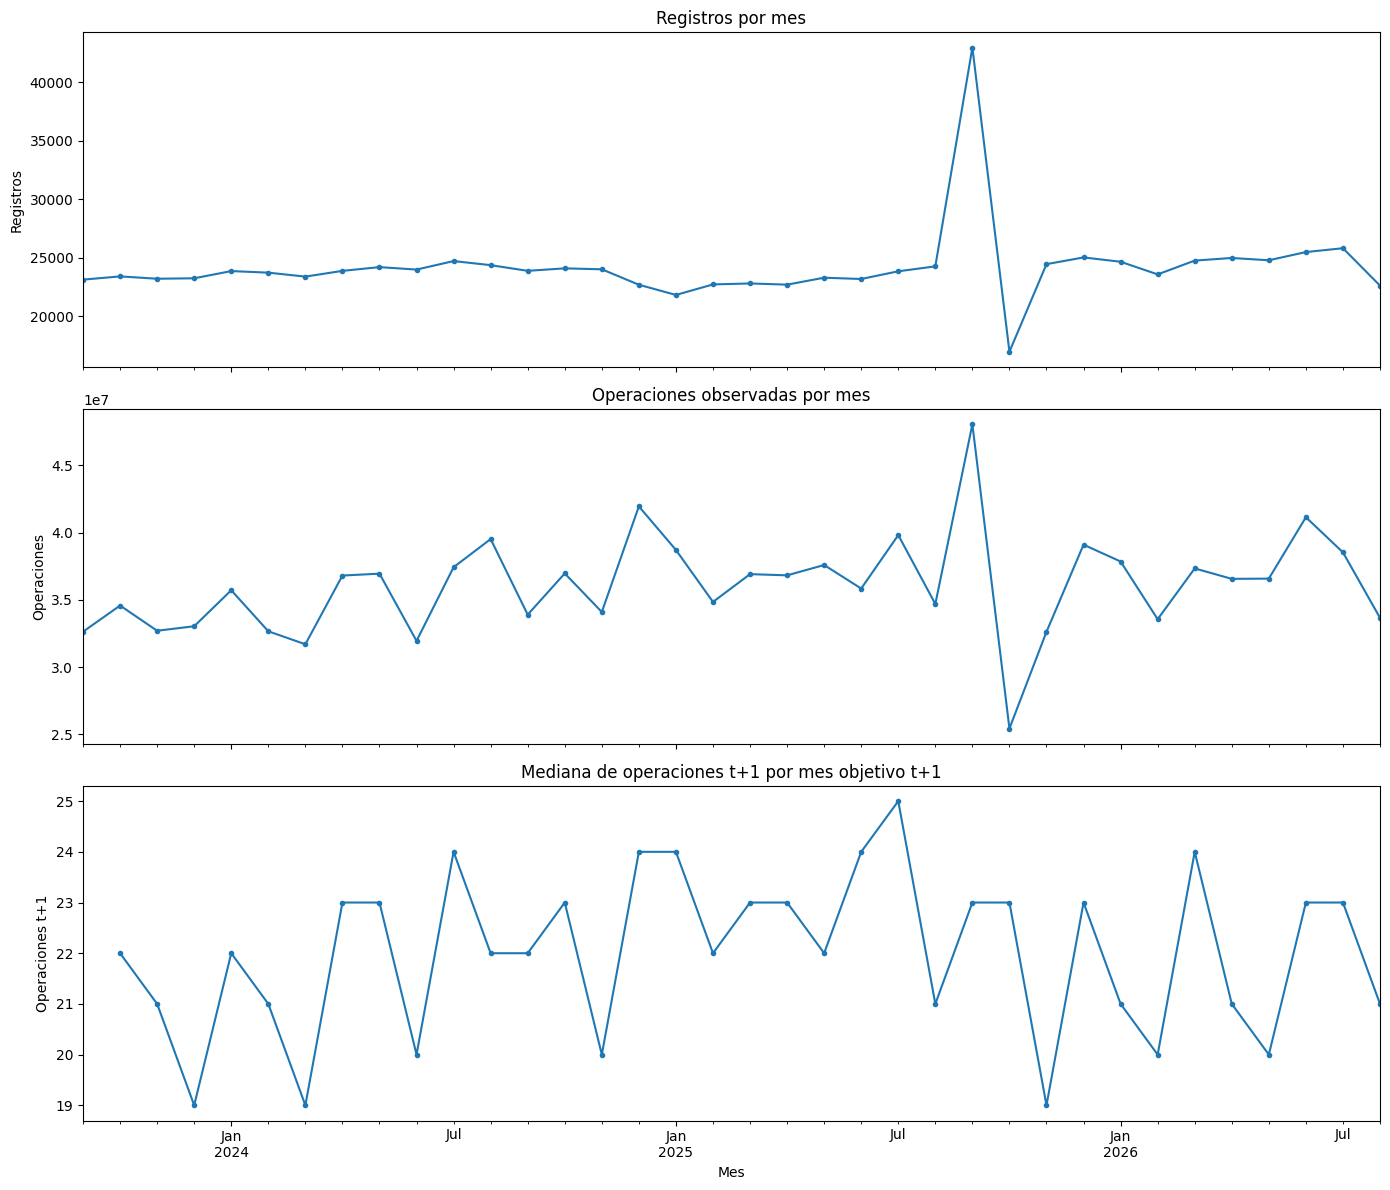

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
mensual["registros"].to_timestamp().plot(ax=axes[0], marker=".")
axes[0].set_title("Registros por mes")
axes[0].set_ylabel("Registros")

mensual["operaciones"].to_timestamp().plot(ax=axes[1], marker=".")
axes[1].set_title("Operaciones observadas por mes")
axes[1].set_ylabel("Operaciones")

mensual["target_mediana"].to_timestamp().plot(ax=axes[2], marker=".")
axes[2].set_title("Mediana de operaciones t+1 por mes objetivo t+1")
axes[2].set_ylabel("Operaciones t+1")
axes[2].set_xlabel("Mes")
plt.tight_layout()
plt.show()

### Q6.1 Continuidad longitudinal por unidad contractual

In [29]:
# Código de unidad para calcular rachas consecutivas sin concatenar strings ni construir un MultiIndex masivo.
continuidad = df_panel[LLAVE_UNIDAD + ["fecha_corte"]].dropna(subset=["fecha_corte"]).copy()
continuidad["_unit_code"] = continuidad.groupby(
    LLAVE_UNIDAD, dropna=False, observed=True, sort=False
).ngroup()
continuidad["_month_idx"] = indice_mes(continuidad["fecha_corte"])
continuidad = continuidad.sort_values(["_unit_code", "_month_idx"])
continuidad["_gap"] = continuidad.groupby("_unit_code")["_month_idx"].diff()
continuidad["_new_run"] = continuidad["_gap"].ne(1).astype(int)
continuidad["_run_id"] = continuidad.groupby("_unit_code")["_new_run"].cumsum()

run_lengths = (
    continuidad.groupby(["_unit_code", "_run_id"], observed=True)
    .size()
    .rename("run_length")
    .reset_index()
)
longest_run = run_lengths.groupby("_unit_code")["run_length"].max()
months_observed = continuidad.groupby("_unit_code")["_month_idx"].nunique()
product_by_unit = continuidad.groupby("_unit_code")["producto"].first()

unit_history = pd.DataFrame({
    "meses_observados": months_observed,
    "racha_consecutiva_max": longest_run,
    "producto": product_by_unit,
})

display(unit_history[["meses_observados", "racha_consecutiva_max"]].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

thresholds = [2, 3, 6, 12, 24, 36]
continuidad_thresholds = pd.DataFrame({
    "meses_consecutivos_minimos": thresholds,
    "unidades": [(unit_history["racha_consecutiva_max"] >= k).sum() for k in thresholds],
    "porcentaje_unidades": [100 * (unit_history["racha_consecutiva_max"] >= k).mean() for k in thresholds],
})
display(continuidad_thresholds)

continuidad_producto = (
    unit_history.groupby("producto", observed=True)["racha_consecutiva_max"]
    .agg(unidades="size", mediana="median", media="mean", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
    .sort_values("mediana")
)
display(continuidad_producto)

,meses_observados,racha_consecutiva_max
count,101548.000000,101548.000000
mean,8.300646,6.892081
std,11.357357,9.727738
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,12.000000,10.000000
90%,28.000000,25.000000
95%,35.000000,26.000000
99%,36.000000,36.000000


,meses_consecutivos_minimos,unidades,porcentaje_unidades
0,2,41505,40.872297
1,3,37535,36.962816
2,6,31615,31.133060
3,12,22269,21.929531
4,24,13764,13.554181
5,36,2666,2.625359


,unidades,mediana,media,p25,p75
producto,,,,,
BBVA NET CASH,35841,1.0,5.782316,1.0,8.0
DOMICILIACION,35748,1.0,1.145127,1.0,1.0
SERVICIOS T.I.B.,13,1.0,1.153846,1.0,1.0
APIS EMPRESARIALES,105,3.0,13.714286,1.0,29.0
CENTRALIZACION DE CUENTAS,1116,5.0,15.762545,5.0,31.0
SERVICIO INTEGRAL DE TESORERIA (SIT),5905,6.0,9.010500,2.0,10.0
DEPOSITO EMPRESARIAL DOLARES,215,10.0,12.539535,5.0,26.0
DEPOSITO EMPRESARIAL,3593,10.0,12.271361,3.0,22.0
OPERACION T.I.B.,560,10.0,14.823214,10.0,26.0


### Q6.2 Exploración de estacionalidad

> La estacionalidad se evalúa con el mes calendario del target (`fecha_target`), mientras que la cobertura del target se analiza desde el mes de origen para identificar rupturas longitudinales.

,count,media,mediana,p25,p75
mes_calendario_target,,,,,
1,59015,1742.915208,22.0,3.0,133.0
2,58989,1566.815457,21.0,4.0,131.0
3,60055,1598.056099,22.0,4.0,136.0
4,60749,1621.713559,22.0,4.0,139.0
5,61612,1666.329173,22.0,3.0,133.0
6,61934,1563.240110,22.0,3.0,134.0
7,62164,1708.519143,24.0,4.0,142.0
8,59874,1651.946554,22.0,3.0,126.0
9,42531,1578.824293,22.0,4.0,136.0


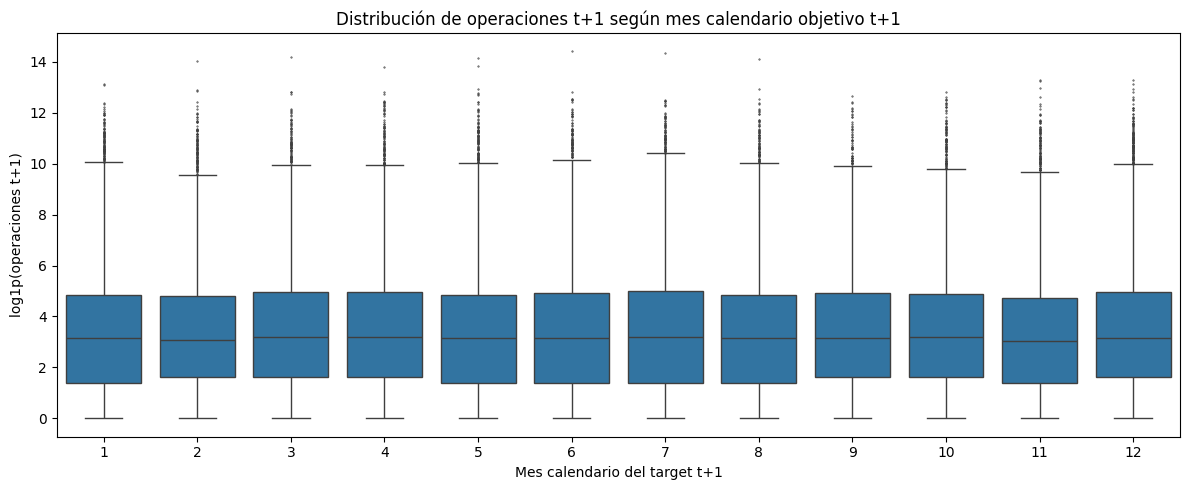

Autocorrelación lag 12 de operaciones mensuales agregadas: 0.0538
Interpretación: mes de origen t y mes objetivo t+1 son conceptos distintos. La estacionalidad del target se evalúa con fecha_target. Con aproximadamente tres ciclos anuales, cualquier patrón se interpreta como evidencia exploratoria.


In [30]:
# Se analiza operaciones_t1 según el mes calendario DEL TARGET (t+1), no el mes de origen t.
seasonal_stats = (
    df_target_valid.assign(mes_calendario_target=df_target_valid["fecha_target"].dt.month)
    .groupby("mes_calendario_target", observed=True)["operaciones_t1"]
    .agg(count="size", media="mean", mediana="median", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
)
display(seasonal_stats)

muestra_season = df_target_valid[["fecha_corte", "fecha_target", "operaciones_t1"]].sample(
    n=min(100000, len(df_target_valid)), random_state=RANDOM_STATE
).copy()
muestra_season["mes_origen_t"] = muestra_season["fecha_corte"].dt.month
muestra_season["mes_target_t1"] = muestra_season["fecha_target"].dt.month
muestra_season["log1p_operaciones_t1"] = np.log1p(muestra_season["operaciones_t1"].clip(lower=0))

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=muestra_season, x="mes_target_t1", y="log1p_operaciones_t1", ax=ax, fliersize=0.5)
ax.set_title("Distribución de operaciones t+1 según mes calendario objetivo t+1")
ax.set_xlabel("Mes calendario del target t+1")
ax.set_ylabel("log1p(operaciones t+1)")
plt.tight_layout()
plt.show()

if len(mensual["operaciones"].dropna()) > 12:
    autocorr_12 = mensual["operaciones"].autocorr(lag=12)
    print(f"Autocorrelación lag 12 de operaciones mensuales agregadas: {autocorr_12:.4f}")
else:
    autocorr_12 = np.nan
    print("No hay suficientes meses para autocorrelación lag 12.")

print(
    "Interpretación: mes de origen t y mes objetivo t+1 son conceptos distintos. La estacionalidad del target se evalúa "
    "con fecha_target. Con aproximadamente tres ciclos anuales, cualquier patrón se interpreta como evidencia exploratoria."
)

**Conclusión Q6.** La base cubre **36 meses consecutivos** sin huecos globales, pero la continuidad por unidad es mucho menor: **40.87%** de las unidades alcanza al menos 2 meses consecutivos, **21.93%** llega a 12 meses y solo **2.63%** mantiene los 36 meses. La cobertura del target cae de forma excepcional a **34.47% en septiembre de 2025** y **51.03% en octubre de 2025**; agosto de 2026 tiene 0% por ser el último corte disponible. La autocorrelación agregada a 12 meses es baja (**0.054**), por lo que el EDA no aporta evidencia de una estacionalidad anual fuerte. La ruptura de continuidad de septiembre–octubre de 2025 debe considerarse en la validación temporal posterior.

# Q7. Correlación entre predictores disponibles en t y `operaciones_t1`

,numero_operaciones,tarifa_vigente,tarifa_anaquel,ingreso_bruto,operaciones_t1
numero_operaciones,1.000000,-0.002884,-0.006085,0.294773,0.896405
tarifa_vigente,-0.002884,1.000000,0.114251,0.033662,-0.002890
tarifa_anaquel,-0.006085,0.114251,1.000000,0.010294,-0.006088
ingreso_bruto,0.294773,0.033662,0.010294,1.000000,0.284982
operaciones_t1,0.896405,-0.002890,-0.006088,0.284982,1.000000


,numero_operaciones,tarifa_vigente,tarifa_anaquel,ingreso_bruto,operaciones_t1
numero_operaciones,1.000000,-0.038564,-0.089283,0.279837,0.937835
tarifa_vigente,-0.038564,1.000000,0.367695,0.475220,-0.071785
tarifa_anaquel,-0.089283,0.367695,1.000000,0.211515,-0.088966
ingreso_bruto,0.279837,0.475220,0.211515,1.000000,0.273690
operaciones_t1,0.937835,-0.071785,-0.088966,0.273690,1.000000


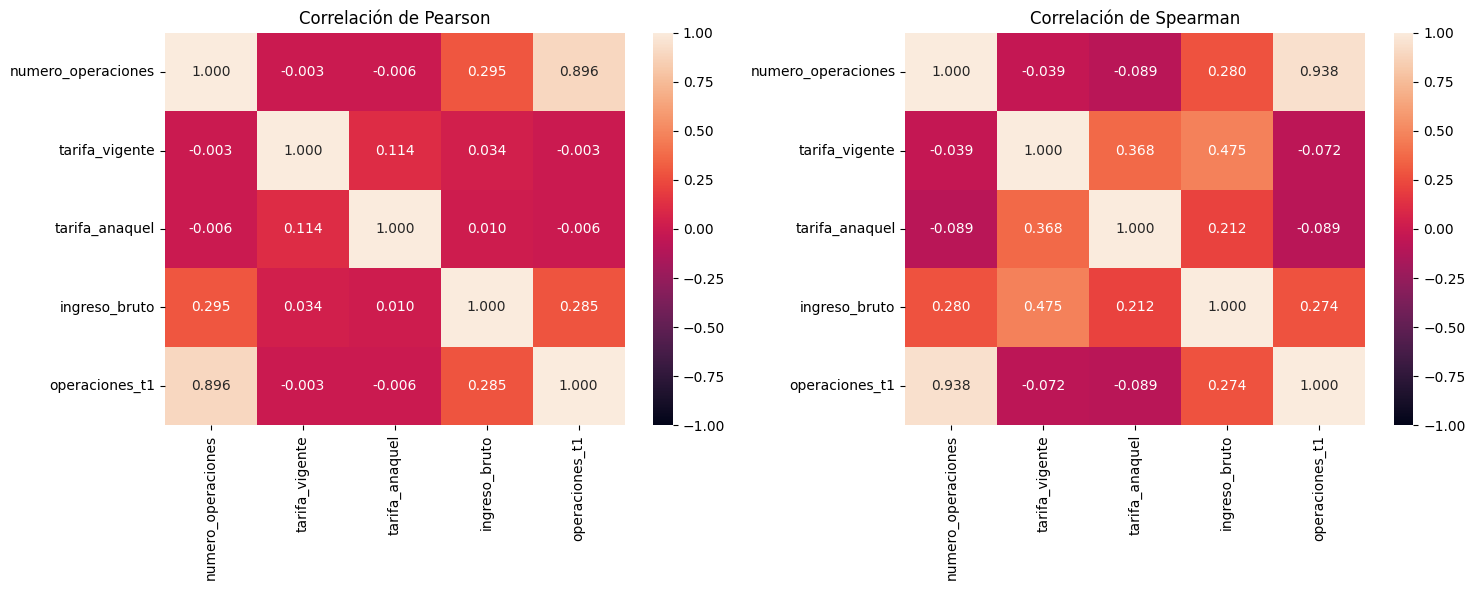

In [31]:
VARIABLES_CORR = ["numero_operaciones", "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto", "operaciones_t1"]
correlacion_pearson = df_target_valid[VARIABLES_CORR].corr(method="pearson")
correlacion_spearman = df_target_valid[VARIABLES_CORR].corr(method="spearman")

display(correlacion_pearson)
display(correlacion_spearman)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(correlacion_pearson, annot=True, fmt=".3f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlación de Pearson")
sns.heatmap(correlacion_spearman, annot=True, fmt=".3f", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlación de Spearman")
plt.tight_layout()
plt.show()

In [32]:
# Colinealidad entre predictores numéricos disponibles en t.
pred_num = ["numero_operaciones", "tarifa_vigente", "tarifa_anaquel", "ingreso_bruto"]
corr_pred = df_target_valid[pred_num].corr(method="pearson").abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))
pares_colinealidad = (
    upper.stack()
    .rename("abs_pearson")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
display(pares_colinealidad)

if len(pares_colinealidad):
    max_corr_pred = pares_colinealidad.iloc[0]["abs_pearson"]
    print(f"Mayor |Pearson| entre predictores numéricos: {max_corr_pred:.3f}")
    print("Criterio exploratorio: |r| >= 0.80 se consideraría colinealidad fuerte.")
else:
    max_corr_pred = np.nan

,variable_1,variable_2,abs_pearson
0,numero_operaciones,ingreso_bruto,0.294773
1,tarifa_vigente,tarifa_anaquel,0.114251
2,tarifa_vigente,ingreso_bruto,0.033662
3,tarifa_anaquel,ingreso_bruto,0.010294
4,numero_operaciones,tarifa_anaquel,0.006085
5,numero_operaciones,tarifa_vigente,0.002884


Mayor |Pearson| entre predictores numéricos: 0.295
Criterio exploratorio: |r| >= 0.80 se consideraría colinealidad fuerte.


**Conclusión Q7.** La señal temporal individual es muy fuerte: `numero_operaciones_t` presenta correlación **Pearson = 0.896** y **Spearman = 0.938** con `operaciones_t1`. En contraste, `tarifa_vigente` y `tarifa_anaquel` muestran correlaciones lineales prácticamente nulas con el target (≈ **-0.003** y **-0.006**) y asociaciones monotónicas débiles (≈ **-0.072** y **-0.089**). `ingreso_bruto` presenta una relación moderada-baja con el target (Pearson ≈ **0.285**). Entre predictores numéricos, la mayor correlación absoluta es **0.295**, por lo que no se observa colinealidad fuerte bajo el umbral exploratorio de |r| ≥ 0.80.

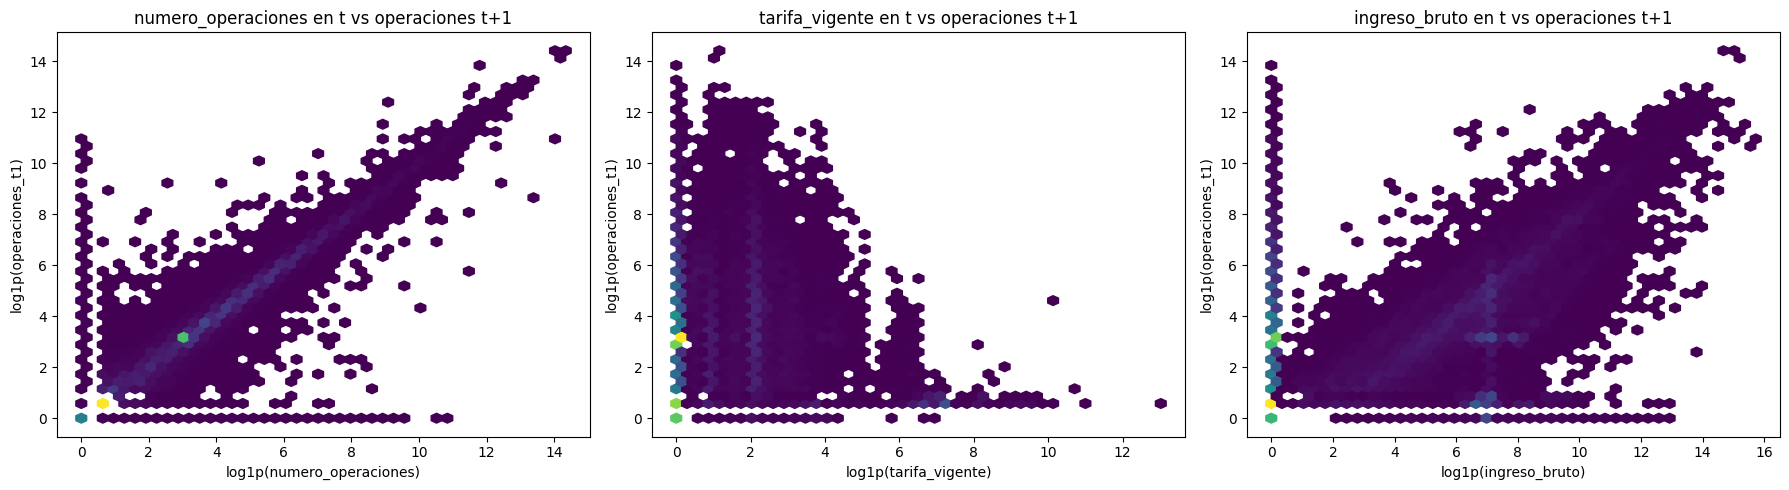

Las asociaciones son descriptivas/correlacionales y no demuestran causalidad.


In [33]:
# Dispersión contra el target; estadísticos sobre toda la base, muestra solo para visualizar.
muestra_corr = df_target_valid[
    ["numero_operaciones", "tarifa_vigente", "ingreso_bruto", "operaciones_t1"]
].sample(n=min(50000, len(df_target_valid)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, xcol in zip(axes, ["numero_operaciones", "tarifa_vigente", "ingreso_bruto"]):
    x = np.log1p(muestra_corr[xcol].clip(lower=0))
    y = np.log1p(muestra_corr["operaciones_t1"].clip(lower=0))
    ax.hexbin(x, y, gridsize=45, mincnt=1)
    ax.set_title(f"{xcol} en t vs operaciones t+1")
    ax.set_xlabel(f"log1p({xcol})")
    ax.set_ylabel("log1p(operaciones_t1)")
plt.tight_layout()
plt.show()

print("Las asociaciones son descriptivas/correlacionales y no demuestran causalidad.")

# Q8. Distribución de `operaciones_t1` por categorías clave

In [34]:
def resumen_target_por_categoria(df, categoria, target="operaciones_t1"):
    return (
        df.groupby(df[categoria].fillna("Desconocido"), observed=True)[target]
        .agg(count="size", media="mean", mediana="median", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
        .sort_values("count", ascending=False)
    )

resumenes_categoria = {}
for categoria in ["producto", "industria", "moneda", "id_grupo", "subproducto"]:
    resumenes_categoria[categoria] = resumen_target_por_categoria(df_target_valid, categoria)
    print(f"\nResumen por {categoria} (primeras 20 categorías por volumen):")
    display(resumenes_categoria[categoria].head(20))


Resumen por producto (primeras 20 categorías por volumen):


,count,media,mediana,p25,p75
producto,,,,,
BBVA NET CASH,227036,2039.082366,34.0,6.0,252.00
SWIFT,134175,523.592115,21.0,6.0,40.00
CONCENTRACION INMEDIATA EMPRESARIAL CIE,94215,1227.970811,17.0,4.0,100.00
SERVICIOS BBVA NET CASH,80639,94.281812,2.0,0.0,73.00
SERVICIO INTEGRAL DE TESORERIA (SIT),50676,544.789151,14.0,4.0,58.00
DEPOSITO EMPRESARIAL,41401,592.263593,113.0,33.0,358.00
HOST TO HOST SERVICIOS,17862,3510.314634,221.0,38.0,996.00
CENTRALIZACION DE CUENTAS,16475,242.772443,1.0,0.0,8.00
PAGOS ELECTRONICOS PAGEL,14619,3072.679937,156.0,17.0,918.00



Resumen por industria (primeras 20 categorías por volumen):


,count,media,mediana,p25,p75
industria,,,,,
CONSUMER,121725,1810.499848,38.0,7.0,197.0
FINANCIAL SERVICES,68374,2730.175915,29.0,4.0,267.0
FINANCIAL INSTITUTIONS,67831,3043.901903,22.0,2.0,120.0
UTILITIES,67391,504.560653,19.0,2.0,36.0
Desconocido,60751,513.526674,23.0,4.0,136.0
"TELECOMS, TECHNOLOGY & MEDIA",53600,2323.729030,26.0,4.0,195.0
CONSTRUCTION & CONSTRUCTION MATERIALS,45566,435.644691,13.0,2.0,65.0
RETAIL,39469,1751.839697,21.0,3.0,112.0
"AUTOS, COMPONENTS & DURABLE GOODS",32398,4089.208439,31.0,4.0,183.0



Resumen por moneda (primeras 20 categorías por volumen):


,count,media,mediana,p25,p75
moneda,,,,,
MXP,583544,1873.331070,25.0,4.0,163.0
Desconocido,66052,522.592109,15.0,3.0,85.0
USD,44099,51.759110,20.0,2.0,23.0
EUR,689,23.880987,19.0,4.0,22.0



Resumen por id_grupo (primeras 20 categorías por volumen):


,count,media,mediana,p25,p75
id_grupo,,,,,
Grupo_399,19346,55.824408,9.0,1.00,23.0
Grupo_126,17519,1586.856499,28.0,5.00,292.0
Grupo_209,16776,161.698081,19.0,2.00,23.0
Grupo_241,16319,7101.931552,22.0,9.00,171.0
Grupo_40,15836,3238.630715,83.0,7.75,676.5
Grupo_381,13875,273.618667,5.0,2.00,16.0
Grupo_330,13436,412.688375,88.0,54.00,133.0
Grupo_423,12869,118.098065,17.0,2.00,51.0
Grupo_374,11970,1936.065414,25.0,8.00,107.0



Resumen por subproducto (primeras 20 categorías por volumen):


,count,media,mediana,p25,p75
subproducto,,,,,
BBVA NET CASH,64598,1452.234543,68.0,12.0,308.0
COMISION SWIFT MT940,47364,1001.033781,23.0,21.0,44.0
RENTA SWIFT MT940 ENVIADO,40981,456.626217,23.0,21.0,46.0
SERVICIO SWIFT,20333,1.049132,1.0,1.0,1.0
ACCESO (LOG ON),16153,275.367548,133.0,45.0,310.0
COMISION CIE,16094,1065.503169,16.0,0.0,109.0
PAGO CIE INTERBANCARIO SPEI,15606,196.304050,8.0,3.0,38.0
ANUALIDAD,14450,0.000000,0.0,0.0,0.0
MENSUALIDAD,14448,1.000000,1.0,1.0,1.0


In [35]:
def kruskal_categoria(df, categoria, target="operaciones_t1", top_n=None, min_n=30, etiqueta_muestra="observaciones_mensuales"):
    temp = df[[categoria, target]].copy()
    temp[categoria] = temp[categoria].fillna("Desconocido")
    conteos = temp[categoria].value_counts()
    categorias = conteos[conteos >= min_n].index
    if top_n is not None:
        categorias = categorias[:top_n]
    temp = temp[temp[categoria].isin(categorias)]
    grupos = [g[target].dropna().to_numpy() for _, g in temp.groupby(categoria, observed=True)]
    grupos = [g for g in grupos if len(g) > 0]
    if len(grupos) < 2:
        return {"muestra": etiqueta_muestra, "categoria": categoria, "k": len(grupos), "n": len(temp), "H": np.nan, "p_value": np.nan, "epsilon2": np.nan}
    H, p = kruskal(*grupos)
    k = len(grupos)
    n = sum(len(g) for g in grupos)
    epsilon2 = max(0.0, (H - k + 1) / (n - k)) if n > k else np.nan
    return {"muestra": etiqueta_muestra, "categoria": categoria, "k": k, "n": n, "H": H, "p_value": p, "epsilon2": epsilon2}

resultados_kw = [
    kruskal_categoria(df_target_valid, "producto"),
    kruskal_categoria(df_target_valid, "industria"),
    kruskal_categoria(df_target_valid, "moneda"),
    kruskal_categoria(df_target_valid, "id_grupo", top_n=30),
    kruskal_categoria(df_target_valid, "subproducto", top_n=30),
]
tabla_kw = pd.DataFrame(resultados_kw)
display(tabla_kw)
print(
    "Kruskal-Wallis evalúa diferencias distribucionales. Debido a observaciones repetidas en el tiempo por unidad, "
    "los p-values sobre registros mensuales se interpretan como evidencia exploratoria, no como inferencia causal independiente. "
    "epsilon2 se incluye como tamaño de efecto aproximado."
)

,muestra,categoria,k,n,H,p_value,epsilon2
0,observaciones_mensuales,producto,14,694380,83340.044915,0.0,0.120005
1,observaciones_mensuales,industria,18,694384,13834.578343,0.0,0.019900
2,observaciones_mensuales,moneda,4,694384,8487.086345,0.0,0.012218
3,observaciones_mensuales,id_grupo,30,279944,29692.967175,0.0,0.105975
4,observaciones_mensuales,subproducto,30,452721,174157.726033,0.0,0.384653


Kruskal-Wallis evalúa diferencias distribucionales. Debido a observaciones repetidas en el tiempo por unidad, los p-values sobre registros mensuales se interpretan como evidencia exploratoria, no como inferencia causal independiente. epsilon2 se incluye como tamaño de efecto aproximado.


### Q8.1 Robustez frente a repetición longitudinal

Como comprobación adicional, el target se resume por unidad contractual mediante su mediana y se repite Kruskal–Wallis. Esto reduce la pseudo-replicación temporal, aunque no convierte el análisis en un modelo longitudinal formal.


In [36]:
# Una fila por unidad contractual: mediana histórica del target válido.
unidad_target = (
    df_target_valid.groupby(LLAVE_UNIDAD, dropna=False, observed=True)
    .agg(
        operaciones_t1_mediana=("operaciones_t1", "median"),
        industria=("industria", "first"),
    )
    .reset_index()
)

resultados_kw_unidad = [
    kruskal_categoria(unidad_target, "producto", target="operaciones_t1_mediana", min_n=10, etiqueta_muestra="mediana_por_unidad"),
    kruskal_categoria(unidad_target, "industria", target="operaciones_t1_mediana", min_n=10, etiqueta_muestra="mediana_por_unidad"),
    kruskal_categoria(unidad_target, "moneda", target="operaciones_t1_mediana", min_n=10, etiqueta_muestra="mediana_por_unidad"),
    kruskal_categoria(unidad_target, "id_grupo", target="operaciones_t1_mediana", top_n=30, min_n=10, etiqueta_muestra="mediana_por_unidad"),
    kruskal_categoria(unidad_target, "subproducto", target="operaciones_t1_mediana", top_n=30, min_n=10, etiqueta_muestra="mediana_por_unidad"),
]
tabla_kw_unidad = pd.DataFrame(resultados_kw_unidad)
display(tabla_kw_unidad)

comparacion_kw = tabla_kw[["categoria", "epsilon2", "p_value"]].merge(
    tabla_kw_unidad[["categoria", "epsilon2", "p_value"]],
    on="categoria",
    how="outer",
    suffixes=("_mensual", "_unidad"),
)
display(comparacion_kw)
print(
    "Criterio de interpretación: si el patrón de tamaños de efecto persiste al resumir por unidad, la heterogeneidad categórica "
    "es más robusta a la repetición temporal. Diferencias fuertes entre ambos análisis indican que la dependencia longitudinal importa."
)


,muestra,categoria,k,n,H,p_value,epsilon2
0,mediana_por_unidad,producto,13,41501,3935.171077,0.000000e+00,0.094562
1,mediana_por_unidad,industria,18,41505,649.415534,4.789898e-127,0.015244
2,mediana_por_unidad,moneda,4,41505,515.027768,2.641419e-111,0.012338
3,mediana_por_unidad,id_grupo,30,17054,1663.487392,0.000000e+00,0.096011
4,mediana_por_unidad,subproducto,30,24048,9278.452029,0.000000e+00,0.385105


,categoria,epsilon2_mensual,p_value_mensual,epsilon2_unidad,p_value_unidad
0,id_grupo,0.105975,0.0,0.096011,0.000000e+00
1,industria,0.019900,0.0,0.015244,4.789898e-127
2,moneda,0.012218,0.0,0.012338,2.641419e-111
3,producto,0.120005,0.0,0.094562,0.000000e+00
4,subproducto,0.384653,0.0,0.385105,0.000000e+00


Criterio de interpretación: si el patrón de tamaños de efecto persiste al resumir por unidad, la heterogeneidad categórica es más robusta a la repetición temporal. Diferencias fuertes entre ambos análisis indican que la dependencia longitudinal importa.


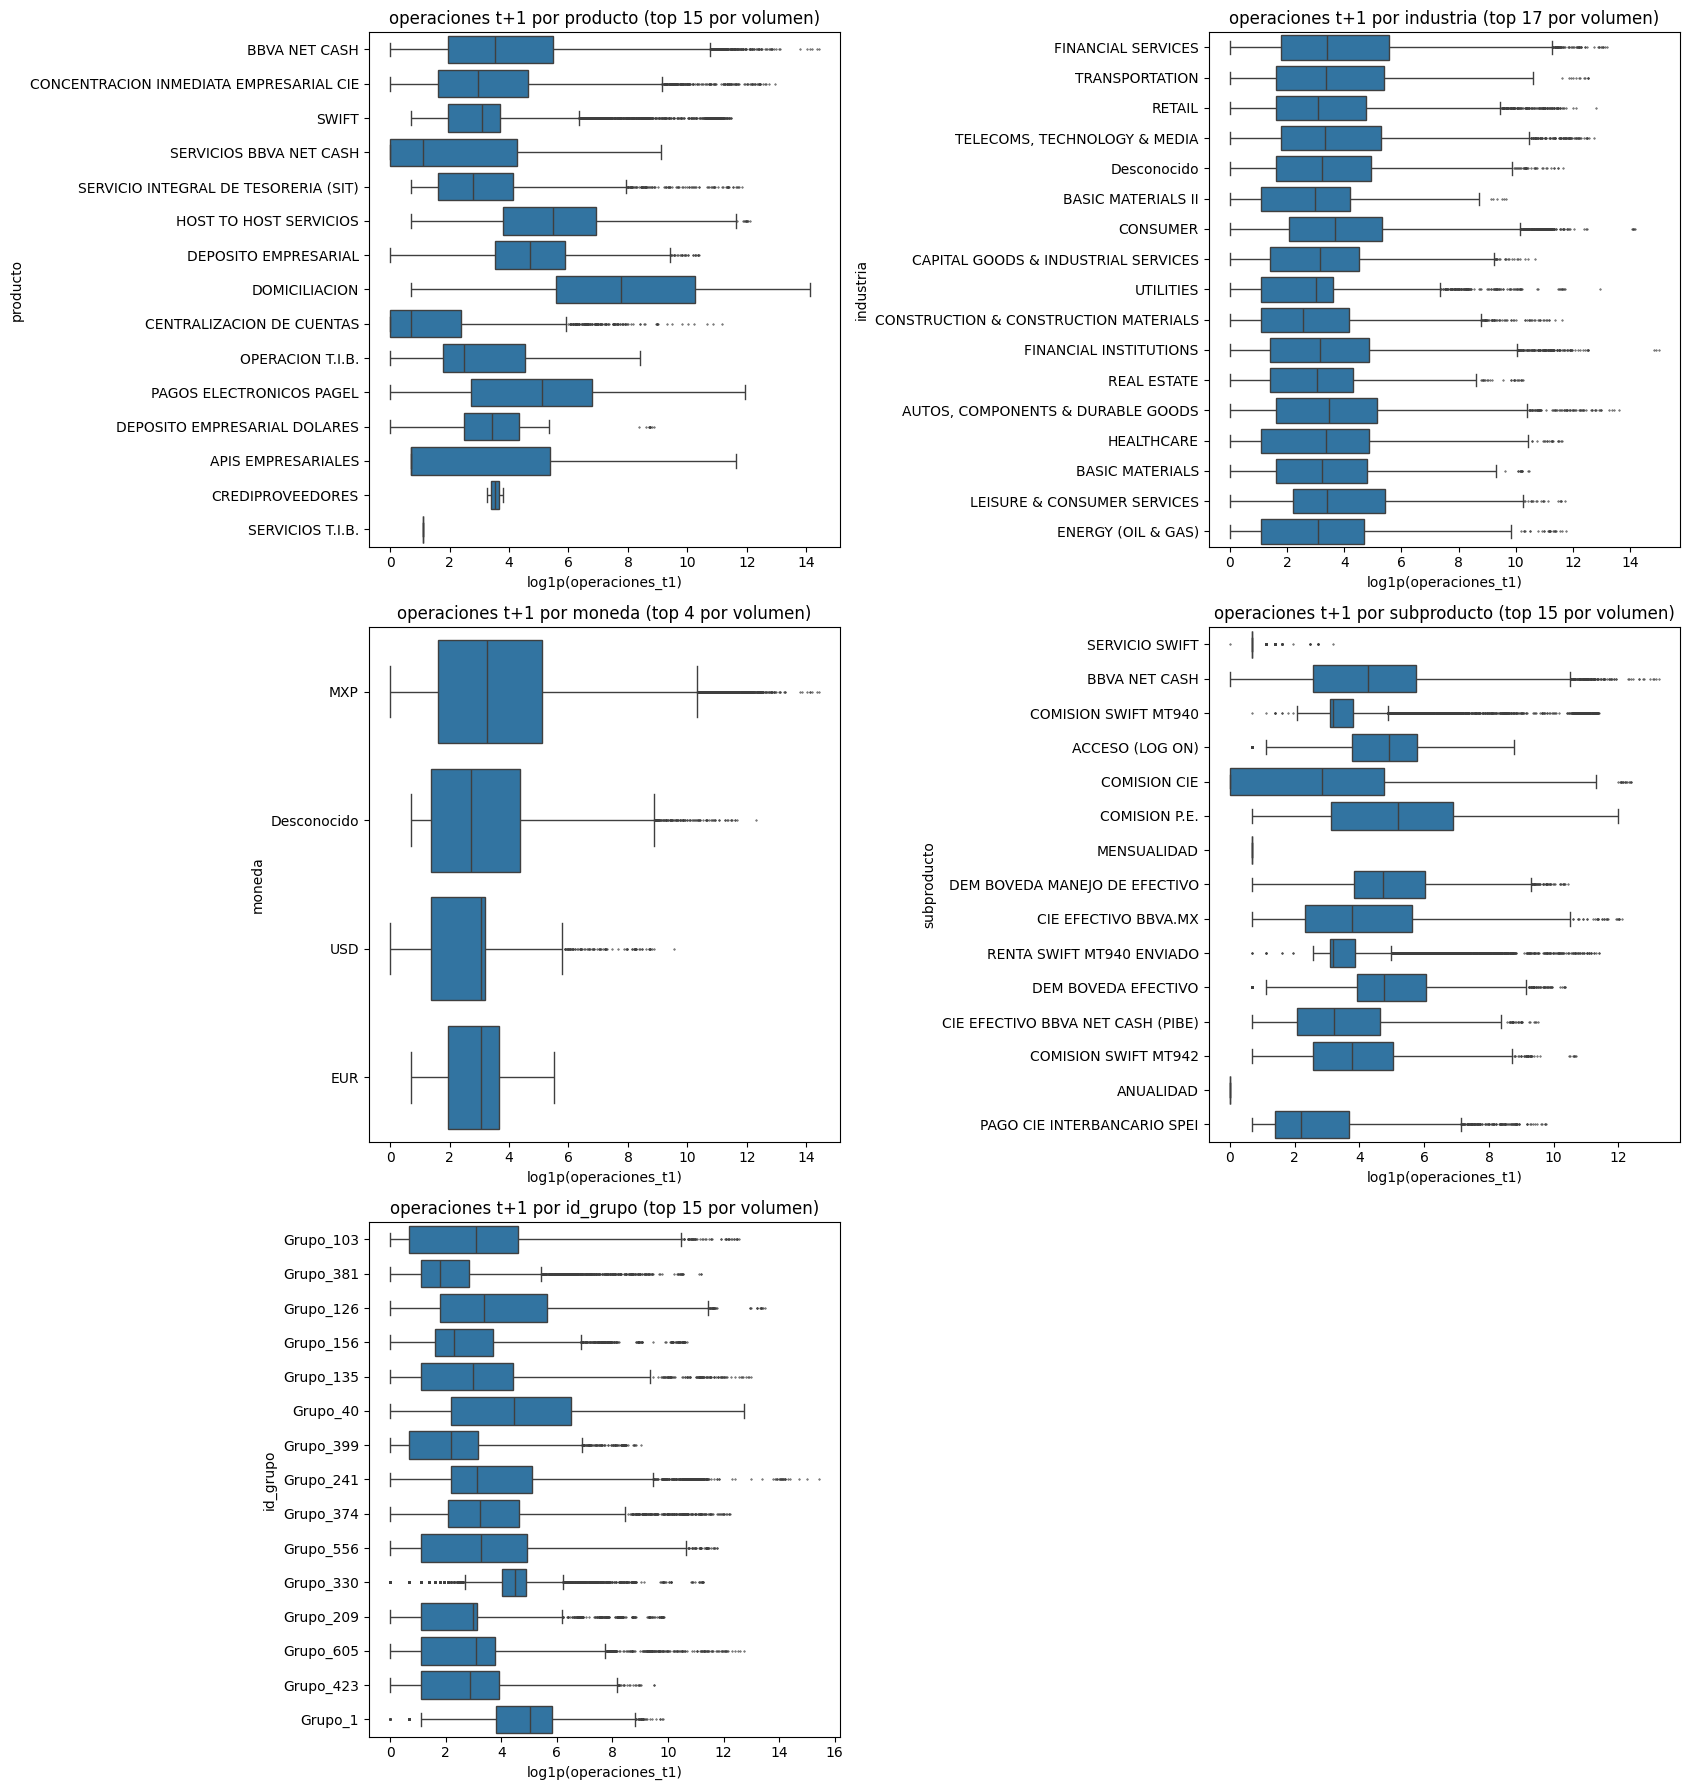

In [37]:
# Visualizaciones legibles: top categorías por volumen; muestra solo para graficar.
def boxplot_top_categoria(df, categoria, top_n=15, ax=None):
    conteos = df[categoria].fillna("Desconocido").value_counts()
    top = conteos.head(top_n).index
    temp = df[df[categoria].fillna("Desconocido").isin(top)][[categoria, "operaciones_t1"]].copy()
    temp[categoria] = temp[categoria].fillna("Desconocido")
    if len(temp) > 100000:
        temp = temp.sample(100000, random_state=RANDOM_STATE)
    temp["log1p_target"] = np.log1p(temp["operaciones_t1"].clip(lower=0))
    sns.boxplot(data=temp, y=categoria, x="log1p_target", ax=ax, fliersize=0.5)
    ax.set_title(f"operaciones t+1 por {categoria} (top {top_n} por volumen)")
    ax.set_xlabel("log1p(operaciones_t1)")
    ax.set_ylabel(categoria)

fig, axes = plt.subplots(3, 2, figsize=(17, 18))
for ax, cat, topn in zip(
    axes.flat,
    ["producto", "industria", "moneda", "subproducto", "id_grupo"],
    [15, 17, 4, 15, 15],
):
    boxplot_top_categoria(df_target_valid, cat, top_n=topn, ax=ax)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

**Conclusión Q8.** Las diferencias por categoría no son únicamente producto del gran tamaño muestral. `subproducto` presenta el mayor tamaño de efecto y se mantiene prácticamente idéntico al resumir por unidad contractual (epsilon² ≈ **0.385** en ambos análisis). `producto` y `id_grupo` muestran efectos menores pero relevantes (epsilon² ≈ **0.095–0.120**), mientras que `industria` y `moneda` presentan efectos pequeños (≈ **0.012–0.020**). La persistencia de estos patrones al resumir por unidad respalda la existencia de heterogeneidad real del target entre categorías.

# Q9. Normalización de imágenes

**No aplica.** El dataset es completamente tabular y no contiene imágenes; por lo tanto, la normalización de píxeles, resolución o canales no aplica.

# Q10. Variable objetivo de regresión: `operaciones_t1`

In [38]:
target = df_target_valid["operaciones_t1"].dropna()

percentiles_target = target.quantile([0, .25, .5, .75, .9, .95, .99, 1]).rename("valor").to_frame()
percentiles_target.index = ["min", "P25", "P50", "P75", "P90", "P95", "P99", "max"]
display(percentiles_target)

q10_resumen = pd.DataFrame({
    "metrica": [
        "Targets válidos",
        "% cobertura sobre panel unívoco",
        "Media",
        "Mediana",
        "Desviación estándar",
        "% ceros",
        "Skewness",
        "Kurtosis (exceso)",
    ],
    "valor": [
        len(target),
        100 * len(target) / len(df_target) if len(df_target) else np.nan,
        target.mean(),
        target.median(),
        target.std(),
        100 * target.eq(0).mean(),
        target.skew(),
        target.kurt(),
    ]
})
display(q10_resumen)

# Concentración de la variable objetivo: útil para una regresión con cola larga.
if target.sum() > 0:
    target_sorted = target.sort_values(ascending=False)
    n = len(target_sorted)
    share_top_1 = 100 * target_sorted.head(max(1, int(np.ceil(.01 * n)))).sum() / target_sorted.sum()
    share_top_10 = 100 * target_sorted.head(max(1, int(np.ceil(.10 * n)))).sum() / target_sorted.sum()
else:
    share_top_1 = share_top_10 = np.nan

print(f"Participación del 1% de observaciones más altas en el total del target: {share_top_1:.2f}%")
print(f"Participación del 10% de observaciones más altas en el total del target: {share_top_10:.2f}%")

# Participación acumulada de la cola para reutilizarla en la síntesis final.
n_top1 = max(1, int(np.ceil(0.01 * len(target))))
n_top10 = max(1, int(np.ceil(0.10 * len(target))))
target_ordenado = target.sort_values(ascending=False)
participacion_top1 = 100 * target_ordenado.head(n_top1).sum() / target.sum() if target.sum() != 0 else np.nan
participacion_top10 = 100 * target_ordenado.head(n_top10).sum() / target.sum() if target.sum() != 0 else np.nan


,valor
min,0.0
P25,3.0
P50,22.0
P75,133.0
P90,797.0
P95,2633.0
P99,28904.0
max,4982071.0


,metrica,valor
0,Targets válidos,694384.000000
1,% cobertura sobre panel unívoco,82.378985
2,Media,1627.324851
3,Mediana,22.000000
4,Desviación estándar,28046.491383
5,% ceros,5.382036
6,Skewness,83.707917
7,Kurtosis (exceso),9321.971049


Participación del 1% de observaciones más altas en el total del target: 70.55%
Participación del 10% de observaciones más altas en el total del target: 95.76%


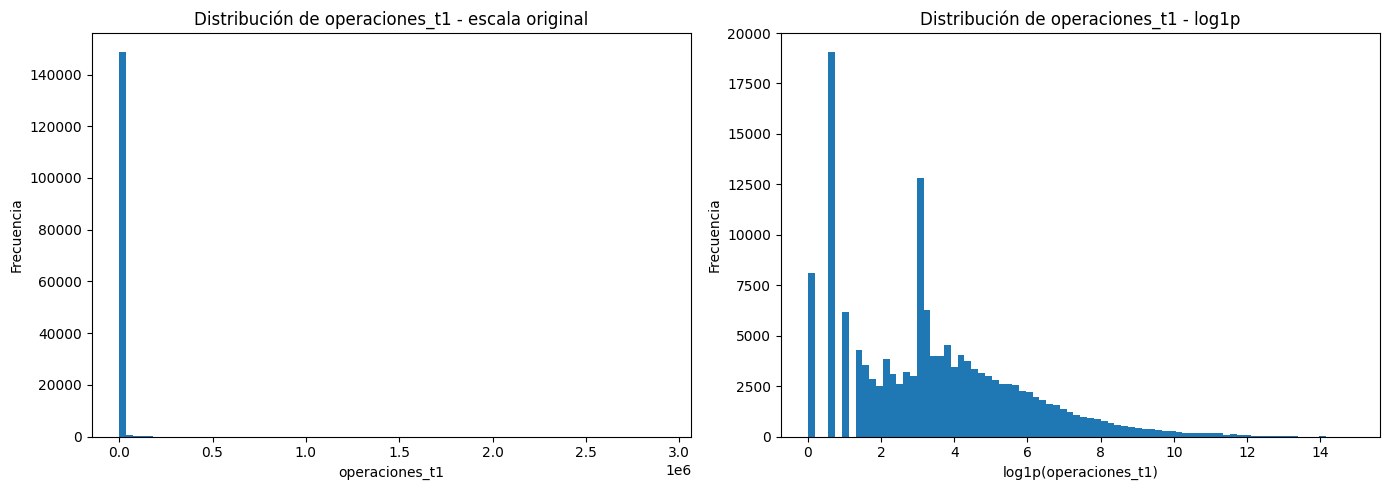

Implicación para modelado: el target es continuo y debe evaluarse como regresión. Si conserva una cola derecha pronunciada, MAE será útil por su robustez mientras RMSE mostrará sensibilidad a errores grandes. La métrica primaria formal se fijará en E3, no en este EDA.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_plot = target.sample(n=min(150000, len(target)), random_state=RANDOM_STATE)
axes[0].hist(target_plot.to_numpy(), bins=80)
axes[0].set_title("Distribución de operaciones_t1 - escala original")
axes[0].set_xlabel("operaciones_t1")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(target_plot.clip(lower=0)).to_numpy(), bins=80)
axes[1].set_title("Distribución de operaciones_t1 - log1p")
axes[1].set_xlabel("log1p(operaciones_t1)")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(
    "Implicación para modelado: el target es continuo y debe evaluarse como regresión. "
    "Si conserva una cola derecha pronunciada, MAE será útil por su robustez mientras RMSE mostrará sensibilidad a errores grandes. "
    "La métrica primaria formal se fijará en E3, no en este EDA."
)

**Conclusión Q10.** Se construyeron **694,384 targets válidos**, equivalentes a **82.38%** del panel unívoco. La cobertura no es homogénea: `DOMICILIACION` alcanza solo **12.84%**, `SERVICIOS T.I.B.` **14.81%** sobre un volumen muy reducido y `BBVA NET CASH` **77.99%**, mientras que la mayoría de los productos principales se sitúa aproximadamente entre **83% y 94%**. El target tiene mediana de **22**, P99 de **28,904** y máximo de **4,982,071** operaciones; **5.38%** de los targets son cero y el **1% superior concentra 70.55%** del volumen total. Esta cola extrema justifica complementar RMSE con métricas robustas como MAE y evaluar desempeño por producto y subgrupo.

## 8. Persistencia exploratoria de operaciones: t → t+1

Pearson operaciones_t vs operaciones_t1: 0.8964
Spearman operaciones_t vs operaciones_t1: 0.9378


,delta_abs,delta_pct
count,6.943840e+05,6.567330e+05
mean,8.143946e+00,5.656564e+01
std,1.273745e+04,4.824126e+03
min,-4.977011e+06,-1.000000e+02
25%,-4.000000e+00,-1.248293e+01
50%,0.000000e+00,0.000000e+00
75%,4.000000e+00,1.333333e+01
90%,3.600000e+01,5.625000e+01
95%,1.300000e+02,1.142857e+02
99%,1.776000e+03,5.500000e+02


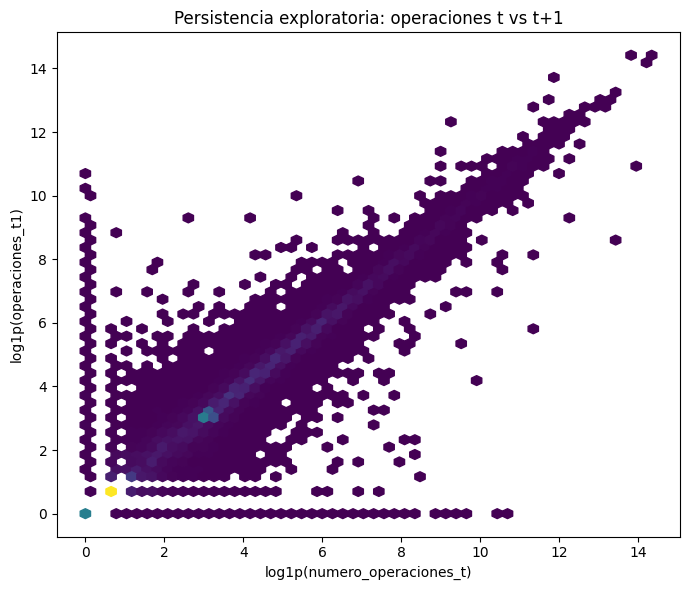

Este bloque diagnostica señal temporal; no constituye todavía el baseline oficial de E3.


In [40]:
persistencia = df_target_valid[["numero_operaciones", "operaciones_t1"]].copy()
persistencia["delta_abs"] = persistencia["operaciones_t1"] - persistencia["numero_operaciones"]
persistencia["delta_pct"] = np.where(
    persistencia["numero_operaciones"] > 0,
    100 * persistencia["delta_abs"] / persistencia["numero_operaciones"],
    np.nan,
)

corr_persist_pearson = persistencia[["numero_operaciones", "operaciones_t1"]].corr(method="pearson").iloc[0, 1]
corr_persist_spearman = persistencia[["numero_operaciones", "operaciones_t1"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson operaciones_t vs operaciones_t1: {corr_persist_pearson:.4f}")
print(f"Spearman operaciones_t vs operaciones_t1: {corr_persist_spearman:.4f}")
display(persistencia[["delta_abs", "delta_pct"]].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

muestra_persist = persistencia.sample(n=min(50000, len(persistencia)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(7, 6))
ax.hexbin(
    np.log1p(muestra_persist["numero_operaciones"].clip(lower=0)),
    np.log1p(muestra_persist["operaciones_t1"].clip(lower=0)),
    gridsize=55,
    mincnt=1,
)
ax.set_title("Persistencia exploratoria: operaciones t vs t+1")
ax.set_xlabel("log1p(numero_operaciones_t)")
ax.set_ylabel("log1p(operaciones_t1)")
plt.tight_layout()
plt.show()

print("Este bloque diagnostica señal temporal; no constituye todavía el baseline oficial de E3.")

**Lectura de persistencia.** La elevada correlación entre operaciones actuales y futuras confirma que la historia inmediata contiene una señal predictiva considerable. La mediana del cambio absoluto es 0, aunque existen variaciones extremas; por ello, un predictor de persistencia constituye una referencia natural para el baseline de E3, sin sustituir la evaluación de modelos adicionales.

# 9. Análisis complementarios de negocio

Estos análisis se conservan porque están alineados con el Avance 0, pero se mantienen subordinados al objetivo obligatorio de regresión `operaciones_t1`.

## 9.1 Repricing: señal tarifaria y comportamiento posterior

In [41]:
# Repricing sobre la unidad contractual completa, sin promediar convenios ni subproductos.
repricing = df_panel[
    LLAVE_UNIDAD + ["fecha_corte", "tarifa_vigente", "numero_operaciones"]
].sort_values(LLAVE_UNIDAD + ["fecha_corte"]).copy()

g_rep = repricing.groupby(LLAVE_UNIDAD, dropna=False, observed=True, sort=False)
repricing["fecha_anterior"] = g_rep["fecha_corte"].shift(1)
repricing["tarifa_anterior"] = g_rep["tarifa_vigente"].shift(1)
repricing["mes_idx"] = indice_mes(repricing["fecha_corte"])
repricing["mes_idx_anterior"] = indice_mes(repricing["fecha_anterior"])
repricing["gap_prev"] = repricing["mes_idx"] - repricing["mes_idx_anterior"]

# Comparación porcentual solo entre meses consecutivos con tarifas estrictamente positivas.
comparacion_tarifa_valida = (
    repricing["gap_prev"].eq(1)
    & repricing["tarifa_anterior"].gt(0)
    & repricing["tarifa_vigente"].gt(0)
)
repricing["cambio_tarifa_pct"] = np.where(
    comparacion_tarifa_valida,
    100 * (repricing["tarifa_vigente"] / repricing["tarifa_anterior"] - 1),
    np.nan,
)

UMBRAL_REPRICING = 5.0
repricing["es_repricing"] = repricing["cambio_tarifa_pct"].abs().ge(UMBRAL_REPRICING)

print("Comparaciones válidas mes-a-mes con ambas tarifas > 0:", int(comparacion_tarifa_valida.sum()))
print("Eventos de repricing |cambio| >= 5%:", int(repricing["es_repricing"].sum()))
if comparacion_tarifa_valida.sum():
    print("Porcentaje de comparaciones válidas que son repricing:", round(100 * repricing["es_repricing"].sum() / comparacion_tarifa_valida.sum(), 2))

display(repricing.loc[repricing["es_repricing"], "cambio_tarifa_pct"].describe().to_frame())

# Transiciones que involucran cero se reportan por separado, ya que el cambio porcentual desde cero no está definido.
transicion_cero = repricing["gap_prev"].eq(1) & (
    repricing["tarifa_anterior"].eq(0) ^ repricing["tarifa_vigente"].eq(0)
)
print("Transiciones consecutivas que involucran tarifa cero:", int(transicion_cero.sum()))

Comparaciones válidas mes-a-mes con ambas tarifas > 0: 325641
Eventos de repricing |cambio| >= 5%: 5908
Porcentaje de comparaciones válidas que son repricing: 1.81


,cambio_tarifa_pct
count,5908.000000
mean,25.695006
std,165.883295
min,-99.861819
25%,-5.658812
50%,6.250000
75%,25.272248
max,4500.000000


Transiciones consecutivas que involucran tarifa cero: 11896


Eventos de repricing: 5908
Eventos con ventana calendario completa 3m antes + 3m después: 4736


,variacion_operaciones_pct
count,4736.000000
mean,14.330373
std,383.830825
min,-99.935829
25%,-17.652337
50%,-1.095758
75%,11.764706
max,20941.666667


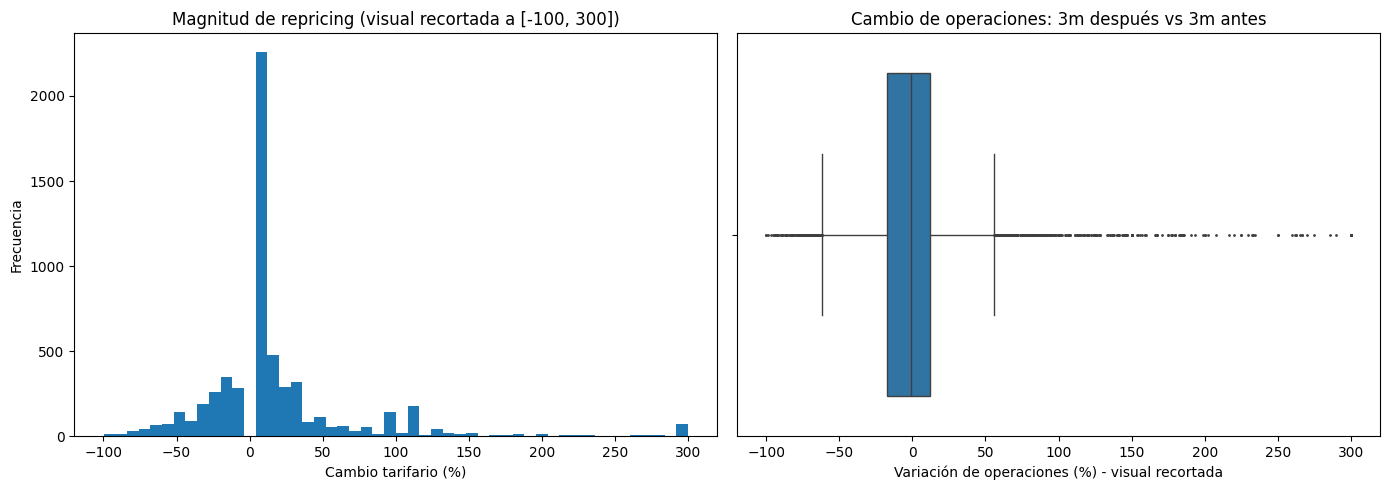

Este análisis es descriptivo y no identifica causalidad precio-demanda.


In [42]:
# Ventana estricta de tres meses antes y tres después: todas las fechas deben ser consecutivas.
for k in [1, 2, 3]:
    repricing[f"fecha_prev_{k}"] = g_rep["fecha_corte"].shift(k)
    repricing[f"ops_prev_{k}"] = g_rep["numero_operaciones"].shift(k)
    repricing[f"fecha_next_{k}"] = g_rep["fecha_corte"].shift(-k)
    repricing[f"ops_next_{k}"] = g_rep["numero_operaciones"].shift(-k)

    prev_idx = indice_mes(repricing[f"fecha_prev_{k}"])
    next_idx = indice_mes(repricing[f"fecha_next_{k}"])
    repricing[f"prev_ok_{k}"] = (repricing["mes_idx"] - prev_idx).eq(k)
    repricing[f"next_ok_{k}"] = (next_idx - repricing["mes_idx"]).eq(k)

cols_ok = [f"prev_ok_{k}" for k in [1, 2, 3]] + [f"next_ok_{k}" for k in [1, 2, 3]]
repricing["ventana_3m_completa"] = repricing[cols_ok].all(axis=1)

cols_prev = [f"ops_prev_{k}" for k in [1, 2, 3]]
cols_next = [f"ops_next_{k}" for k in [1, 2, 3]]
repricing["ops_antes_prom"] = repricing[cols_prev].mean(axis=1, skipna=False)
repricing["ops_despues_prom"] = repricing[cols_next].mean(axis=1, skipna=False)

eventos_ventana = repricing[repricing["es_repricing"] & repricing["ventana_3m_completa"]].copy()
eventos_ventana["var_ops_pct"] = np.where(
    eventos_ventana["ops_antes_prom"] > 0,
    100 * (eventos_ventana["ops_despues_prom"] / eventos_ventana["ops_antes_prom"] - 1),
    np.nan,
)

print("Eventos de repricing:", int(repricing["es_repricing"].sum()))
print("Eventos con ventana calendario completa 3m antes + 3m después:", len(eventos_ventana))
display(eventos_ventana["var_ops_pct"].describe().to_frame("variacion_operaciones_pct"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(repricing.loc[repricing["es_repricing"], "cambio_tarifa_pct"].clip(-100, 300).dropna().to_numpy(), bins=50)
axes[0].set_title("Magnitud de repricing (visual recortada a [-100, 300])")
axes[0].set_xlabel("Cambio tarifario (%)")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(x=eventos_ventana["var_ops_pct"].clip(-100, 300), ax=axes[1], fliersize=1)
axes[1].set_title("Cambio de operaciones: 3m después vs 3m antes")
axes[1].set_xlabel("Variación de operaciones (%) - visual recortada")
plt.tight_layout()
plt.show()

print("Este análisis es descriptivo y no identifica causalidad precio-demanda.")

**Conclusión de repricing.** Se identificaron **5,908 eventos** de cambio tarifario relevante y **4,736** cuentan con una ventana calendario completa de tres meses antes y después. La variación mediana de operaciones posterior al evento es **-1.10%**, con un rango intercuartílico aproximado de **-17.65% a +11.76%**. La media (**+14.33%**) está fuertemente afectada por valores extremos y no representa adecuadamente el comportamiento típico. La respuesta posterior es heterogénea y este análisis no establece causalidad entre tarifa y transaccionalidad.

## 9.2 Relación Tarifa × Operaciones vs ingreso observado

In [43]:
ingreso_implicito = df_eda["tarifa_vigente"] * df_eda["numero_operaciones"]
delta_ingreso = df_eda["ingreso_bruto"] - ingreso_implicito
TOLERANCIA_INGRESO = 1.0

categoria_delta = np.select(
    [
        delta_ingreso < -TOLERANCIA_INGRESO,
        delta_ingreso.abs() <= TOLERANCIA_INGRESO,
        delta_ingreso > TOLERANCIA_INGRESO,
    ],
    [
        "ingreso_bruto < tarifa*operaciones",
        "aproximadamente_igual",
        "ingreso_bruto > tarifa*operaciones",
    ],
    default="sin_clasificar",
)

tabla_delta_ingreso = pd.Series(categoria_delta, index=df_eda.index).value_counts(normalize=True).mul(100).rename("porcentaje").to_frame()
display(tabla_delta_ingreso)
print("Suma de porcentajes:", tabla_delta_ingreso["porcentaje"].sum())

corr_income_pearson = pd.concat([ingreso_implicito.rename("tarifa_x_operaciones"), df_eda["ingreso_bruto"]], axis=1).corr(method="pearson").iloc[0, 1]
corr_income_spearman = pd.concat([ingreso_implicito.rename("tarifa_x_operaciones"), df_eda["ingreso_bruto"]], axis=1).corr(method="spearman").iloc[0, 1]
exacta_pct = 100 * np.isclose(df_eda["ingreso_bruto"], ingreso_implicito, rtol=0, atol=1e-9).mean()

print(f"Pearson: {corr_income_pearson:.4f}")
print(f"Spearman: {corr_income_spearman:.4f}")
print(f"Coincidencia exacta dentro de tolerancia numérica 1e-9: {exacta_pct:.2f}%")
display(delta_ingreso.describe().to_frame("ingreso_bruto - tarifa*operaciones"))

,porcentaje
aproximadamente_igual,71.122490
ingreso_bruto > tarifa*operaciones,22.924657
ingreso_bruto < tarifa*operaciones,5.952853


Suma de porcentajes: 100.0
Pearson: 0.6742
Spearman: 0.5647
Coincidencia exacta dentro de tolerancia numérica 1e-9: 64.37%


,ingreso_bruto - tarifa*operaciones
count,8.705910e+05
mean,1.826827e+03
std,7.085771e+04
min,-1.144225e+07
25%,0.000000e+00
50%,0.000000e+00
75%,9.000000e-04
max,8.694337e+06


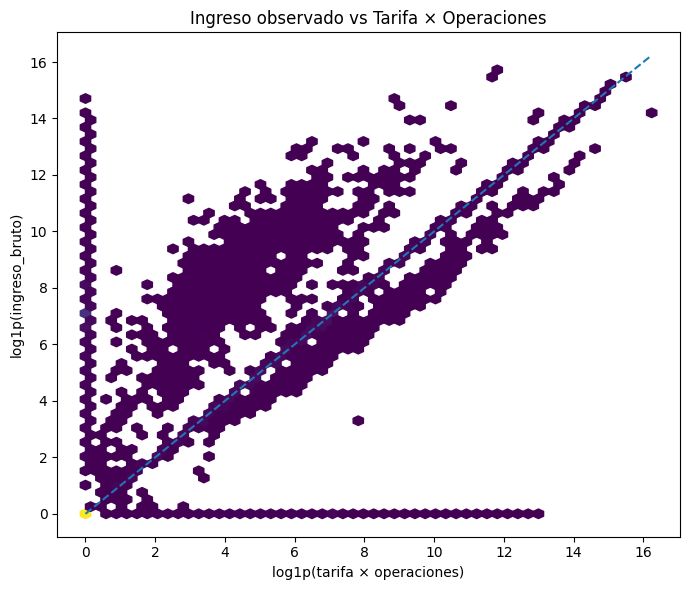

Este bloque no redefine el target. Solo evalúa si una función económica simple sería adecuada para un optimizador futuro.


In [44]:
muestra_income = pd.DataFrame({
    "tarifa_x_operaciones": ingreso_implicito,
    "ingreso_bruto": df_eda["ingreso_bruto"],
}).sample(n=min(50000, len(df_eda)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 6))
ax.hexbin(
    np.log1p(muestra_income["tarifa_x_operaciones"].clip(lower=0)),
    np.log1p(muestra_income["ingreso_bruto"].clip(lower=0)),
    gridsize=55,
    mincnt=1,
)
limite = max(
    np.log1p(muestra_income["tarifa_x_operaciones"].clip(lower=0)).max(),
    np.log1p(muestra_income["ingreso_bruto"].clip(lower=0)).max(),
)
ax.plot([0, limite], [0, limite], linestyle="--")
ax.set_title("Ingreso observado vs Tarifa × Operaciones")
ax.set_xlabel("log1p(tarifa × operaciones)")
ax.set_ylabel("log1p(ingreso_bruto)")
plt.tight_layout()
plt.show()

print(
    "Este bloque no redefine el target. Solo evalúa si una función económica simple sería adecuada para un optimizador futuro."
)

**Conclusión económica.** `Tarifa × Operaciones` se encuentra dentro de ±1 unidad de `ingreso_bruto` en **71.12%** de los registros; en **22.92%** el ingreso observado es mayor y en **5.95%** es menor. La coincidencia exacta bajo tolerancia numérica estricta es **64.37%**. Aunque existe asociación (Pearson ≈ **0.674**, Spearman ≈ **0.565**), las discrepancias son suficientes para no asumir de forma universal que el ingreso observado sea exactamente tarifa por operaciones. Esta evidencia deberá considerarse al definir una eventual función económica del simulador.

## 9.3 Diagnóstico descriptivo de posibles peers

In [45]:
# Diagnóstico, no feature engineering: tamaño y heterogeneidad de celdas industria × producto.
peer_base = df_target_valid[["id_grupo", "industria", "producto", "operaciones_t1"]].copy()
peer_base["industria"] = peer_base["industria"].fillna("Desconocido")

peer_diag = (
    peer_base.groupby(["industria", "producto"], observed=True)
    .agg(
        observaciones=("operaciones_t1", "size"),
        grupos_unicos=("id_grupo", "nunique"),
        mediana_target=("operaciones_t1", "median"),
        p25_target=("operaciones_t1", lambda s: s.quantile(.25)),
        p75_target=("operaciones_t1", lambda s: s.quantile(.75)),
    )
)
peer_diag["iqr_target"] = peer_diag["p75_target"] - peer_diag["p25_target"]

suficientes_peer = peer_diag[(peer_diag["observaciones"] >= 30) & (peer_diag["grupos_unicos"] >= 5)]
print("Celdas industria × producto:", len(peer_diag))
print("Celdas con >=30 observaciones y >=5 grupos únicos:", len(suficientes_peer))
if len(peer_diag):
    print("Porcentaje de celdas con cobertura mínima:", round(100 * len(suficientes_peer) / len(peer_diag), 2))

display(peer_diag.sort_values(["grupos_unicos", "observaciones"], ascending=False).head(30))
print(
    "La utilidad predictiva de peers no se prueba en E1. Este bloque solo evalúa si existen celdas comparables con volumen y diversidad suficientes; "
    "features de peers o clustering se reservan para E2/E3."
)

Celdas industria × producto: 196
Celdas con >=30 observaciones y >=5 grupos únicos: 125
Porcentaje de celdas con cobertura mínima: 63.78


observaciones  grupos_unicos  mediana_target  p25_target  p75_target  iqr_target
industria                           producto                                                                                                                 
Desconocido                         BBVA NET CASH                                    34635            179            20.0         3.0      128.00      125.00
                                    SERVICIOS BBVA NET CASH                           6117            176            26.0         1.0      135.00      134.00
                                    SWIFT                                             6690             91            22.0        20.0       41.00       21.00
FINANCIAL SERVICES                  SERVICIOS BBVA NET CASH                          10088             67             3.0         0.0       89.25       89.25
Desconocido                         SERVICIO INTEGRAL DE TESORERIA (SIT)              2450             67            18.0         5.0       55.00       50.00
FINANCIAL SERVICES                  BBVA NET CASH                                    24974             66            54.0         7.0      453.00      446.00
FINANCIAL INSTITUTIONS              BBVA NET CASH                                    26970             62            43.0         8.0      258.00      250.00
                                    SERVICIOS BBVA NET CASH                          15937             59             5.0         0.0       39.00       39.00
CONSUMER                            SERVICIOS BBVA NET CASH                           9035             52             1.0         0.0       81.50       81.50
                                    BBVA NET CASH                                    27080             51            38.0         6.0      278.00      272.00
                                    SWIFT                                            25898             42            22.0        19.0       46.00       27.00
Desconocido                         CONCENTRACION INMEDIATA EMPRESARIAL CIE           5673             42            26.0         3.0      112.00      109.00
AUTOS, COMPONENTS & DURABLE GOODS   SERVICIOS BBVA NET CASH                           4529             42             2.0         0.0      113.00      113.00
                                    BBVA NET CASH                                    13979             41            22.0         5.0      166.00      161.00
Desconocido                         PAGOS ELECTRONICOS PAGEL                          2156             40           228.0        15.0      909.25      894.25
FINANCIAL SERVICES                  CONCENTRACION INMEDIATA EMPRESARIAL CIE          12490             36            39.0         6.0      212.75      206.75
CONSUMER                            SERVICIO INTEGRAL DE TESORERIA (SIT)             11535             35            12.0         2.0       86.00       84.00
TELECOMS, TECHNOLOGY & MEDIA        BBVA NET CASH                                    18604             34            41.0         6.0      420.00      414.00
                                    SERVICIOS BBVA NET CASH                           6509             33             1.0         0.0       72.00       72.00
FINANCIAL INSTITUTIONS              CONCENTRACION INMEDIATA EMPRESARIAL CIE           9432             32            20.0         3.0      142.25      139.25
CONSUMER                            CONCENTRACION INMEDIATA EMPRESARIAL CIE           9855             31            31.0         7.0      222.00      215.00
CAPITAL GOODS & INDUSTRIAL SERVICES BBVA NET CASH                                     9333             31            37.0         6.0      233.00      227.00
                                    SERVICIOS BBVA NET CASH                           3399             31            15.0         1.0       99.00       98.00
FINANCIAL SERVICES                  SWIFT                                             9615             30            21.0      

La utilidad predictiva de peers no se prueba en E1. Este bloque solo evalúa si existen celdas comparables con volumen y diversidad suficientes; features de peers o clustering se reservan para E2/E3.


**Conclusión de peers.** De **196** celdas `industria × producto`, **125 (63.78%)** cuentan con al menos 30 observaciones y 5 grupos corporativos distintos. Existe, por tanto, una base descriptiva suficiente para evaluar información de peers en E2; su utilidad predictiva deberá demostrarse posteriormente frente a modelos basados únicamente en la historia individual.

## 9.4 Heterogeneidad interna a nivel grupo

Este bloque no cambia el target. Su objetivo es comprobar por qué el resultado de negocio puede agregarse a nivel grupo mientras la señal tarifaria debe conservar granularidad contractual: un mismo grupo puede contener varias unidades y, en un mismo mes, diferentes tarifas para un mismo producto/subproducto.


In [46]:
# Universo contractual por grupo durante toda la muestra.
unidades_unicas = df_panel[LLAVE_UNIDAD].drop_duplicates()
resumen_grupo = (
    unidades_unicas.groupby("id_grupo", dropna=False, observed=True)
    .agg(
        unidades_contractuales=("convenio", "size"),
        productos=("producto", "nunique"),
        subproductos=("subproducto", "nunique"),
        convenios=("convenio", "nunique"),
        monedas=("moneda", "nunique"),
    )
)
display(resumen_grupo.describe(percentiles=[.25, .5, .75, .9, .95, .99]).T)

# Heterogeneidad tarifaria simultánea: misma fecha + grupo + producto + subproducto.
contexto_tarifa = (
    df_panel.groupby(["fecha_corte", "id_grupo", "producto", "subproducto"], dropna=False, observed=True)
    .agg(
        filas=("convenio", "size"),
        convenios=("convenio", "nunique"),
        monedas=("moneda", "nunique"),
        tarifas_distintas=("tarifa_vigente", lambda s: s.dropna().nunique()),
    )
    .reset_index()
)
contexto_tarifa_moneda = (
    df_panel.groupby(["fecha_corte", "id_grupo", "producto", "subproducto", "moneda"], dropna=False, observed=True)
    .agg(
        filas=("convenio", "size"),
        convenios=("convenio", "nunique"),
        tarifas_distintas=("tarifa_vigente", lambda s: s.dropna().nunique()),
    )
    .reset_index()
)

multi_tarifa = contexto_tarifa["tarifas_distintas"].gt(1)
multi_tarifa_misma_moneda = contexto_tarifa_moneda["tarifas_distintas"].gt(1)

resumen_heterogeneidad = pd.DataFrame({
    "metrica": [
        "Contextos grupo-producto-subproducto-mes",
        "Contextos con >1 tarifa",
        "% contextos con >1 tarifa",
        "Grupos con al menos un contexto >1 tarifa",
        "% grupos con al menos un contexto >1 tarifa",
        "Contextos grupo-producto-subproducto-moneda-mes con >1 tarifa",
        "% contextos misma moneda con >1 tarifa",
    ],
    "valor": [
        len(contexto_tarifa),
        int(multi_tarifa.sum()),
        100 * multi_tarifa.mean() if len(contexto_tarifa) else np.nan,
        contexto_tarifa.loc[multi_tarifa, "id_grupo"].nunique(),
        100 * contexto_tarifa.loc[multi_tarifa, "id_grupo"].nunique() / df_panel["id_grupo"].nunique() if df_panel["id_grupo"].nunique() else np.nan,
        int(multi_tarifa_misma_moneda.sum()),
        100 * multi_tarifa_misma_moneda.mean() if len(contexto_tarifa_moneda) else np.nan,
    ]
})
display(resumen_heterogeneidad)

heterogeneidad_producto = (
    contexto_tarifa.assign(multi_tarifa=multi_tarifa)
    .groupby("producto", observed=True)
    .agg(contextos=("multi_tarifa", "size"), contextos_multi_tarifa=("multi_tarifa", "sum"), pct_multi_tarifa=("multi_tarifa", "mean"))
)
heterogeneidad_producto["pct_multi_tarifa"] *= 100
display(heterogeneidad_producto.sort_values("pct_multi_tarifa", ascending=False))

# Operaciones agregadas a nivel grupo-mes: muestra cómo se obtendrá una salida de negocio agregando unidades internas.
grupo_mes = (
    df_panel.groupby(["fecha_corte", "id_grupo"], dropna=False, observed=True)
    .agg(
        operaciones_grupo=("numero_operaciones", "sum"),
        filas_contractuales=("convenio", "size"),
        convenios=("convenio", "nunique"),
        productos=("producto", "nunique"),
        subproductos=("subproducto", "nunique"),
    )
)
display(grupo_mes.describe(percentiles=[.25, .5, .75, .9, .95, .99]).T)

print(
    "Lectura: la predicción obligatoria permanece a granularidad interna. El resultado de negocio puede obtenerse sumando "
    "predicciones por grupo; la heterogeneidad tarifaria simultánea muestra por qué no conviene colapsar tarifas prematuramente."
)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
unidades_contractuales,706.0,143.835694,406.867464,1.0,15.25,36.0,106.75,305.5,553.25,1635.35,4993.0
productos,706.0,3.949008,2.311293,1.0,2.00,3.0,5.00,8.0,8.00,10.00,14.0
subproductos,706.0,34.861190,28.965531,1.0,13.00,27.5,49.00,76.5,94.00,117.00,175.0
convenios,706.0,43.005666,199.595776,1.0,2.00,4.0,12.00,43.5,147.25,731.80,2666.0
monedas,706.0,1.345609,0.565775,0.0,1.00,1.0,2.00,2.0,2.00,3.00,3.0


,metrica,valor
0,Contextos grupo-producto-subproducto-mes,344295.000000
1,Contextos con >1 tarifa,21286.000000
2,% contextos con >1 tarifa,6.182489
3,Grupos con al menos un contexto >1 tarifa,298.000000
4,% grupos con al menos un contexto >1 tarifa,42.209632
5,Contextos grupo-producto-subproducto-moneda-me...,13771.000000
6,% contextos misma moneda con >1 tarifa,3.727695


,contextos,contextos_multi_tarifa,pct_multi_tarifa
producto,,,
CONCENTRACION INMEDIATA EMPRESARIAL CIE,26306,4485,17.049342
SWIFT,20636,2856,13.839891
OPERACION T.I.B.,996,125,12.550201
SERVICIO INTEGRAL DE TESORERIA (SIT),17997,1800,10.001667
DEPOSITO EMPRESARIAL DOLARES,672,46,6.845238
BBVA NET CASH,192801,10029,5.201737
DOMICILIACION,5975,275,4.602510
DEPOSITO EMPRESARIAL,4665,189,4.051447
APIS EMPRESARIALES,1375,48,3.490909


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
operaciones_grupo,23354.0,53968.146956,254635.109792,0.0,205.0,1853.5,14472.5,89038.4,267421.1,870334.39,7871112.0
filas_contractuales,23354.0,36.092918,75.462458,1.0,3.0,10.0,35.0,85.0,158.0,455.94,1090.0
convenios,23354.0,10.464332,26.590967,1.0,1.0,3.0,9.0,24.0,41.0,131.00,506.0
productos,23354.0,3.519868,2.173375,1.0,2.0,3.0,5.0,7.0,8.0,9.00,14.0
subproductos,23354.0,13.990323,17.347106,1.0,1.0,5.0,24.0,41.0,51.0,67.00,119.0


Lectura: la predicción obligatoria permanece a granularidad interna. El resultado de negocio puede obtenerse sumando predicciones por grupo; la heterogeneidad tarifaria simultánea muestra por qué no conviene colapsar tarifas prematuramente.


**Conclusión de heterogeneidad interna.** La heterogeneidad tarifaria no es marginal: **6.18%** de los contextos `grupo-producto-subproducto-mes` contienen más de una tarifa y **3.73%** continúan presentando múltiples tarifas incluso al controlar por moneda. **298 de 706 grupos (42.21%)** tienen al menos un contexto con múltiples tarifas. La incidencia es especialmente alta en CIE (**17.05%**) y SWIFT (**13.84%**). Estos resultados respaldan mantener la predicción a granularidad contractual y agregar posteriormente las operaciones esperadas a nivel grupo, en lugar de colapsar tarifas de forma prematura.

# 10. Decisiones de preprocesamiento derivadas del EDA

In [49]:
decisiones_preprocesamiento = pd.DataFrame([
    {
        "hallazgo": "Ausencia en moneda e industria compatible con MAR",
        "decision": "Conservar la señal de ausencia; evaluar categoría 'Desconocido' + indicador",
        "justificacion": "MCAR global es poco plausible por asociaciones materiales con variables observadas y tiempo",
        "momento": "E2; fit/transform solo con train",
    },
    {
        "hallazgo": "seniority: 18,028 fallos de parseo y 0 nulos originales",
        "decision": "Mantener NaT + indicador de fecha no interpretable; no imputar una fecha arbitraria",
        "justificacion": "Una fecha inventada generaría antigüedad ficticia y el mecanismo inmediato es de calidad/formato",
        "momento": "E2",
    },
    {
        "hallazgo": "Llaves observacionales no unívocas: 3.18% de filas y 2.93% del volumen",
        "decision": "No promediar tarifas; usar llaves unívocas en el panel supervisado",
        "justificacion": "La mayoría presenta conflictos simultáneos y un promedio crearía una unidad contractual artificial",
        "momento": "E1; contrastar multiplicidades con linaje de la fuente",
    },
    {
        "hallazgo": "Alta cardinalidad de identificadores y subproducto",
        "decision": "No aplicar one-hot ingenuo ni encoding definitivo en E1",
        "justificacion": "La estrategia depende del algoritmo y debe manejar categorías no vistas sin leakage",
        "momento": "E2",
    },
    {
        "hallazgo": "Distribuciones numéricas y target con cola derecha extrema",
        "decision": "Conservar originales y mantener log1p como transformación candidata",
        "justificacion": "Reduce materialmente la asimetría y admite ceros sin implicar normalidad",
        "momento": "E2/E3",
    },
    {
        "hallazgo": "Outliers estadísticos sin valores negativos en las variables auditadas",
        "decision": "Conservar los extremos; no eliminar ni winsorizar en E1",
        "justificacion": "Los extremos pueden corresponder a actividad corporativa legítima",
        "momento": "E2/E3 si el algoritmo lo requiere",
    },
    {
        "hallazgo": "Variable negocio con una sola categoría",
        "decision": "Excluir de la matriz predictiva",
        "justificacion": "No aporta variación discriminante dentro de la muestra",
        "momento": "E2",
    },
    {
        "hallazgo": "Target t+1 con ruptura de continuidad en septiembre-octubre de 2025",
        "decision": "Usar validación temporal estricta y evaluar estabilidad por periodo/producto",
        "justificacion": "Evita fuga temporal y controla cambios de composición del panel",
        "momento": "E3",
    },
    {
        "hallazgo": "Peers descriptivamente viables en 63.78% de celdas industria-producto",
        "decision": "Evaluar features peer solo como información incremental",
        "justificacion": "Su valor debe demostrarse frente a la historia individual y sin fuga temporal",
        "momento": "E2/E3",
    },
    {
        "hallazgo": "42.21% de grupos presentan al menos un contexto con múltiples tarifas",
        "decision": "Mantener predicción a granularidad contractual y agregar resultados a grupo",
        "justificacion": "La heterogeneidad tarifaria interna impide representar al grupo mediante una tarifa única",
        "momento": "Arquitectura del modelado y extensión Multipricing",
    },
])

with pd.option_context("display.max_colwidth", None):
    display(decisiones_preprocesamiento)

,hallazgo,decision,justificacion,momento
0,Ausencia en moneda e industria compatible con MAR,Conservar la señal de ausencia; evaluar categoría 'Desconocido' + indicador,MCAR global es poco plausible por asociaciones materiales con variables observadas y tiempo,E2; fit/transform solo con train
1,"seniority: 18,028 fallos de parseo y 0 nulos originales",Mantener NaT + indicador de fecha no interpretable; no imputar una fecha arbitraria,Una fecha inventada generaría antigüedad ficticia y el mecanismo inmediato es de calidad/formato,E2
2,Llaves observacionales no unívocas: 3.18% de filas y 2.93% del volumen,No promediar tarifas; usar llaves unívocas en el panel supervisado,La mayoría presenta conflictos simultáneos y un promedio crearía una unidad contractual artificial,E1; contrastar multiplicidades con linaje de la fuente
3,Alta cardinalidad de identificadores y subproducto,No aplicar one-hot ingenuo ni encoding definitivo en E1,La estrategia depende del algoritmo y debe manejar categorías no vistas sin leakage,E2
4,Distribuciones numéricas y target con cola derecha extrema,Conservar originales y mantener log1p como transformación candidata,Reduce materialmente la asimetría y admite ceros sin implicar normalidad,E2/E3
5,Outliers estadísticos sin valores negativos en las variables auditadas,Conservar los extremos; no eliminar ni winsorizar en E1,Los extremos pueden corresponder a actividad corporativa legítima,E2/E3 si el algoritmo lo requiere
6,Variable negocio con una sola categoría,Excluir de la matriz predictiva,No aporta variación discriminante dentro de la muestra,E2
7,Target t+1 con ruptura de continuidad en septiembre-octubre de 2025,Usar validación temporal estricta y evaluar estabilidad por periodo/producto,Evita fuga temporal y controla cambios de composición del panel,E3
8,Peers descriptivamente viables en 63.78% de celdas industria-producto,Evaluar features peer solo como información incremental,Su valor debe demostrarse frente a la historia individual y sin fuga temporal,E2/E3
9,42.21% de grupos presentan al menos un contexto con múltiples tarifas,Mantener predicción a granularidad contractual y agregar resultados a grupo,La heterogeneidad tarifaria interna impide representar al grupo mediante una tarifa única,Arquitectura del modelado y extensión Multipricing


# 11. Conclusiones Q1-Q10

In [48]:
# Síntesis reproducible de los principales resultados del EDA.

def _valor_asociacion_cat(var_missing, var_exp):
    tmp = missing_assoc_cat[
        (missing_assoc_cat["variable_missing"] == var_missing)
        & (missing_assoc_cat["variable_explicativa"] == var_exp)
    ]
    return float(tmp.iloc[0]["cramers_v"]) if len(tmp) else np.nan


def _valor_asociacion_missing(a, b):
    pares = {a, b}
    tmp = tabla_asoc_missing[
        tabla_asoc_missing.apply(lambda r: {r["missing_a"].replace("missing_", ""), r["missing_b"].replace("missing_", "")} == pares, axis=1)
    ]
    return float(tmp.iloc[0]["cramers_v"]) if len(tmp) else np.nan

seniority_parse = tabla_validacion_parseo.loc[tabla_validacion_parseo["variable"].eq("seniority")].iloc[0]
v_moneda_producto = _valor_asociacion_cat("moneda", "producto")
v_ind_sen = _valor_asociacion_missing("industria", "seniority")
v_mon_ind = _valor_asociacion_missing("moneda", "industria")

max_outlier_row = tabla_outliers["outliers_IQR_pct"].idxmax()
max_outlier_pct = tabla_outliers.loc[max_outlier_row, "outliers_IQR_pct"]
target_skew_orig = tabla_transformaciones.loc["operaciones_t1", "skew_original"]
target_skew_log = tabla_transformaciones.loc["operaciones_t1", "skew_log1p"]
q10_zero_pct = 100 * target.eq(0).mean()
coverage_pct = 100 * len(df_target_valid) / len(df_target) if len(df_target) else np.nan

sep_cov = float(cobertura_mes.loc[pd.Period("2025-09", freq="M"), "cobertura_pct"])
oct_cov = float(cobertura_mes.loc[pd.Period("2025-10", freq="M"), "cobertura_pct"])

kw_effect = tabla_kw_unidad.set_index("categoria")["epsilon2"].to_dict()

texto_conclusiones = f"""
### Q1. Valores faltantes
`moneda` presenta **{missing_summary.loc['moneda','faltantes_pct']:.2f}%** de ausencia e `industria` **{missing_summary.loc['industria','faltantes_pct']:.2f}%**. La ausencia de `moneda` tiene asociación fuerte con `producto` (Cramér's V = **{v_moneda_producto:.3f}**) y existen patrones conjuntos relevantes entre `industria`–`seniority` (**{v_ind_sen:.3f}**) y `moneda`–`industria` (**{v_mon_ind:.3f}**). En `moneda` también se observa variación temporal material. Por ello, MCAR global es poco plausible para `moneda` e `industria`; los patrones son compatibles con MAR, sin demostrarlo ni permitir descartar MNAR. En `seniority`, **{int(seniority_parse['n_parse_fail']):,}** registros no nulos de origen no pudieron convertirse a fecha válida, por lo que se trata prioritariamente como un problema de calidad/formato.

### Q2. Estadísticas resumidas
La base contiene **{len(df_eda):,} registros y {df_eda.shape[1]} variables**. La mediana de `numero_operaciones` es **{df_eda['numero_operaciones'].median():.0f}** y la del target **{target.median():.0f}**. Las distribuciones presentan fuerte heterogeneidad, colas largas y una presencia relevante de ceros, especialmente en las variables tarifarias y de ingreso.

### Q3. Valores atípicos
El criterio IQR identifica la mayor proporción de extremos en **{max_outlier_row} ({max_outlier_pct:.2f}%)**. No se detectaron valores negativos en las variables auditadas. Los valores extremos se conservan porque pueden representar actividad corporativa legítima y no existe evidencia para tratarlos automáticamente como errores.

### Q4. Cardinalidad
`convenio` (**{int(cardinalidad.loc['convenio','categorias_unicas']):,}**), `línea_contrato` (**{int(cardinalidad.loc['línea_contrato','categorias_unicas']):,}**), `id_cliente` (**{int(cardinalidad.loc['id_cliente','categorias_unicas']):,}**), `id_grupo` (**{int(cardinalidad.loc['id_grupo','categorias_unicas']):,}**) y `subproducto` (**{int(cardinalidad.loc['subproducto','categorias_unicas']):,}**) requieren tratamiento de alta cardinalidad. `negocio` contiene una sola categoría y no aporta variación discriminante.

### Q5. Distribuciones sesgadas
El target tiene skewness **{target_skew_orig:.2f}** en escala original y **{target_skew_log:.2f}** tras `log1p`. La transformación reduce de forma material la asimetría, pero no implica normalidad; queda como candidata para la preparación posterior.

### Q6. Temporalidad
La muestra contiene **{len(periodos_observados)} meses consecutivos** sin huecos globales, pero la continuidad contractual es heterogénea. Solo **{continuidad_thresholds.loc[continuidad_thresholds['meses_consecutivos_minimos'].eq(12),'porcentaje_unidades'].iloc[0]:.2f}%** de las unidades alcanza al menos 12 meses consecutivos. La cobertura del target cae a **{sep_cov:.2f}%** en septiembre de 2025 y **{oct_cov:.2f}%** en octubre de 2025. La autocorrelación agregada a 12 meses es **{autocorr_12:.3f}**, por lo que no se observa una señal anual fuerte en este EDA.

### Q7. Correlaciones
`numero_operaciones_t` concentra la señal lineal y monotónica más fuerte respecto de `operaciones_t1` (Pearson **{corr_persist_pearson:.3f}**, Spearman **{corr_persist_spearman:.3f}**). Las tarifas presentan relaciones directas mucho más débiles con el target. La mayor correlación absoluta entre predictores numéricos es **{max_corr_pred:.3f}**, sin evidencia de colinealidad fuerte bajo |r| ≥ 0.80.

### Q8. Distribución por categorías
La heterogeneidad del target persiste al resumir por unidad contractual. `subproducto` presenta el mayor tamaño de efecto (epsilon² ≈ **{kw_effect.get('subproducto', np.nan):.3f}**), seguido por `id_grupo` (**{kw_effect.get('id_grupo', np.nan):.3f}**) y `producto` (**{kw_effect.get('producto', np.nan):.3f}**). `industria` y `moneda` muestran efectos menores.

### Q9. Imágenes
No aplica: el conjunto de datos es completamente tabular.

### Q10. Variable objetivo
Se construyeron **{len(df_target_valid):,} targets válidos**, equivalentes a **{coverage_pct:.2f}%** del panel unívoco. El target tiene mediana **{target.median():.0f}**, P99 **{target.quantile(.99):.0f}**, máximo **{target.max():.0f}** y **{q10_zero_pct:.2f}%** de ceros. El 1% superior concentra **{participacion_top1:.2f}%** del volumen total, lo que confirma una distribución extremadamente concentrada y justifica combinar métricas robustas y sensibles a errores grandes en el modelado posterior.
"""

display(Markdown(texto_conclusiones))


### Q1. Valores faltantes
`moneda` presenta **11.53%** de ausencia e `industria` **9.25%**. La ausencia de `moneda` tiene asociación fuerte con `producto` (Cramér's V = **0.509**) y existen patrones conjuntos relevantes entre `industria`–`seniority` (**0.438**) y `moneda`–`industria` (**0.309**). En `moneda` también se observa variación temporal material. Por ello, MCAR global es poco plausible para `moneda` e `industria`; los patrones son compatibles con MAR, sin demostrarlo ni permitir descartar MNAR. En `seniority`, **18,028** registros no nulos de origen no pudieron convertirse a fecha válida, por lo que se trata prioritariamente como un problema de calidad/formato.

### Q2. Estadísticas resumidas
La base contiene **870,591 registros y 15 variables**. La mediana de `numero_operaciones` es **21** y la del target **22**. Las distribuciones presentan fuerte heterogeneidad, colas largas y una presencia relevante de ceros, especialmente en las variables tarifarias y de ingreso.

### Q3. Valores atípicos
El criterio IQR identifica la mayor proporción de extremos en **tarifa_anaquel (17.24%)**. No se detectaron valores negativos en las variables auditadas. Los valores extremos se conservan porque pueden representar actividad corporativa legítima y no existe evidencia para tratarlos automáticamente como errores.

### Q4. Cardinalidad
`convenio` (**29,819**), `línea_contrato` (**7,547**), `id_cliente` (**3,466**), `id_grupo` (**706**) y `subproducto` (**340**) requieren tratamiento de alta cardinalidad. `negocio` contiene una sola categoría y no aporta variación discriminante.

### Q5. Distribuciones sesgadas
El target tiene skewness **83.71** en escala original y **0.72** tras `log1p`. La transformación reduce de forma material la asimetría, pero no implica normalidad; queda como candidata para la preparación posterior.

### Q6. Temporalidad
La muestra contiene **36 meses consecutivos** sin huecos globales, pero la continuidad contractual es heterogénea. Solo **21.93%** de las unidades alcanza al menos 12 meses consecutivos. La cobertura del target cae a **34.47%** en septiembre de 2025 y **51.03%** en octubre de 2025. La autocorrelación agregada a 12 meses es **0.054**, por lo que no se observa una señal anual fuerte en este EDA.

### Q7. Correlaciones
`numero_operaciones_t` concentra la señal lineal y monotónica más fuerte respecto de `operaciones_t1` (Pearson **0.896**, Spearman **0.938**). Las tarifas presentan relaciones directas mucho más débiles con el target. La mayor correlación absoluta entre predictores numéricos es **0.295**, sin evidencia de colinealidad fuerte bajo |r| ≥ 0.80.

### Q8. Distribución por categorías
La heterogeneidad del target persiste al resumir por unidad contractual. `subproducto` presenta el mayor tamaño de efecto (epsilon² ≈ **0.385**), seguido por `id_grupo` (**0.096**) y `producto` (**0.095**). `industria` y `moneda` muestran efectos menores.

### Q9. Imágenes
No aplica: el conjunto de datos es completamente tabular.

### Q10. Variable objetivo
Se construyeron **694,384 targets válidos**, equivalentes a **82.38%** del panel unívoco. El target tiene mediana **22**, P99 **28904**, máximo **4982071** y **5.38%** de ceros. El 1% superior concentra **70.55%** del volumen total, lo que confirma una distribución extremadamente concentrada y justifica combinar métricas robustas y sensibles a errores grandes en el modelado posterior.


## 12. Implicaciones para E2 y entregas posteriores

1. **E2 - Ingeniería de características:** construir lags/rolling, antigüedad, calendario, ratios y posibles peers únicamente con información disponible hasta cada fecha. Los encodings deberán ajustarse sobre entrenamiento y manejar categorías no vistas.
2. **E3 - Baseline:** evaluar un predictor de persistencia para `operaciones_t1` con separación temporal estricta; el análisis t→t+1 confirma que existe una señal histórica fuerte que debe superar cualquier modelo adicional.
3. **E4/E5 - Modelos:** comparar regresores bajo la misma política temporal y revisar estabilidad y desempeño por producto, subproducto, moneda y grupo, prestando especial atención a la ruptura de continuidad observada en septiembre-octubre de 2025.
4. **Extensión deseable - Multipricing:** si el predictor de operaciones alcanza desempeño suficiente, podrá evaluarse un optimizador que, dado un objetivo agregado de ingreso a nivel grupo, simule tarifas por unidad contractual. Esta extensión depende del predictor de operaciones y no modifica el target del proyecto.

La prioridad permanece en **estimar el número de operaciones del siguiente mes** y agregar posteriormente las estimaciones contractuales a nivel grupo sin destruir la heterogeneidad tarifaria interna.